In [33]:
import sys
import uproot
import ROOT as r
import numpy as np
import array as arr
import awkward as ak
import os
import matplotlib.pyplot as plt
#from analysis import Analysis
import logging
import pickle
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
os.environ['MEDULLA_PLOT_DIR'] =  '/nashome/m/micarrig/icarus/nuESpine/medulla/spineplot/'
sys.path.append('/nashome/m/micarrig/icarus/nuESpine/medulla/spineplot/')
from efficiency import SpineEfficiency
from analysis import Analysis
from style import make_styled_plot, apply_style_to_plot

#from efficiency import SpineEfficiency

%jsroot on 

r.gStyle.SetOptStat(0)
# ---------- matplotlib / numpy pickle compatibility ----------
import matplotlib
import matplotlib.figure as _mfig
import matplotlib.axes._base as _axbase

# _remove_suplabel (added in mpl 3.5+)
if not hasattr(_mfig.Figure, '_remove_suplabel'):
    def _remove_suplabel(self, attr): self.__dict__.pop(attr, None)
    _mfig.Figure._remove_suplabel = _remove_suplabel

# _PropCycle (removed in mpl 2.x)
if not hasattr(_axbase, '_PropCycle'):
    class _PropCycle:
        def __init__(self, *a, **kw): self._prop_cycle = None
        def __iter__(self): return iter([])
        def __next__(self): return {}
    _axbase._PropCycle = _PropCycle

# _AxesBase.__setstate__ - handle old pickles missing _shared_axes/_twinned_axes
if not getattr(_axbase._AxesBase.__setstate__, '_compat_patched', False):
    _orig_ax_ss = _axbase._AxesBase.__setstate__
    def _compat_ax_ss(self, state):
        state = dict(state)
        state.setdefault('_shared_axes', {})
        state.setdefault('_twinned_axes', None)
        try:
            _orig_ax_ss(self, state)
        except Exception:
            self.__dict__.update(state)
            self._stale = True
    _compat_ax_ss._compat_patched = True
    _axbase._AxesBase.__setstate__ = _compat_ax_ss

def _fix_figure_refs(fig):
    seen = set()
    def _walk(artist):
        aid = id(artist)
        if aid in seen: return
        seen.add(aid)
        if 'figure' not in artist.__dict__ and '_figure' not in artist.__dict__:
            artist.__dict__['figure'] = fig
        try:
            for child in artist.get_children():
                _walk(child)
        except Exception:
            pass
    for ax in getattr(fig, 'axes', []):
        _walk(ax)

# Figure.__setstate__ - handle missing __mpl_version__, re-attach figure on all
# artists, and disable any stored layout engine (incompatible across mpl versions)
if not getattr(_mfig.Figure.__setstate__, '_compat_patched', False):
    _orig_fig_ss = _mfig.Figure.__setstate__
    def _compat_fig_ss(self, state):
        if '__mpl_version__' not in state:
            state = dict(state)
            state['__mpl_version__'] = matplotlib.__version__
        _orig_fig_ss(self, state)
        _fix_figure_refs(self)
        try:
            self.set_layout_engine('none')
        except Exception:
            pass
    _compat_fig_ss._compat_patched = True
    _mfig.Figure.__setstate__ = _compat_fig_ss

# numpy._core -> numpy.core compat unpickler
import pickle as _pickle
class _CompatUnpickler(_pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith('numpy._core'):
            module = module.replace('numpy._core', 'numpy.core', 1)
        return super().find_class(module, name)

def _compat_load(path):
    with open(path, 'rb') as _f:
        return _CompatUnpickler(_f).load()
# ------------------------------------------------------------


In [49]:
# fsel = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive.root:events/debugMC/selected")
fall = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine18/merged_output.root:events/NuMIFull/true_signal")
fevt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine18/merged_output.root:events/NuMIFull/eventLevel")
# fsel = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine/output/output_jobid0000.root:events/NuMIFull/selected")
#fall = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine3/output/merged.root:events/NuMIFull/all")

In [50]:
total = len(fall['reco_leading_electron_electron_softmax'].array())
pass_softmax = ak.count_nonzero(fall['reco_leading_electron_electron_softmax'].array()>0.5)
print(total, pass_softmax, pass_softmax/total)

2828 2674 0.9455445544554455


In [125]:
class selection():

    def __init__(self, name, label, operator='==', threshold=1, sel=None, nan_val=None):
        self.name = name
        self.label = label
        self.efficiency = -1.0
        self.purity = -1.0
        self.nu_efficiency = -1.0
        self.operator = operator  # '==', '!=', '<', '<=', '>', '>='
        self.threshold = threshold
        self.eff_den, self.eff_num = -1.0, -1.0
        self.pur_den, self.pur_num = -1.0, -1.0
        self.nu_eff_den, self.nu_eff_num = -1.0, -1.0
        self.sel = sel  # Optional custom selection function as a string
        self.nan_val = nan_val  # Value to replace NaNs with, if needed
    
    def apply_cut(self, branch_array):
        """Apply the cut based on operator and threshold"""
        if self.nan_val is not None:
            branch_array = np.where(np.isnan(branch_array), self.nan_val, branch_array)
        if self.sel is not None:
            print("Applying custom selection function:", self.sel, branch_array)
            branch_array = eval(self.sel)
            print("applied new branch", self.sel, branch_array)
            
        if self.operator == '==':
            return branch_array == self.threshold
        elif self.operator == '!=':
            return branch_array != self.threshold
        elif self.operator == '<':
            return branch_array < self.threshold
        elif self.operator == '<=':
            return branch_array <= self.threshold
        elif self.operator == '>':
            return branch_array > self.threshold
        elif self.operator == '>=':
            return branch_array >= self.threshold
        else:
            raise ValueError(f"Unknown operator: {self.operator}")

def print_selection_stats(selection_list):
    """Print name and efficiency/purity for each selection."""
    for sel in selection_list:
        eff_str = "N/A" if sel.efficiency == -1 else f"{sel.efficiency:.4f} ({sel.eff_num}/{sel.eff_den})"
        eff_nu_str = "N/A" if sel.nu_efficiency == -1 else f"{sel.nu_efficiency:.4f} ({sel.nu_eff_num}/{sel.nu_eff_den})"
        pur_str = "N/A" if sel.purity == -1 else f"{sel.purity:.4f} ({sel.pur_num}/{sel.pur_den})"
        if sel is selection_list[0]:
            print("\nSelection Summary")
            print(f"{'Selection':<35} {'Slice/Int Efficiency':>20} {'Neutrino Efficiency':>20} {'Purity':>12}")
            print("-"*100)
        print(f"{sel.label:<35} {eff_str:>20} {eff_nu_str:>20} {pur_str:>12}")
        if sel is selection_list[-1]:
            print("-"*100)


In [167]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
#selections.append(selection("reco_valid_flashmatch", "Valid Flash Match"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
#selections.append(selection("reco_track_length", "Longest Track Length < 190 cm"))
selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
#selections.append(selection("reco_leading_electron_containment_cut", "Leading Electron Containment Cut"))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))
selections.append(selection("reco_leading_electron_energy", "Leading Electron Energy > 225 MeV", operator='>', threshold=225))
selections.append(selection("reco_leading_pion_pion_softmax", "Leading Pion Softmax > 0.6", operator='==', threshold=1, sel="np.where((branch_array >= 0.6) | (branch_array <= 0), 1, 0)", nan_val=-999))
selections.append(selection("reco_leading_pion_primary_softmax", "Leading Pion Primary Softmax > 0.6", operator='==', threshold=1, sel="np.where((branch_array >= 0.6) | (branch_array <= 0), 1, 0)", nan_val=-999))
selections.append(selection("reco_leading_pion_energy", "Leading Pion Energy > 160 MeV", operator='==', threshold=1, sel="np.where((branch_array >= 160) | (branch_array <= 0), 1, 0)", nan_val=-999))
# selections.append(selection("reco_leading_electron_electron_softmax_cut", "Leading Electron Softmax > 0.72", operator='==', threshold=1))
# selections.append(selection("reco_leading_electron_primary_softmax_cut", "Leading Electron Primary Softmax > 0.97", operator='==', threshold=1))
#selections.append(selection("reco_leading_electron_muon_softmax", "Leading Electron Muon Softmax < 0.01", operator='<', threshold=0.01))
#selections.append(selection("reco_leading_electron_photon_softmax", "Leading Electron Photon Softmax < 0.2", operator='<', threshold=0.1))
#selections.append(selection("reco_particle_dedx", "Electron dE/dx < 3.625 MeV/cm"))


## Example usage of flexible thresholds:
```python
# Default behavior (checks == 1)
selection("reco_no_cut", "No Cut")

# Custom thresholds with different operators
selection("some_variable", "Variable >= 50", operator='>=', threshold=50)
selection("some_variable", "Variable < 100", operator='<', threshold=100)
selection("some_variable", "Variable != 0", operator='!=', threshold=0)
```

In [236]:
colors = [r.kBlack, r.kRed, r.kBlue, r.kGreen+2, r.kMagenta, r.kCyan+2, r.kOrange+7, r.kViolet+7, r.kAzure+7, r.kPink+7, r.kYellow+7]

def get_varHists(var, tree, bins=50, xmin=0, xmax=5):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}
    
    h = r.TH1F("h", "h", bins, xmin, xmax)

    data_array = tree[var].array()
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    eff_var = 'true_category'
    signal_index = 0  # Assuming category 0 is the signal
    true_nu = tree[eff_var].array()
    true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())
        h = r.TH1F("h", "h", bins, xmin, xmax)
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[fullSel], -1)), axis=None)
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        entries_ = len(entries_[entries_ == signal_index])
        if sel.efficiency == -1: sel.efficiency = entries_/total_entries
        if sel.purity == -1: sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        if len(array_) > 0:
            h.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        histograms[sel.label] = h
    
    return histograms

def plot_hists(histograms, selections, title, titleX, titleY, range=None):
    c1 = r.TCanvas("c1", "c1", 800, 600)

    l = r.TLegend(0.6,0.6,0.88,0.88) 

    maxY = max(hist.GetMaximum() for hist in histograms.values())               

    for ih, (key, hist) in enumerate(histograms.items()):
        hist.SetLineWidth(2)
        hist.SetLineColor(colors[ih % len(colors)])
        hist.SetTitle(f"{title}: {key}; {titleX}; {titleY}")

        if ih ==0 : 
            if range is not None:
                hist.GetYaxis().SetRangeUser(range[0], range[1])
            else:
                hist.GetYaxis().SetRangeUser(1, maxY*1.2)
            hist.Draw("")
        else: hist.Draw("SAME")

        l.AddEntry(hist, f'{key}, e={selections[ih].efficiency:.2f}, p={selections[ih].purity:.2f}', "l")

    l.Draw()
    c1.SetLogy()
    return c1, l

def get_effHists(var, tree, selections, total=None, bins=50, xmin=0, xmax=5, eff_var='true_category', nu_eff_var=None,signal_index=0, scale=1):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}

    data_array = tree[var].array() * scale
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    if isinstance(eff_var, np.ndarray):
        print("Using provided efficiency variable array")
        true_nu = eff_var
        true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu, -1)), axis=None)

    else:
        true_nu = tree[eff_var].array()
        true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    
    # Create denominator histogram once with only signal events
    signal_mask = true_nu == signal_index
    total_signal_array = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[signal_mask], -1)), axis=None)
    
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())

        if isinstance(bins, arr.array):
            h_num = r.TH1F("h_num", "h_num", len(bins)-1, bins)
            h_den = r.TH1F("h_den", "h_den", len(bins)-1, bins)
        else:
            h_num = r.TH1F("h_num", "h_num", bins, xmin, xmax)
            h_den = r.TH1F("h_den", "h_den", bins, xmin, xmax)
        g_ratio = r.TGraphAsymmErrors()
        
        # Numerator: selected events that are signal
        combined_mask = fullSel & signal_mask
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[combined_mask], -1)), axis=None)
        
        print(f"total entries in selection: {len(ak.flatten(true_nu[fullSel], -1))}")
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        print(f"Selected entries: {entriesSel_}")
        entries_ = len(entries_[entries_ == signal_index])
        print(f"Purity: {entries_}/{entriesSel_} = {entries_/entriesSel_ if entriesSel_ > 0 else 0:.4f}")
        if sel.efficiency == -1: 
            sel.efficiency = entries_/total_entries if total_entries > 0 else 0
            sel.eff_den = total_entries
            sel.eff_num = entries_
        if sel.purity == -1: 
            sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
            sel.pur_den = entriesSel_
            sel.pur_num = entries_
        if total is not None and sel.nu_efficiency == -1: 
            if nu_eff_var is not None:
                nu_eff_num = ak.nan_to_none(ak.flatten(tree[nu_eff_var].array()[fullSel], -1))
                none_mask = ~ak.is_none(nu_eff_num)
                true_nu_sel = ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)[none_mask] == signal_index)
                nu_eff_num = nu_eff_num[none_mask]
                print(len(nu_eff_num), len(true_nu_sel))
                nu_eff_num = len(np.unique(ak.to_numpy(nu_eff_num[true_nu_sel])))
            else:
                nu_eff_num = entries_
            sel.nu_efficiency = nu_eff_num/total if total > 0 else 0
            sel.nu_eff_den = total
            sel.nu_eff_num = nu_eff_num
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        
        # Fill numerator with selected signal events
        if len(array_) > 0:
            h_num.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        
        # Fill denominator with all signal events (denominator is constant)
        if len(total_signal_array) > 0:
            h_den.FillN(len(total_signal_array), arr.array('d', total_signal_array), np.ones(len(total_signal_array)))

        g_ratio = r.TGraphAsymmErrors(h_num, h_den)
        
        histograms[sel.label] = g_ratio
    
    return histograms

In [170]:
bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

pionE = ak.nan_to_num(fall['true_leading_pion_energy'].array(), -1)
pionE_sel = (pionE > 160) | (pionE <= 0)
eleE = ak.nan_to_num(fall['true_leading_electron_energy'].array(), -1)
total_entries = ak.sum((fall['true_category'].array() == 0) & (pionE_sel) & (eleE > 225))
eff_var = ak.to_numpy(ak.where((fall['reco_reco_interaction_type'].array() == 4) & pionE_sel & (eleE > 225), 1, 0))

print("Total signal events for efficiency calculation:", total_entries)
hists = get_effHists('true_leading_electron_energy', fall, selections, eff_var = eff_var, signal_index=1, total=total_entries, bins=arr.array('d', bins), xmin=0, xmax=5000)

# total_entries = ak.sum(fevt['event_nnu_e'].array())
# hists = get_effHists('true_leading_electron_energy', fall, selections, total=total_entries, bins=arr.array('d', bins), xmin=0, xmax=5000)

c, l = plot_hists(hists, selections, "Leading Electron Energy Efficiency", "Leading Electron Energy (MeV)", "Efficiency", range=(0.1, 1.2))
c.SetLogy(0)
c.Draw()
l.Draw()

Total signal events for efficiency calculation: 2789
Using provided efficiency variable array
Applying selection: No Cut
total entries in selection: 2827
Selected entries: 2827
Purity: 434/2827 = 0.1535
Efficiency after No Cut: 0.9996 (434/434)
Applying selection: Fiducial Cut
total entries in selection: 2797
Selected entries: 2797
Purity: 432/2797 = 0.1545
Efficiency after Fiducial Cut: 0.9892 (432/434)
Applying selection: Flash Cut
total entries in selection: 2704
Selected entries: 2704
Purity: 418/2704 = 0.1546
Efficiency after Flash Cut: 0.9563 (418/434)
Applying selection: Interaction Containment Cut
total entries in selection: 2684
Selected entries: 2684
Purity: 412/2684 = 0.1535
Efficiency after Interaction Containment Cut: 0.9494 (412/434)
Applying selection: Vertex Distance < 3.25 cm
total entries in selection: 2202
Selected entries: 2202
Purity: 360/2202 = 0.1635
Efficiency after Vertex Distance < 3.25 cm: 0.7834 (360/434)
Applying selection: >=1 Electron-like Particle
total 

Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 1 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 1 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 1 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 1 points have been skipped
Wa

In [43]:
hists = get_varHists('true_leading_electron_energy', fall, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron Energy after Selections", "Reconstructed Leading Electron Energy [MeV]", "Entries", range=(1, 10e7))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 0.9996 (2802/2803)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9889 (2772/2803)
Applying selection: Flash Cut
Efficiency after Flash Cut: 0.9561 (2680/2803)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.9490 (2660/2803)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.7827 (2194/2803)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.7827 (2194/2803)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.7763 (2176/2803)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.7203 (2019/2803)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.7117 (1995/2803)
Applying selection: Leading Electron Energy > 225 MeV
Efficiency after Leadin

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas w

In [45]:
hists = get_varHists('true_leading_pion_energy', fall, bins=50, xmin=0, xmax=2500)
c, l = plot_hists(hists, selections, "Leading Pion Energy after Selections", "Reconstructed Leading Pion Energy [MeV]", "Entries", range=(1, 10e7))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 0.9996 (2802/2803)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9889 (2772/2803)
Applying selection: Flash Cut
Efficiency after Flash Cut: 0.9561 (2680/2803)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.9490 (2660/2803)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.7827 (2194/2803)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.7827 (2194/2803)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.7763 (2176/2803)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.7203 (2019/2803)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.7117 (1995/2803)
Applying selection: Leading Electron Energy > 225 MeV
Efficiency after Leadin

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas w

In [ ]:
hists = get_varHists('true_neutrino_energy', fall, bins=50, xmin=0, xmax=5)
c, l = plot_hists(hists, selections, "True Neutrino Energy after Selections", "True Neutrino Energy [MeV]", "Entries", range=(1, 10e5))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Valid Flash Match
Efficiency after Valid Flash Match: 0.6904 (3118/4516)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6608 (2984/4516)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6116 (2762/4516)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5534 (2499/4516)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.5250 (2371/4516)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.5224 (2359/4516)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.4723 (2133/4516)


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


In [234]:
hists = get_varHists('reco_leading_electron_electron_softmax', fall, bins=50, xmin=0, xmax=1)
c, l = plot_hists(hists, selections, "Leading Electron Electron Softmax after Selections", "Leading Electron Electron Softmax", "Entries", range=(1, 10e5))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Valid Flash Match
Efficiency after Valid Flash Match: 0.6904 (3118/4516)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6608 (2984/4516)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6116 (2762/4516)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5534 (2499/4516)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.5250 (2371/4516)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.5224 (2359/4516)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.4723 (2133/4516)


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


In [235]:
hists = get_varHists('reco_leading_electron_photon_softmax', fall, bins=50, xmin=0, xmax=1)
c, l = plot_hists(hists, selections, "Leading Electron Photon Softmax after Selections", "Leading Electron Photon Softmax", "Entries", range=(1, 10e5))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Valid Flash Match
Efficiency after Valid Flash Match: 0.6904 (3118/4516)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6608 (2984/4516)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6116 (2762/4516)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5534 (2499/4516)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.5250 (2371/4516)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.5224 (2359/4516)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.4723 (2133/4516)


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


## Plot s/sqrt(b) for selected events after adding different pion energy thresholds

In [25]:
fsel = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine18/merged_output.root:events/NuMIFull/selected")

true_nu = fsel['true_category'].array()
true_nu_flat = ak.nan_to_none(ak.flatten(true_nu, -1))
total = ak.count_nonzero(ak.where(true_nu_flat == 0, True, False))

pionE = fsel['reco_leading_pion_energy'].array()
pionE_flat = ak.nan_to_num(ak.flatten(pionE, -1), -1)

g_sen = r.TGraphAsymmErrors()

cuts = [0, 100, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250]

for icut, cut in enumerate(cuts):

    mask = (pionE_flat > cut) | (pionE_flat < 0) | (pionE_flat == 0)

    bkgd = ak.count_nonzero(true_nu_flat[mask])
    sel = ak.count_nonzero(true_nu_flat[mask] == 0)

    eff = sel/total if total > 0 else 0
    print(f"Efficiency of Leading Pion Energy > {cut} MeV cut: {eff:.4f} ({sel}/{total})")

    sen = sel/np.sqrt(bkgd) if bkgd > 0 else 0
    print(f"Signal significance of Leading Pion Energy > {cut} MeV cut: {sen:.4f} ({sel}/sqrt({bkgd}))")

    err = sen * np.sqrt((1/sel if sel > 0 else 0) + (1/(4*bkgd) if bkgd > 0 else 0))
    g_sen.SetPoint(icut, cut, sen)
    g_sen.SetPointError(icut, 0, 0, err, err)

Efficiency of Leading Pion Energy > 0 MeV cut: 1.0000 (1926/1926)
Signal significance of Leading Pion Energy > 0 MeV cut: 100.2636 (1926/sqrt(369))
Efficiency of Leading Pion Energy > 100 MeV cut: 1.0000 (1926/1926)
Signal significance of Leading Pion Energy > 100 MeV cut: 100.2636 (1926/sqrt(369))
Efficiency of Leading Pion Energy > 120 MeV cut: 1.0000 (1926/1926)
Signal significance of Leading Pion Energy > 120 MeV cut: 100.2636 (1926/sqrt(369))
Efficiency of Leading Pion Energy > 130 MeV cut: 1.0000 (1926/1926)
Signal significance of Leading Pion Energy > 130 MeV cut: 100.2636 (1926/sqrt(369))
Efficiency of Leading Pion Energy > 140 MeV cut: 1.0000 (1926/1926)
Signal significance of Leading Pion Energy > 140 MeV cut: 100.2636 (1926/sqrt(369))
Efficiency of Leading Pion Energy > 150 MeV cut: 0.9969 (1920/1926)
Signal significance of Leading Pion Energy > 150 MeV cut: 100.0869 (1920/sqrt(368))
Efficiency of Leading Pion Energy > 160 MeV cut: 0.9875 (1902/1926)
Signal significance of L

In [26]:
c1 = r.TCanvas("c1", "c1", 800, 600)

g_sen.SetTitle("Signal Significance vs Leading Pion Energy Cut; Leading Pion Energy Cut (MeV); Signal Significance")
g_sen.Draw("ALP")

c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


In [14]:
h_pionE = r.TH1F("h_pionE", "h_pionE", 50, 0, 50)

a_pionE = arr.array('d', pionE_flat)

h_pionE.FillN(len(a_pionE), a_pionE, np.ones(len(a_pionE)))

c1 = r.TCanvas("c1", "c1", 800, 600)
h_pionE.Draw()

h_pionE.GetYaxis().SetRangeUser(1, h_pionE.GetMaximum()*1.2)

c1.Draw()
c1.SetLogy()

Warning in <TROOT::Append>: Replacing existing TH1: h_pionE (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


# Determine binning by plotting true vs reco energy/angle

In [23]:
fullSel = ak.ones_like(fall['reco_leading_electron_energy'].array(), dtype=bool)
for sel in selections:
    print(f"Applying selection: {sel.label}")
    # Use the apply_cut method instead of hardcoded == 1
    fullSel = fullSel & sel.apply_cut(fall[sel.name].array())

category = fall['true_category'].array()[fullSel]

reco_energy = fall['reco_leading_electron_energy'].array()[fullSel]
reco_energy = reco_energy[(category == 0)] 
true_energy = fall['true_leading_electron_energy'].array()[fullSel]
true_energy = true_energy[(category == 0)]

Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Flash Cut
Applying selection: Interaction Containment Cut
Applying selection: Vertex Distance < 3.25 cm
Applying selection: >=1 Electron-like Particle
Applying selection: 0 Muon-like Particles
Applying selection: Leading Electron Softmax > 0.72
Applying selection: Leading Electron Primary Softmax > 0.97
Applying selection: Leading Electron Energy > 225 MeV


Warning in <TROOT::Append>: Replacing existing TH1: h_reco_energy (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_true_energy (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_energy2d (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


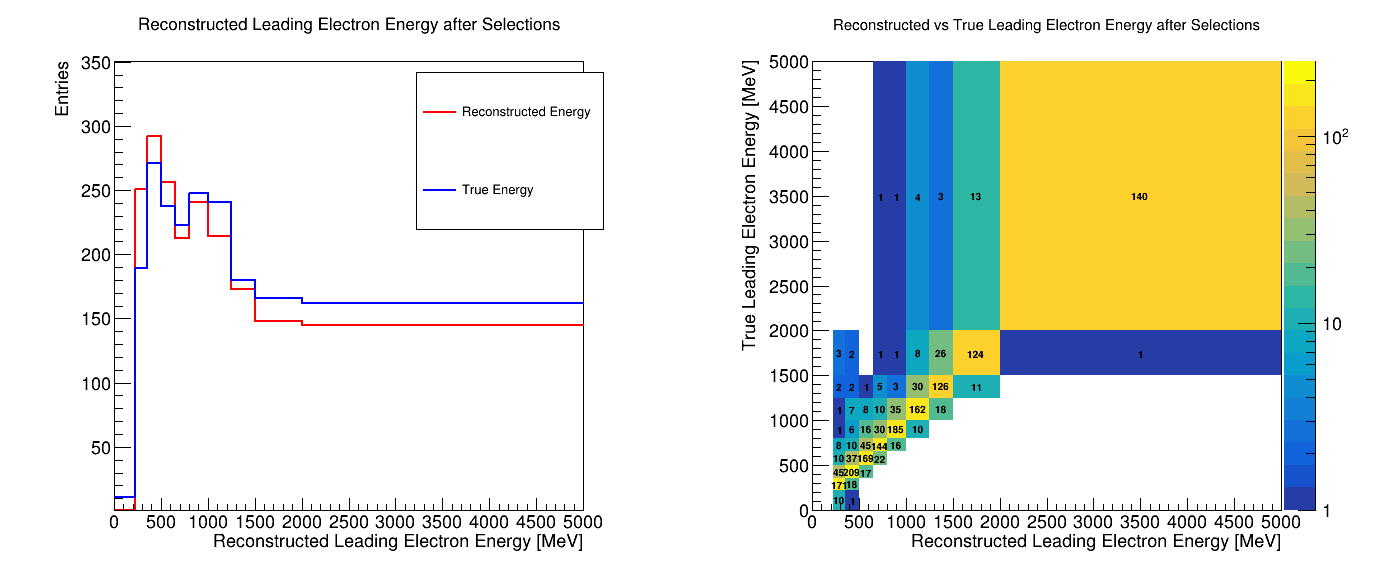

In [79]:
# bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

h_reco_energy = r.TH1F("h_reco_energy", "h_reco_energy", len(bins)-1, np.array(bins, dtype='d'))
h_true_energy = r.TH1F("h_true_energy", "h_true_energy", len(bins)-1, np.array(bins, dtype='d'))

h_energy2d = r.TH2F("h_energy2d", "h_energy2d", len(bins)-1, np.array(bins, dtype='d'), len(bins)-1, np.array(bins, dtype='d'))

h_reco_energy.FillN(len(reco_energy), arr.array('d', reco_energy), np.ones(len(reco_energy)))
h_true_energy.FillN(len(true_energy), arr.array('d', true_energy), np.ones(len(true_energy)))
h_energy2d.FillN(len(reco_energy), arr.array('d', reco_energy), arr.array('d', true_energy), np.ones(len(reco_energy)))

c1 = r.TCanvas("c1", "c1", 1400, 600)
c1.Divide(2, 1)

c1.cd(1)
h_reco_energy.SetLineColor(r.kRed)
h_reco_energy.SetLineWidth(2)
h_reco_energy.SetTitle("Reconstructed Leading Electron Energy after Selections; Reconstructed Leading Electron Energy [MeV]; Entries")
h_reco_energy.GetYaxis().SetRangeUser(1, max(h_reco_energy.GetMaximum(), h_true_energy.GetMaximum()) * 1.2)
h_reco_energy.Draw()
h_true_energy.SetLineColor(r.kBlue)
h_true_energy.SetLineWidth(2)
h_true_energy.SetTitle("True Leading Electron Energy after Selections; True Leading Electron Energy [MeV]; Entries")
h_true_energy.Draw("SAME")

l = r.TLegend(0.6, 0.6, 0.88, 0.88)
l.AddEntry(h_reco_energy, f"Reconstructed Energy", "l")
l.AddEntry(h_true_energy, f"True Energy", "l")
l.Draw()

r.gPad.SetRightMargin(0.15)
r.gPad.SetLeftMargin(0.15)

c1.cd(2)
h_energy2d.SetTitle("Reconstructed vs True Leading Electron Energy after Selections; Reconstructed Leading Electron Energy [MeV]; True Leading Electron Energy [MeV]")
h_energy2d.GetZaxis().SetRangeUser(1, h_energy2d.GetMaximum() * 1.2)
h_energy2d.Draw("COLZ TEXT")
r.gPad.SetLogz()
r.gPad.SetLeftMargin(0.15)
r.gPad.SetRightMargin(0.15)

c1.Draw()

%jsroot off

In [82]:
a_reco = np.cos(fall['reco_ele_beam_open_angle'].array())
a_true = np.cos(fall['true_ele_beam_open_angle'].array())

fullSel = ak.ones_like(a_true, dtype=bool)
for sel in selections:
    print(f"Applying selection: {sel.label}")
    # Use the apply_cut method instead of hardcoded == 1
    fullSel = fullSel & sel.apply_cut(fall[sel.name].array())

category = fall['true_category'].array()[fullSel]
    
reco_angle = a_reco[fullSel]
reco_angle = reco_angle[(category == 0)]
true_angle = a_true[fullSel]
true_angle = true_angle[(category == 0)]

Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Flash Cut
Applying selection: Interaction Containment Cut
Applying selection: Vertex Distance < 3.25 cm
Applying selection: >=1 Electron-like Particle
Applying selection: 0 Muon-like Particles
Applying selection: Leading Electron Softmax > 0.72
Applying selection: Leading Electron Primary Softmax > 0.97
Applying selection: Leading Electron Energy > 225 MeV


Warning in <TROOT::Append>: Replacing existing TH1: h_reco_angle (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_true_angle (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_angle2d (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


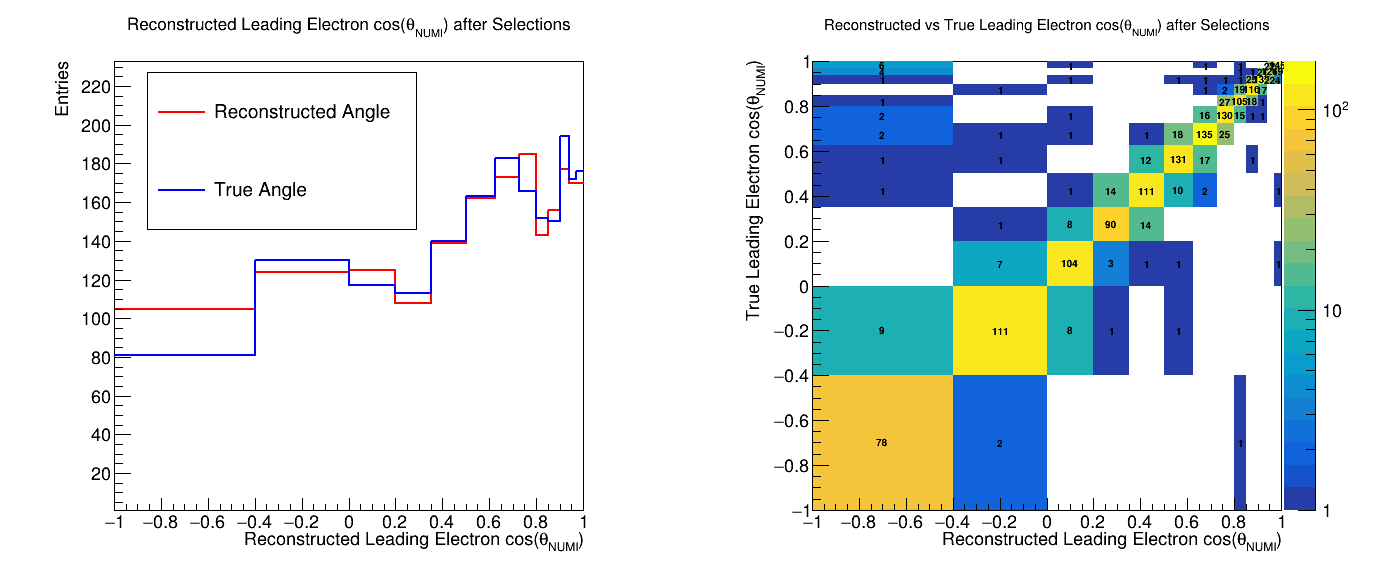

In [83]:
bins = [-1.0, -0.4, 0.0, 0.2, 0.35, 0.5, 0.625, 0.725, 0.8, 0.85, 0.9, 0.94, 0.97, 1.0]

h_reco_angle = r.TH1F("h_reco_angle", "h_reco_angle", len(bins)-1, np.array(bins, dtype='d'))
h_true_angle = r.TH1F("h_true_angle", "h_true_angle", len(bins)-1, np.array(bins, dtype='d'))

h_angle2d = r.TH2F("h_angle2d", "h_angle2d", len(bins)-1, np.array(bins, dtype='d'), len(bins)-1, np.array(bins, dtype='d'))

h_reco_angle.FillN(len(reco_angle), arr.array('d', reco_angle), np.ones(len(reco_angle)))
h_true_angle.FillN(len(true_angle), arr.array('d', true_angle), np.ones(len(true_angle)))
h_angle2d.FillN(len(reco_angle), arr.array('d', reco_angle), arr.array('d', true_angle), np.ones(len(reco_angle)))

c1 = r.TCanvas("c1", "c1", 1400, 600)
c1.Divide(2, 1)

c1.cd(1)
h_reco_angle.SetLineColor(r.kRed)
h_reco_angle.SetLineWidth(2)
h_reco_angle.SetTitle("Reconstructed Leading Electron cos(#theta_{NUMI}) after Selections; Reconstructed Leading Electron cos(#theta_{NUMI}); Entries")
h_reco_angle.GetYaxis().SetRangeUser(1, max(h_reco_angle.GetMaximum(), h_true_angle.GetMaximum()) * 1.2)
h_reco_angle.Draw()
h_true_angle.SetLineColor(r.kBlue)
h_true_angle.SetLineWidth(2)
h_true_angle.SetTitle("True Leading Electron cos(#theta_{NUMI}) after Selections; True Leading Electron cos(#theta_{NUMI}); Entries")
h_true_angle.Draw("SAME")

l = r.TLegend(0.2, 0.6, 0.6, 0.88)
l.AddEntry(h_reco_angle, f"Reconstructed Angle", "l")
l.AddEntry(h_true_angle, f"True Angle", "l")
l.Draw()

r.gPad.SetRightMargin(0.15)
r.gPad.SetLeftMargin(0.15)

c1.cd(2)
h_angle2d.SetTitle("Reconstructed vs True Leading Electron cos(#theta_{NUMI}) after Selections; Reconstructed Leading Electron cos(#theta_{NUMI}); True Leading Electron cos(#theta_{NUMI})")
h_angle2d.GetZaxis().SetRangeUser(1, h_angle2d.GetMaximum() * 1.2)
h_angle2d.Draw("COLZ TEXT")
r.gPad.SetLogz()
r.gPad.SetLeftMargin(0.15)
r.gPad.SetRightMargin(0.15)

c1.Draw()

### Draw the initial and final counts in bins to check efficiency calculation

In [55]:
fullSel = ak.ones_like(fall['reco_leading_electron_energy'].array(), dtype=bool)
for sel in selections:
    print(f"Applying selection: {sel.label}")
    # Use the apply_cut method instead of hardcoded == 1
    fullSel = fullSel & sel.apply_cut(fall[sel.name].array())

signal_nocut = fall['true_category'].array()[selections[0].apply_cut(fall[selections[0].name].array())] == 0
signal = fall['true_category'].array()[fullSel] == 0

reco_energy_nocut = fall['reco_leading_electron_energy'].array()[selections[0].apply_cut(fall[selections[0].name].array())]
reco_energy_nocut = reco_energy_nocut[signal_nocut]

reco_energy = fall['reco_leading_electron_energy'].array()[fullSel]
reco_energy = reco_energy[signal]   

bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

h_reco_energy_nocut = r.TH1F("h_reco_energy_nocut", "h_reco_energy_nocut", len(bins)-1, np.array(bins, dtype='d'))
h_reco_energy = r.TH1F("h_reco_energy", "h_reco_energy", len(bins)-1, np.array(bins, dtype='d'))

h_reco_energy_nocut.FillN(len(reco_energy_nocut), arr.array('d', reco_energy_nocut), np.ones(len(reco_energy_nocut)))
h_reco_energy.FillN(len(reco_energy), arr.array('d', reco_energy), np.ones(len(reco_energy)))

c1 = r.TCanvas("c1", "c1", 800, 600)
h_reco_energy_nocut.SetLineColor(r.kRed)
h_reco_energy_nocut.SetLineWidth(2)
h_reco_energy_nocut.SetTitle("Reconstructed Leading Electron Energy; Reconstructed Leading Electron Energy [MeV]; Entries")
h_reco_energy_nocut.GetYaxis().SetRangeUser(1, max(h_reco_energy_nocut.GetMaximum(), h_reco_energy.GetMaximum()) * 1.2)
h_reco_energy.SetLineColor(r.kBlue)
h_reco_energy.SetLineWidth(2)
h_reco_energy.SetTitle("Reconstructed Leading Electron Energy after Selections; Reconstructed Leading Electron Energy [MeV]; Entries")

Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Flash Cut
Applying selection: Interaction Containment Cut
Applying selection: Vertex Distance < 3.25 cm
Applying selection: >=1 Electron-like Particle
Applying selection: 0 Muon-like Particles
Applying selection: Leading Electron Softmax > 0.72
Applying selection: Leading Electron Primary Softmax > 0.97
Applying selection: Leading Electron Energy > 225 MeV


Warning in <TROOT::Append>: Replacing existing TH1: h_reco_energy_nocut (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco_energy (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


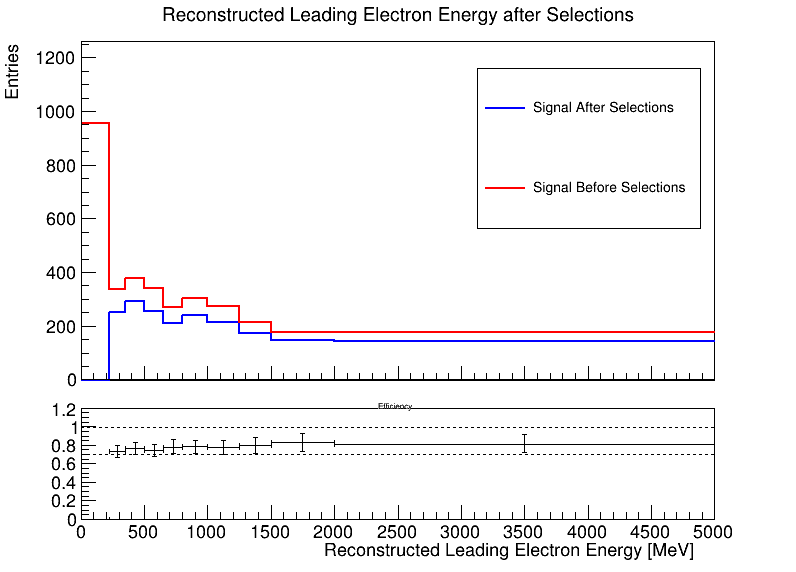

In [56]:
%jsroot off

h_ratio = r.TRatioPlot(h_reco_energy, h_reco_energy_nocut, "pois")
h_ratio.SetH1DrawOpt("hist")
h_ratio.SetH2DrawOpt("hist")

l = r.TLegend(0.6, 0.6, 0.88, 0.88)
l.AddEntry(h_reco_energy, f"Signal After Selections", "l")
l.AddEntry(h_reco_energy_nocut, f"Signal Before Selections", "l")

h_ratio.Draw()

l.Draw()

# h_ratio.GetUpperPad().SetLogy(0)
h_ratio.GetUpperRefObject().SetMinimum(0.)
h_ratio.GetUpperRefObject().SetMaximum(h_reco_energy_nocut.GetMaximum() * 1.1)
h_ratio.GetLowerRefGraph().SetMinimum(0.)
h_ratio.GetLowerRefGraph().SetMaximum(1.2)
h_ratio.GetLowerRefGraph().SetTitle("Efficiency")
# h_ratio.GetLowerRefGraph().GetYaxis().SetTitleSize(0.1)
# h_ratio.GetLowerRefGraph().GetYaxis().SetTitleOffset(0.5)
# h_ratio.GetLowerRefGraph().GetYaxis().SetLabelSize(0.08)
h_ratio.GetLowerRefGraph().SetLineColor(r.kBlack)
# h_ratio.GetLowerPad().SetLogy(0)
c1.Draw()
c1.SetLogy(1)

# Make Plots with spineplot

### efficiency plots are too memory intensive to run here, run on build node and then fix plots here

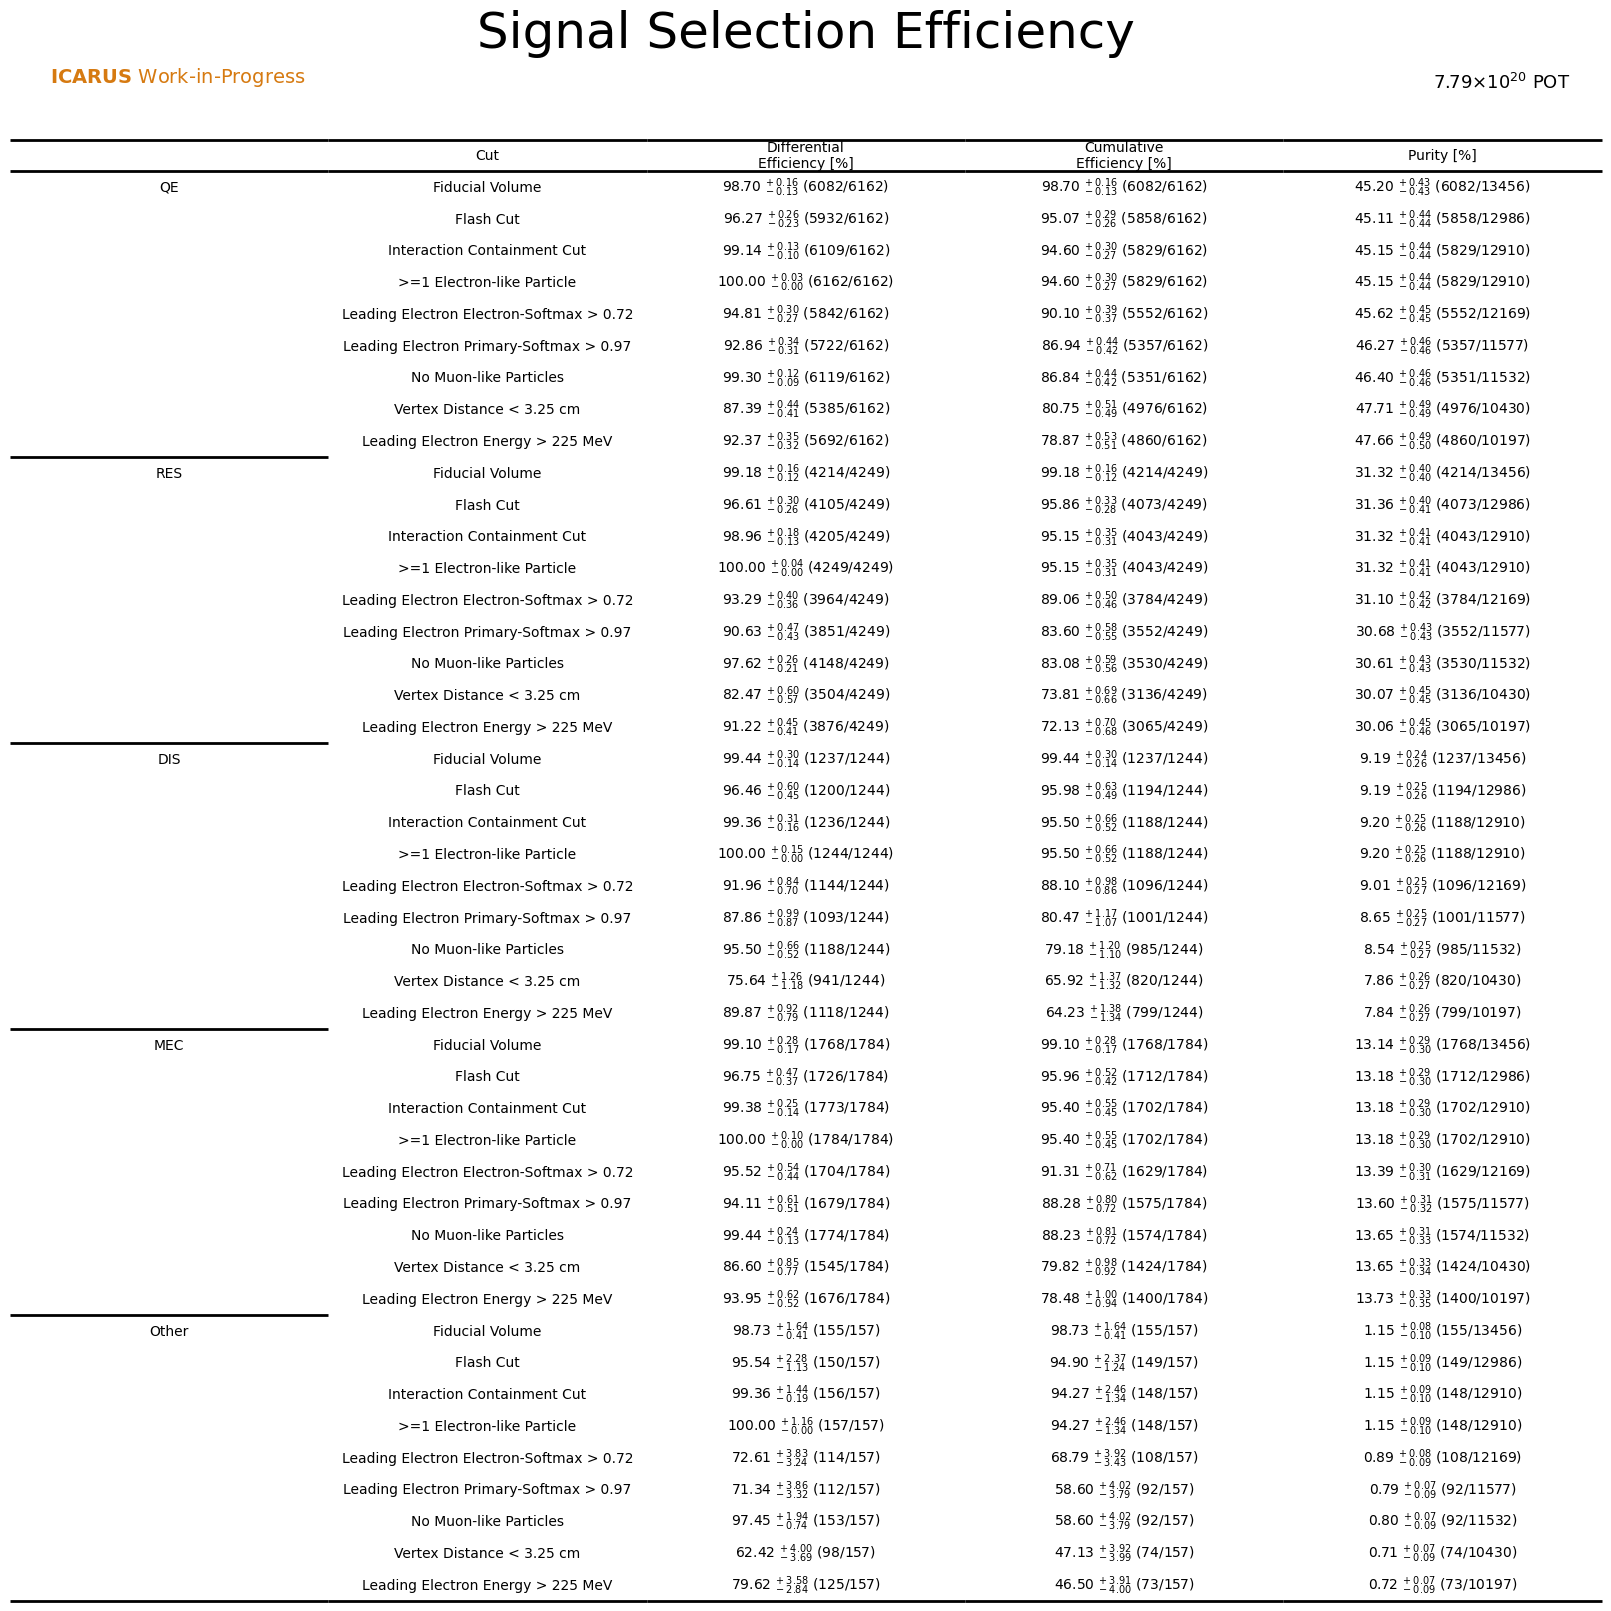

In [35]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_true_neutrino_interaction_trueTree/selection_efficiency_table.pkl', 'rb') as f:
    eff = pickle.load(f)
    eff.set_size_inches(16, 16)
    ax = eff.axes[0]
    table = ax.tables[0]
    table.auto_set_font_size(False)
    table.set_fontsize(10)

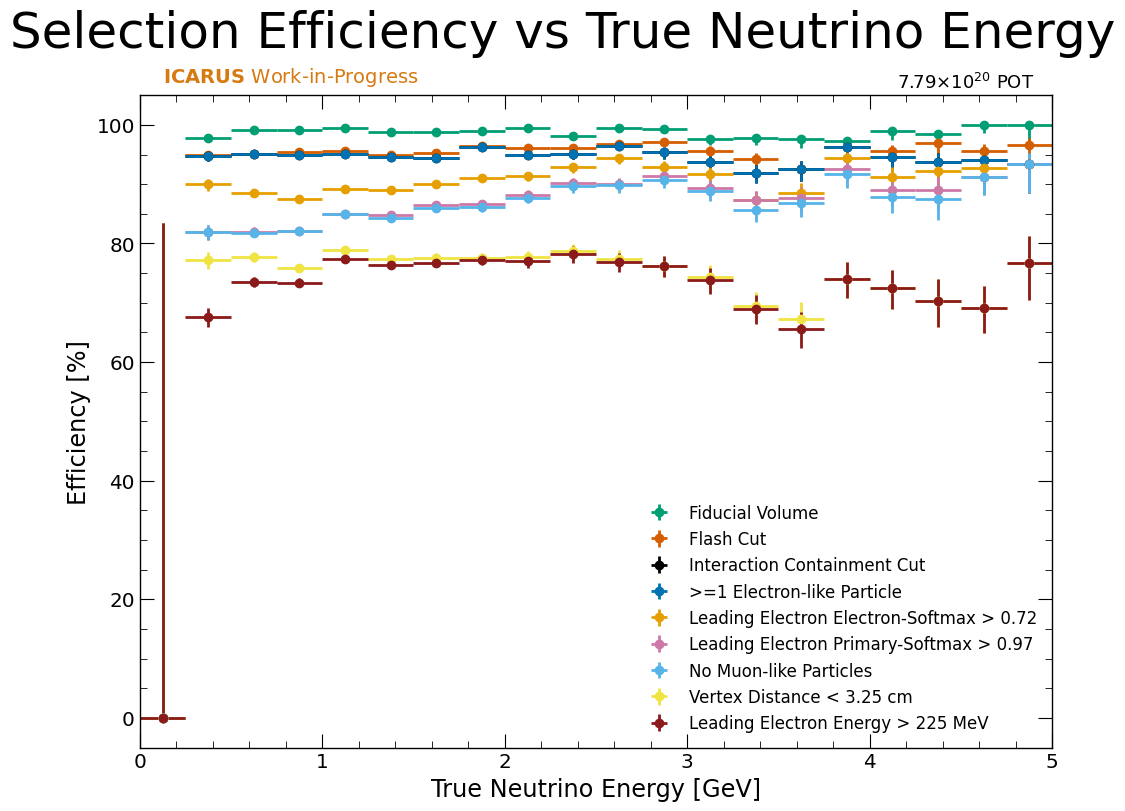

In [255]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_energy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    # ax = eff_nuE.axes[0]
    # ax.set_yscale('log')
    # ax.set_ylim(1e-3, 100)

    # ymin, ymax = ax.get_ylim()
    # if ymin <= 0:
    #     pos_vals = []
    #     for line in ax.lines:
    #         y = np.asarray(line.get_ydata())
    #         pos_vals.extend(y[y > 0].tolist())
    #     if len(pos_vals) > 0:
    #         ymin_new = min(pos_vals)
    #     else:
    #         ymin_new = 1e-5
    #     ax.set_ylim(ymin_new * 0.5, max(ymax, ymin_new * 20))

    # ax.grid(True, which='both', ls='--', alpha=0.6)
    # plt.show()

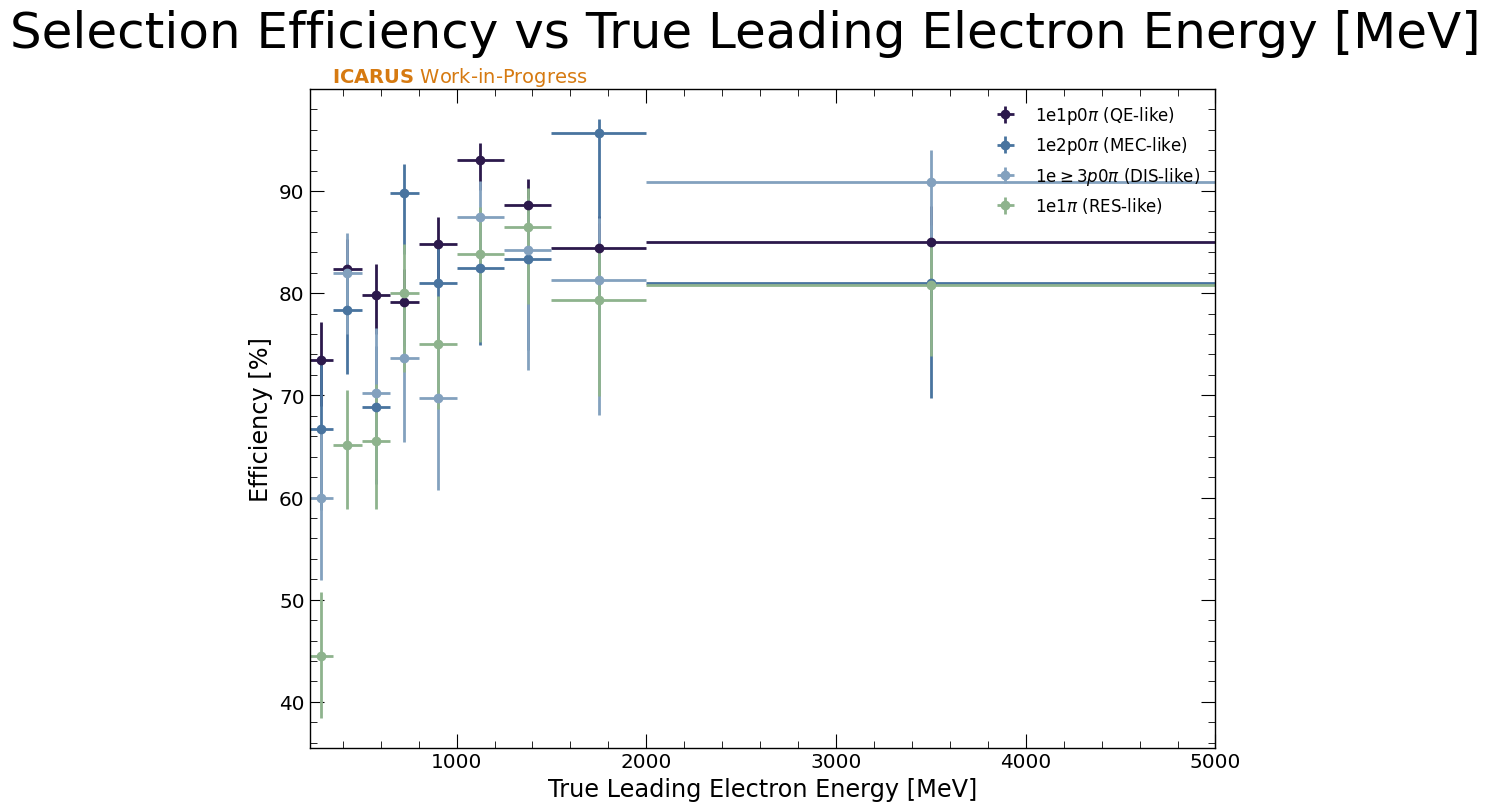

In [80]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_interaction_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

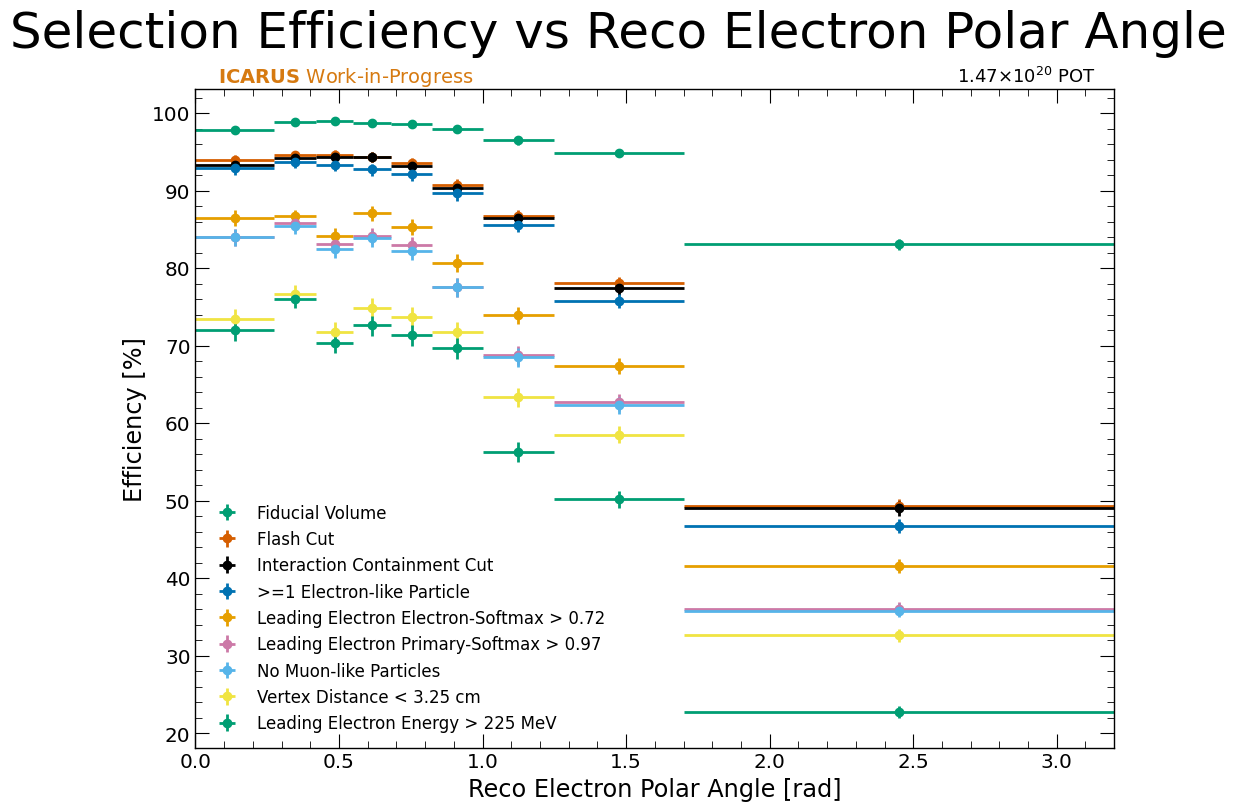

In [30]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_electronAngle.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

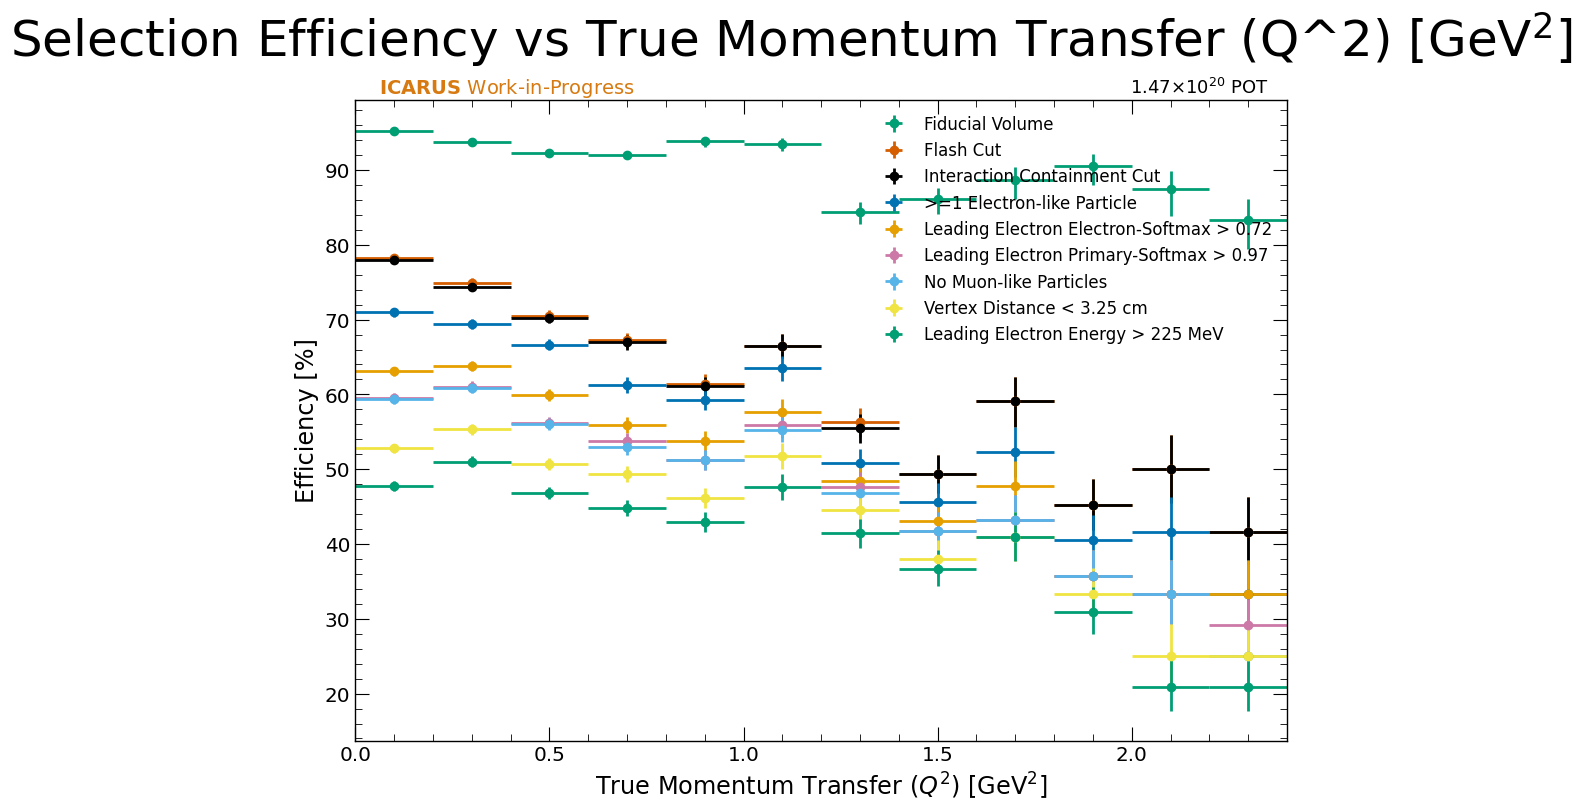

In [31]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_trueMomentumTransfer.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

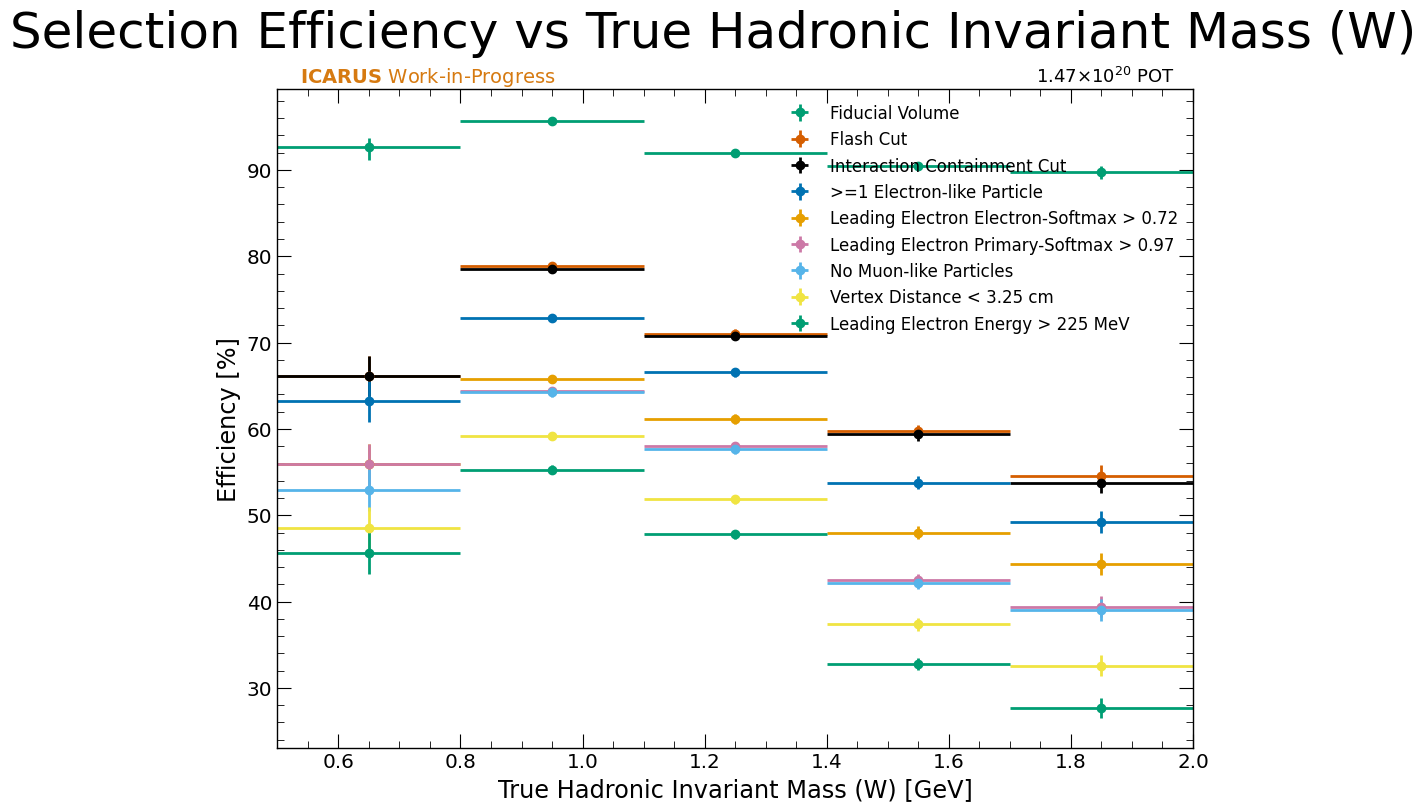

In [32]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_trueInvMass.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

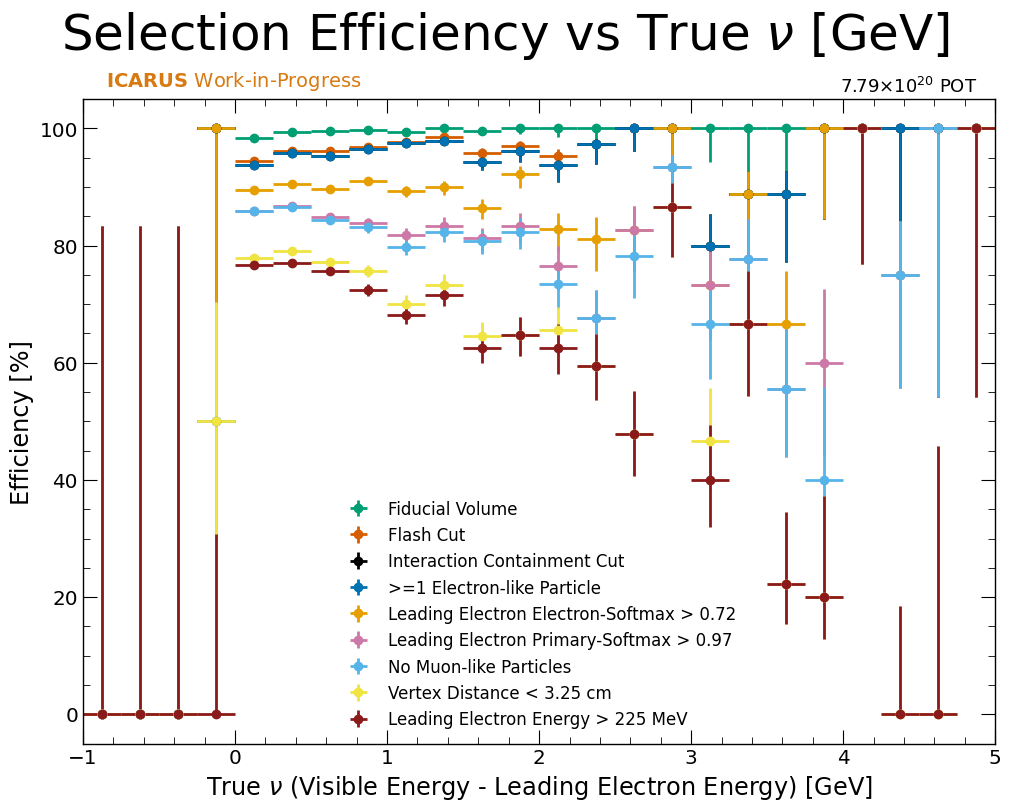

In [4]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_trueNu.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

In [84]:
# extract histogram data from h_nuE (robust to bars/lines/paches)
def _extract_hist(ax):
    # 1) bar containers (matplotlib.container.BarContainer)
    if len(ax.containers) > 0:
        all_heights = None
        base_lefts = None
        base_widths = None
        for cont in ax.containers:
            lefts = [rect.get_x() for rect in cont]
            widths = [rect.get_width() for rect in cont]
            heights = np.array([rect.get_height() for rect in cont], dtype=float)

            if all_heights is None:
                all_heights = heights
                base_lefts = lefts
                base_widths = widths
            else:
                # align lengths if containers differ (pad with zeros)
                if len(heights) < len(all_heights):
                    heights = np.pad(heights, (0, len(all_heights) - len(heights)), constant_values=0.0)
                elif len(heights) > len(all_heights):
                    all_heights = np.pad(all_heights, (0, len(heights) - len(all_heights)), constant_values=0.0)
                all_heights += heights

        if base_lefts is None:
            raise RuntimeError("No bar containers found")
        edges = np.array(base_lefts + [base_lefts[-1] + base_widths[-1]])
        return edges, all_heights
    # 2) Line2D (step or line)
    lines = ax.get_lines()
    if len(lines) > 0:
        line = lines[0]
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())
        return x, y
    # 3) individual patches
    patches = getattr(ax, "patches", [])
    if patches:
        lefts = [p.get_x() for p in patches]
        widths = [p.get_width() for p in patches]
        heights = [p.get_height() for p in patches]
        edges = np.array(lefts + [lefts[-1] + widths[-1]])
        return edges, np.array(heights)
    raise RuntimeError("No histogram found on the provided Axes")

NameError: name '_extract_hist' is not defined

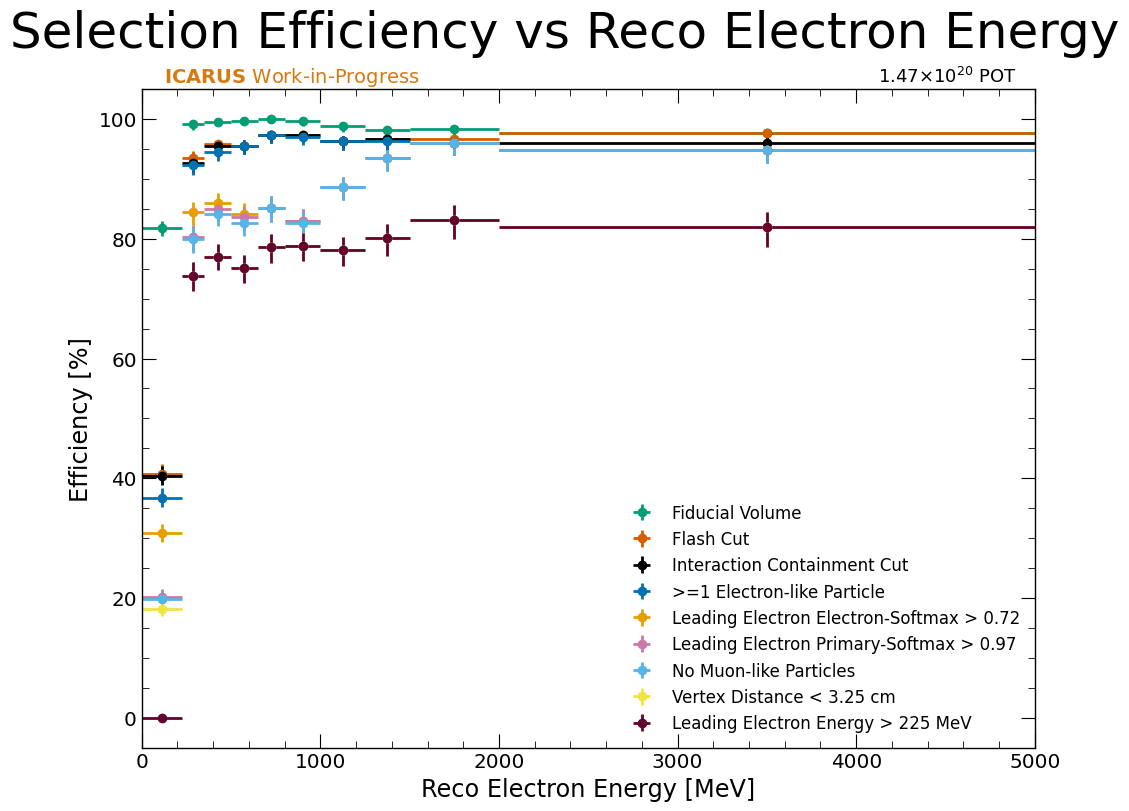

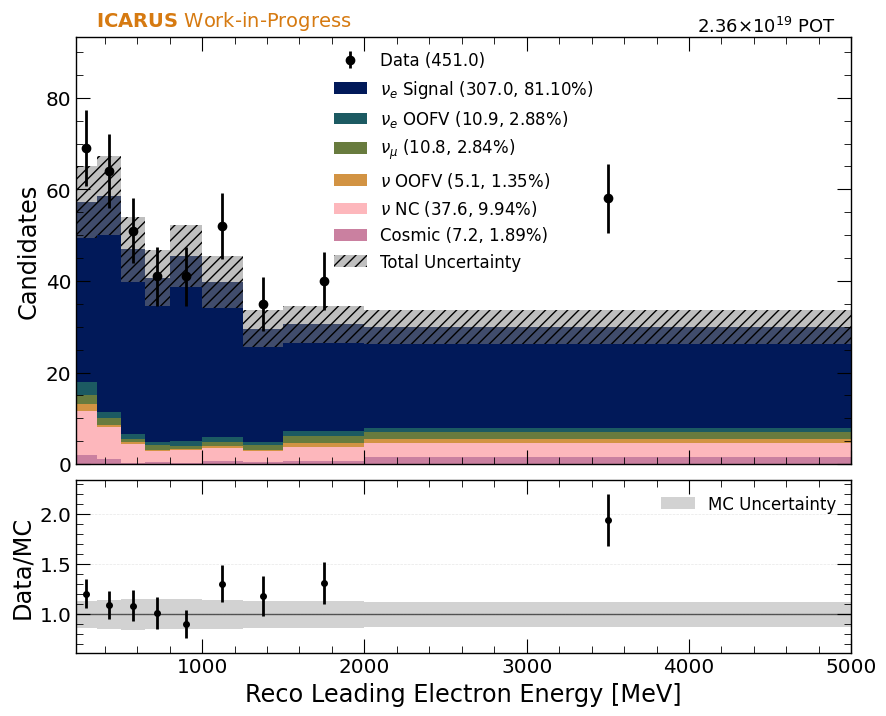

In [247]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_electronEnergy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

with open('/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_reco_leading_electron_energy.pkl', 'rb') as f:
    h_nuE = pickle.load(f)
    h_nuE.set_size_inches(10, 8)

    ax_hist = h_nuE.axes[0]
    ax_eff = eff_nuE.axes[0]

    edges_or_x, counts_or_y = _extract_hist(ax_hist)

    # plot histogram onto eff_nuE using a twin y-axis (keeps efficiency scale intact)
    ax2 = ax_eff.twinx()
    if len(edges_or_x) == len(counts_or_y) + 1:
        # edges + counts
        edges = edges_or_x
        counts = counts_or_y
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths = edges[1:] - edges[:-1]
        ax2.bar(centers, counts, width=widths, alpha=0.35, color='gray', label='Counts (from h_nuE)', align='center')
    else:
        # line-style data
        x = edges_or_x
        y = counts_or_y
        ax2.step(x, y, where='mid', color='gray', alpha=0.8, label='Counts (from h_nuE)')

    # ax2.set_ylabel('Counts')
    # ax2.legend(loc='upper right')
    ax_eff.legend(loc='lower right')

    # draw/update the figure
    eff_nuE.canvas.draw()
    # plt.show()

## Overlay Efficiency and Histogram Plots

In [3]:
import pickle
import copy

def overlay_hist_on_efficiency(eff_path, hist_path,
                               alpha=0.35,
                               figsize=(12, 6),
                               hist_legend_loc=None,
                               hist_legend_anchor=(0.0, 1.0),
                               eff_legend_loc='lower right',
                               eff_legend_anchor=(1.0, 0.0),
                               new_title=None):
    with open(eff_path, 'rb') as f:
        eff_fig = pickle.load(f)
    with open(hist_path, 'rb') as f:
        hist_fig = pickle.load(f)

    ax_eff  = eff_fig.axes[0]
    ax_hist = hist_fig.axes[0]

    # twin y-axis on the efficiency figure (keeps efficiency scale intact)
    ax2 = ax_eff.twinx()
    ax2.set_ylabel('Counts')
    all_ymax = []

    # --- option 1: stacked bar containers (preserves per-category colours) ---
    if len(ax_hist.containers) > 0:
        bottom = None
        for cont in ax_hist.containers:
            lefts   = np.array([rect.get_x()     for rect in cont])
            widths  = np.array([rect.get_width()  for rect in cont])
            heights = np.array([rect.get_height() for rect in cont], dtype=float)
            color   = cont.patches[0].get_facecolor()
            # label lives on the first patch, not the container itself
            patch_label = cont.patches[0].get_label()
            label = patch_label if patch_label and not patch_label.startswith('_') else None
            centers = lefts + widths / 2
            ax2.bar(centers, heights, width=widths, bottom=bottom,
                    alpha=alpha, color=color, align='center', label=label)
            bottom = heights if bottom is None else bottom + heights
        if bottom is not None:
            all_ymax.append(float(np.nanmax(bottom)))

    # --- option 2: Line2D (step or line histogram) ---
    elif len(ax_hist.get_lines()) > 0:
        for line in ax_hist.get_lines():
            ydata = line.get_ydata()
            ax2.step(line.get_xdata(), ydata, where='mid',
                     color=line.get_color(), alpha=alpha,
                     linewidth=line.get_linewidth(), label=line.get_label())
            all_ymax.append(float(np.nanmax(ydata)))

    # --- option 3: individual patches (e.g. stairs / fill_between) ---
    elif len(ax_hist.patches) > 0:
        from matplotlib.patches import StepPatch
        step_patches = [p for p in ax_hist.patches if isinstance(p, StepPatch)]
        rect_patches = [p for p in ax_hist.patches if not isinstance(p, StepPatch)]

        if step_patches:
            # redraw StepPatch objects via stairs() to avoid coordinate-transform issues
            # facecolor alpha=0 means unfilled outlines — colour lives entirely in edgecolor
            for patch in step_patches:
                data   = patch.get_data()
                values = data.values
                edges  = data.edges
                ec   = np.array(patch.get_edgecolor()).ravel()
                fc   = np.array(patch.get_facecolor()).ravel()
                # use edgecolor RGB as the line colour; inherit fill only if fc alpha > 0
                edgecolor = ec[:3]
                filled    = fc[3] > 0
                facecolor = fc[:3] if filled else 'none'
                patch_label = patch.get_label()
                label = patch_label if patch_label and not patch_label.startswith('_') else None
                ax2.stairs(values, edges,
                           color=edgecolor,
                           fill=filled, facecolor=facecolor,
                           alpha=alpha, label=label)
                all_ymax.append(float(np.nanmax(values)))
        else:
            for patch in rect_patches:
                p2 = copy.copy(patch)
                p2.figure = None
                p2.axes   = None
                p2.set_alpha(alpha)
                ax2.add_patch(p2)
                if hasattr(patch, 'get_height'):
                    all_ymax.append(patch.get_height())

    else:
        raise RuntimeError("No histogram data found on the provided axes")

    # set hist y-axis to 1.2x the maximum value across all drawn elements
    if all_ymax:
        ax2.set_ylim(0, max(all_ymax) * 1.2)

    # legends: clear existing legends first, then only draw when loc is provided
    eff_existing_legend = ax_eff.get_legend()
    if eff_existing_legend is not None:
        eff_existing_legend.remove()
    if eff_legend_loc is not None:
        ax_eff.legend(loc=eff_legend_loc, bbox_to_anchor=eff_legend_anchor,
                      fontsize=9, framealpha=0.7)

    hist_existing_legend = ax2.get_legend()
    if hist_existing_legend is not None:
        hist_existing_legend.remove()
    hist_handles, hist_labels = ax2.get_legend_handles_labels()
    if hist_legend_loc is not None and hist_handles:
        ax2.legend(handles=hist_handles, labels=hist_labels,
                   loc=hist_legend_loc, bbox_to_anchor=hist_legend_anchor,
                   fontsize=9, framealpha=0.7)

    eff_fig.set_size_inches(figsize)
    eff_fig.canvas.draw()
    if new_title is not None:
        eff_fig.suptitle(new_title) 
    plt.close(hist_fig)
    return eff_fig

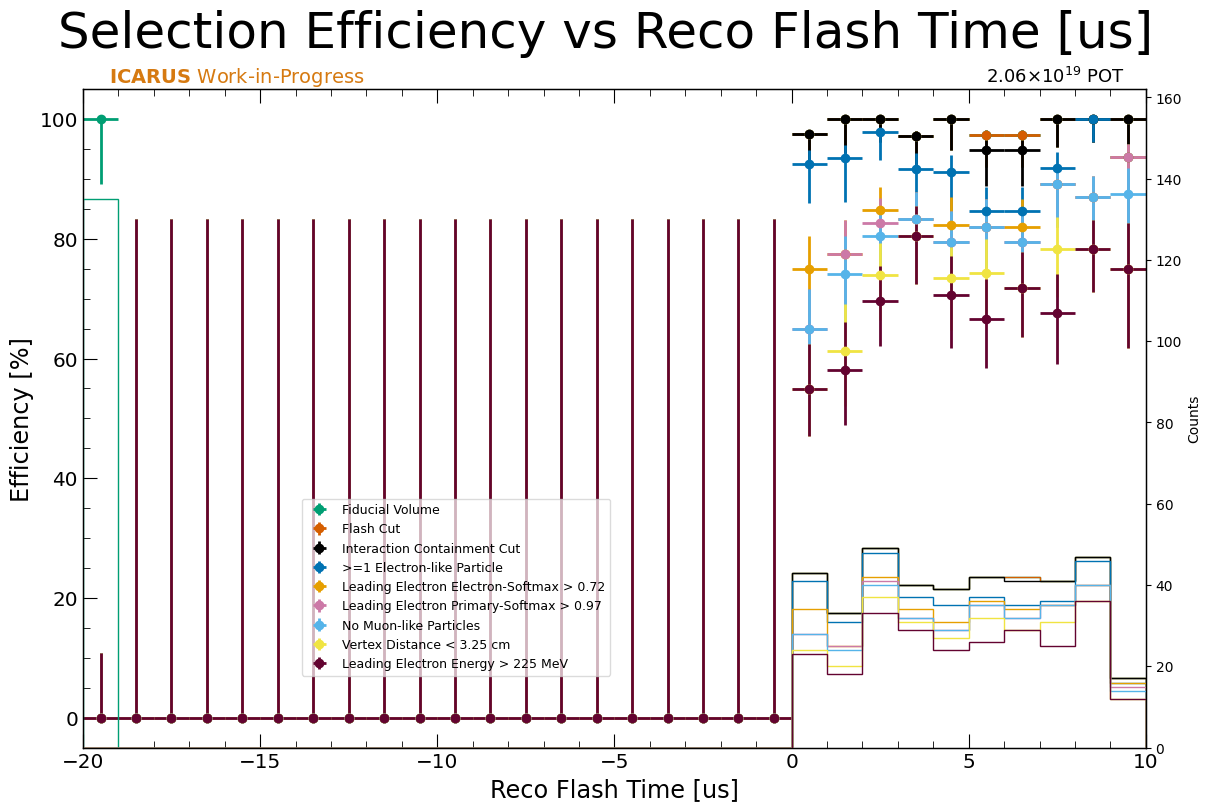


tab completion not implemented for this context


In [119]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_interactionFlashTime/efficiency_vs_recoFlashTime.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_interactionFlashTime/plot_reco_flash_time_mod.pkl',
    alpha               = 1.0,
    figsize             = (12, 8),
    hist_legend_loc     = None,
    hist_legend_anchor  = (0.2, 0.7),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.2, 0.1))
plt.show(fig)

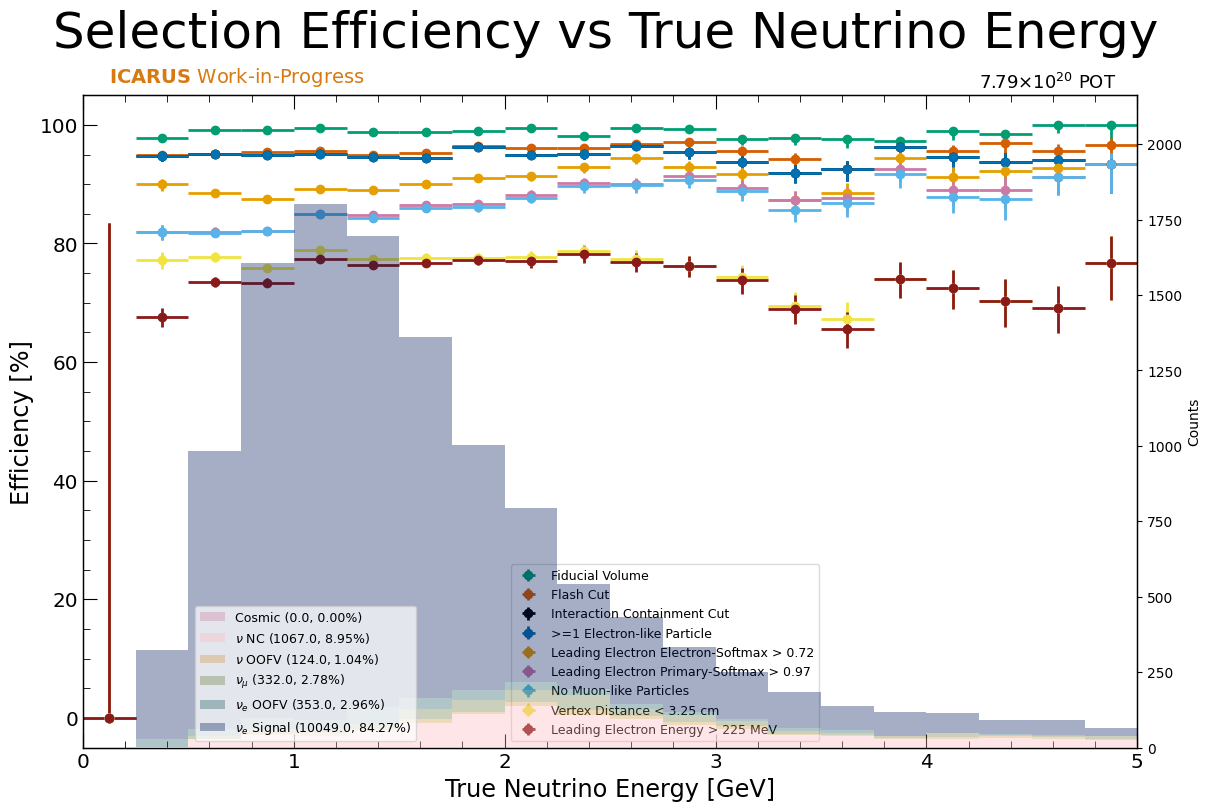

In [63]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_energy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_neutrino_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.1, 0.0),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.4, 0.0)
)
plt.show(fig)

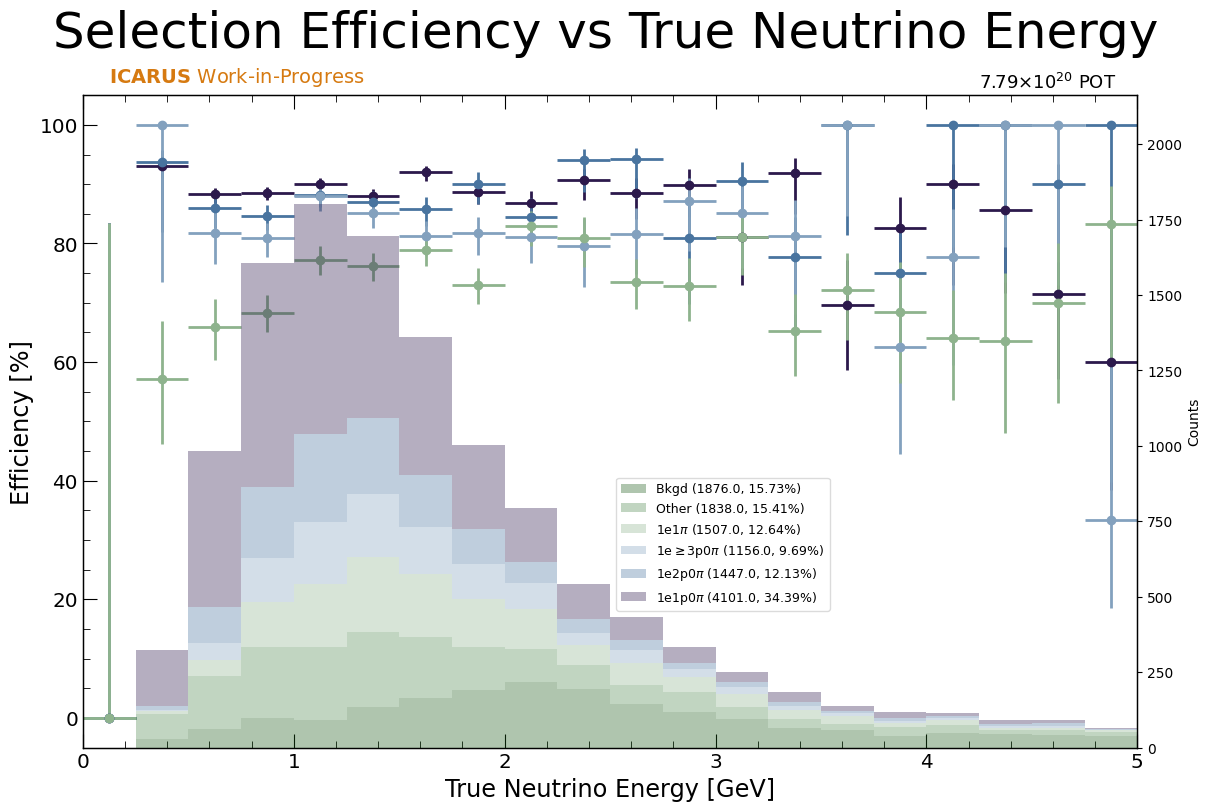

In [76]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_neutrino_interaction_trueTree/efficiency_vs_energy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_neutrino_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.5, 0.2),
    eff_legend_loc      = None,
    eff_legend_anchor   = (0.5, 0.2)
)
plt.show(fig)

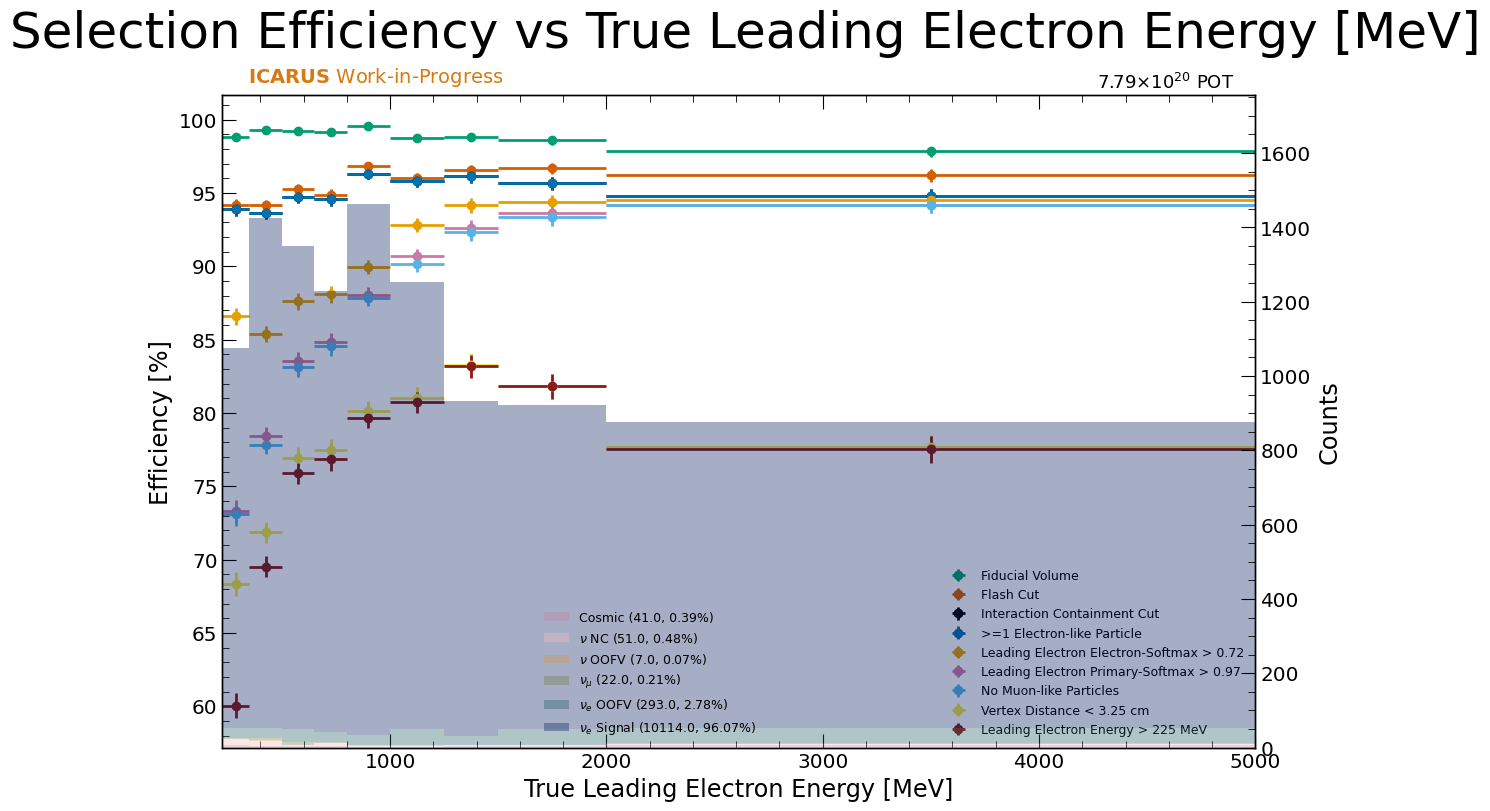

In [257]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_leading_electron_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.3, 0.0),
    eff_legend_loc      = 'lower right',
    eff_legend_anchor   = (1.0, 0.0)
)
plt.show(fig)

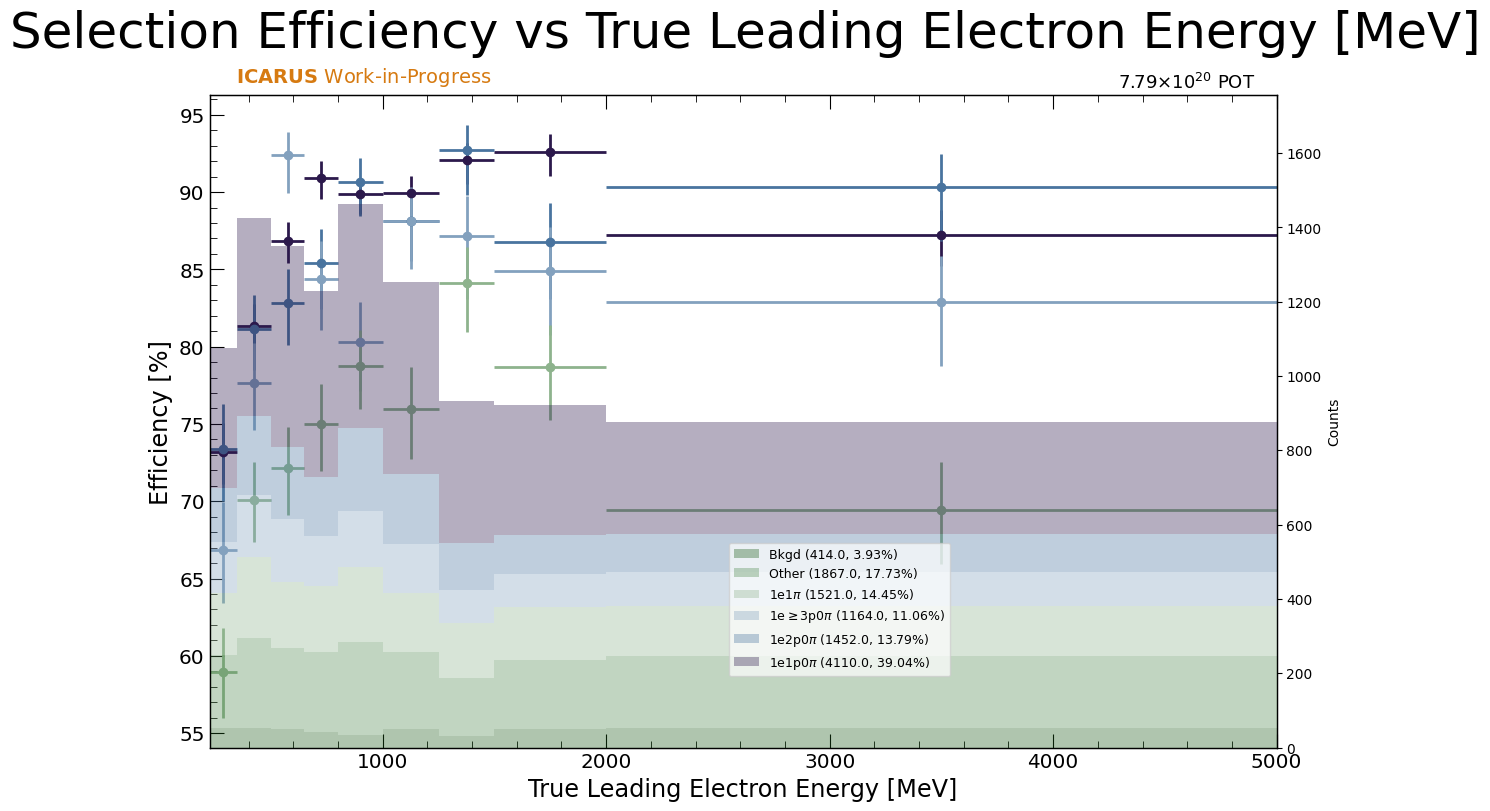

In [79]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_neutrino_interaction_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_leading_electron_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc='lower right',
    hist_legend_anchor  = (0.7, 0.1),
    eff_legend_loc      = None,
    eff_legend_anchor   = (0.7, 0.5)
)
plt.show(fig)

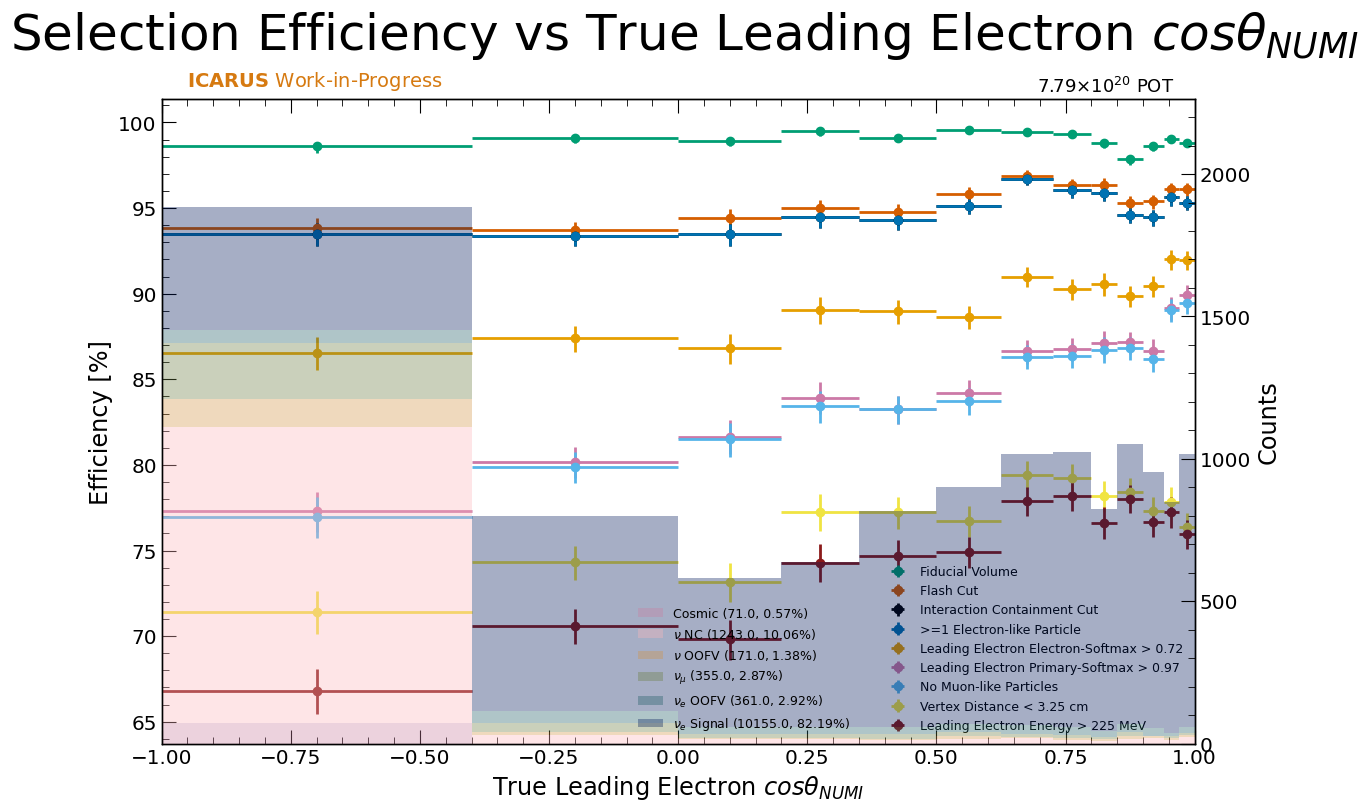

In [260]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_trueLeadingElectronAngle.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_ele_beam_cosTheta.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.45, 0.0),
    eff_legend_loc      = 'lower right',
    eff_legend_anchor   = (1.0, 0.0))
plt.show(fig)

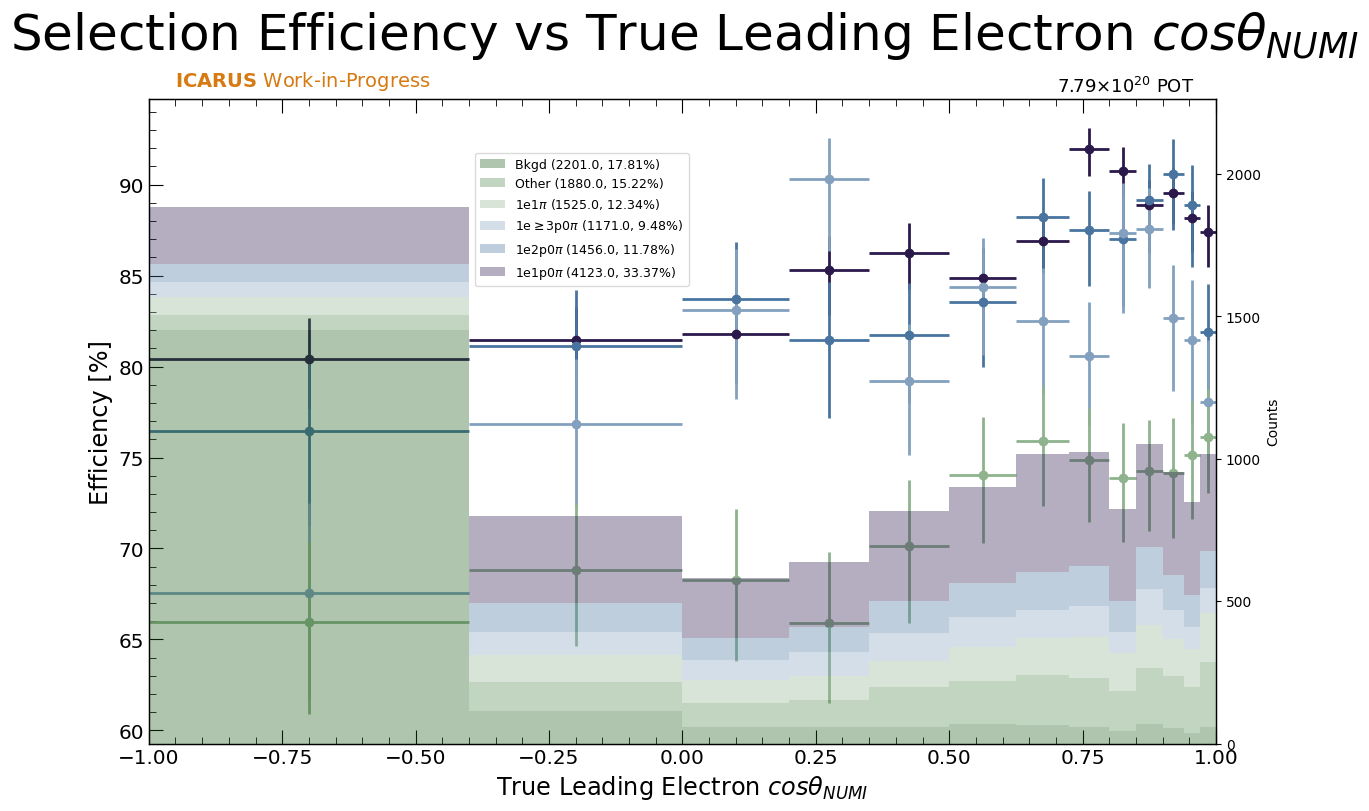

In [83]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_neutrino_interaction_trueTree/efficiency_vs_trueLeadingElectronAngle.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_ele_beam_cosTheta.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.3, 0.7),
    eff_legend_loc      = None,
    eff_legend_anchor   = (0.05, 0.8))
plt.show(fig)

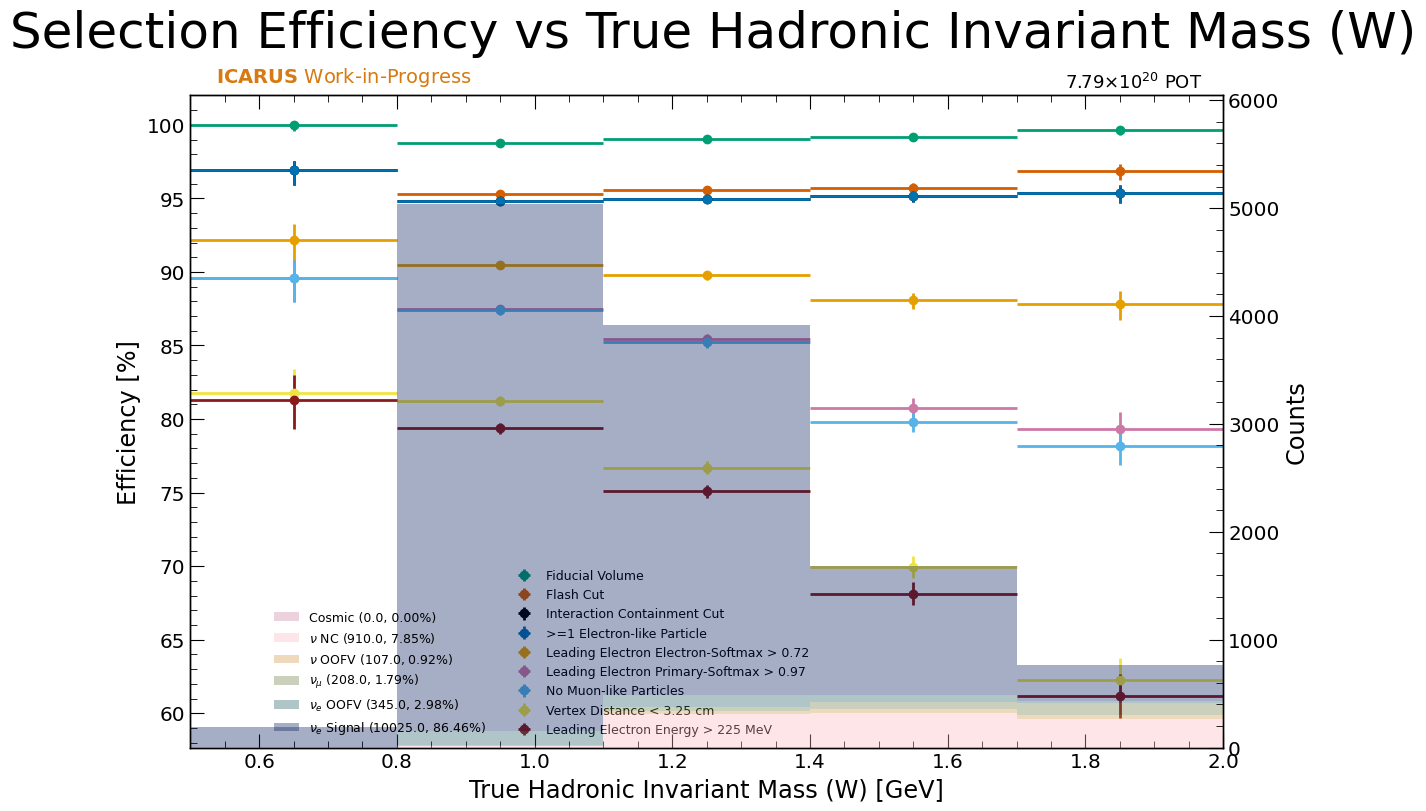

In [ ]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_trueInvMass.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_hadronic_invariant_mass.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.07, 0.0),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.3, 0.0))
plt.show(fig)

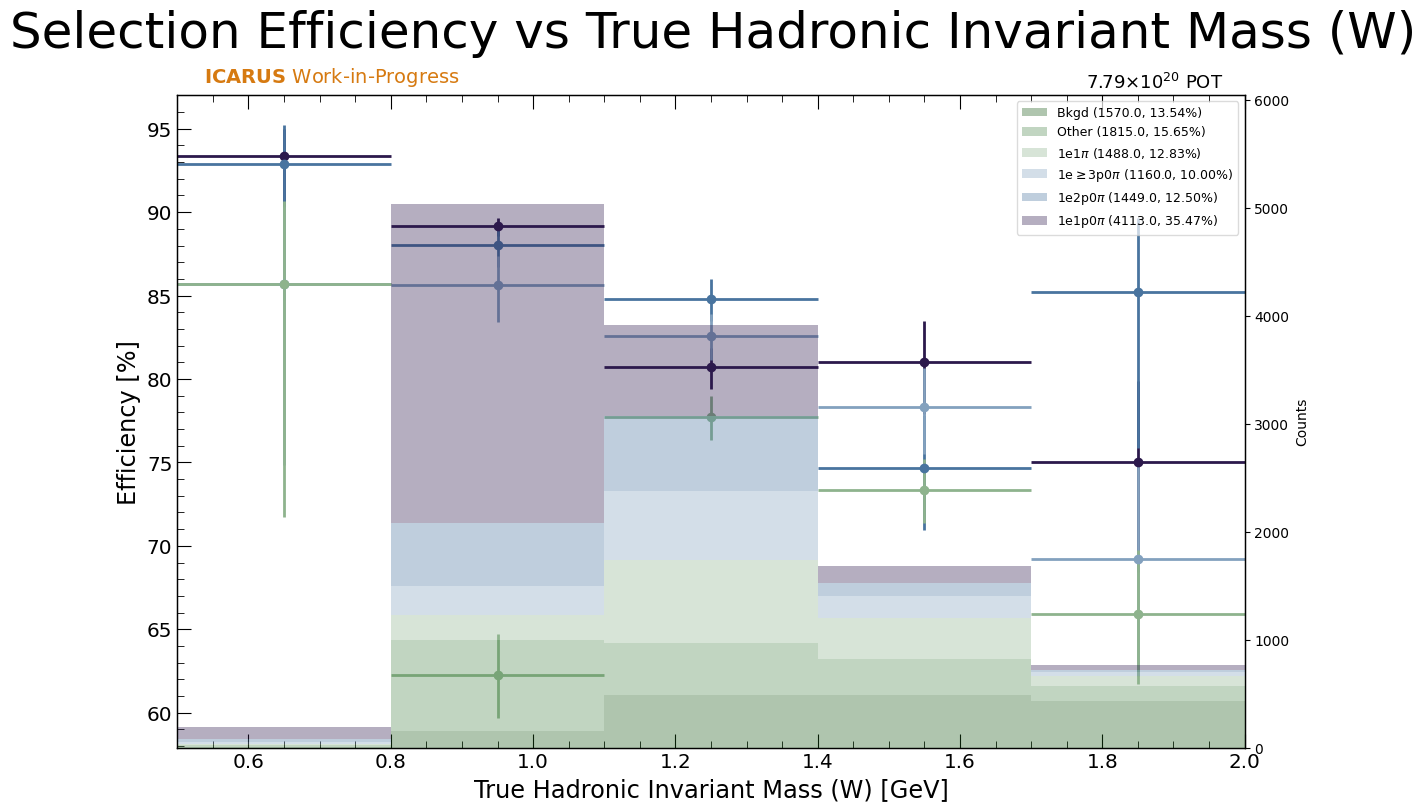

In [4]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_neutrino_interaction_trueTree/efficiency_vs_trueInvMass.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_hadronic_invariant_mass.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='upper right',
    hist_legend_anchor  = (1.0, 1.0),
    eff_legend_loc      = None,
    eff_legend_anchor   = (1.0, 1.0))
plt.show(fig)

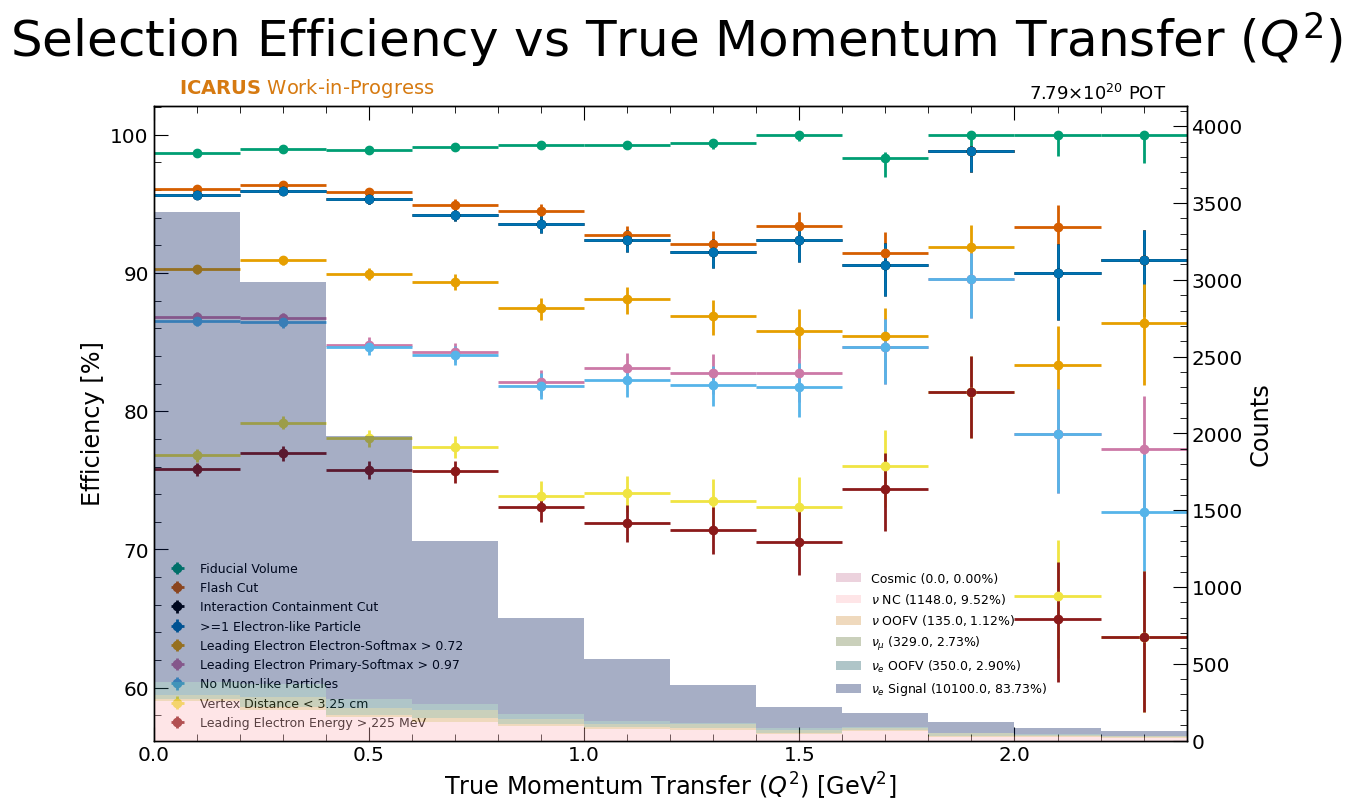

In [277]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_neutrino_interaction_trueTree/efficiency_vs_trueMomentumTransfer.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_momentum_transfer.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.65, 0.05),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.0, 0.0),
    new_title="Selection Efficiency vs True Momentum Transfer ($Q^{2}$)")
plt.show(fig)

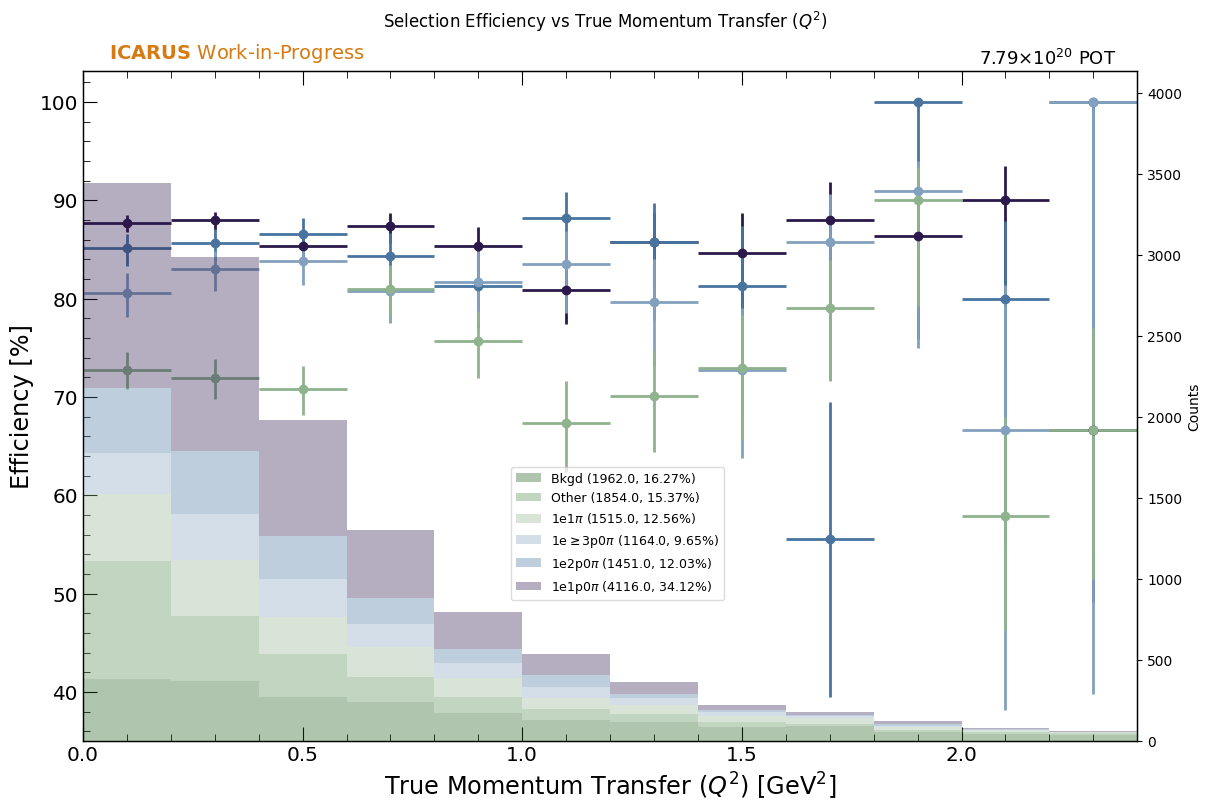

In [7]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_neutrino_interaction_trueTree/efficiency_vs_trueMomentumTransfer.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_momentum_transfer.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.4, 0.2),
    eff_legend_loc      = None,
    eff_legend_anchor   = (0.4, 0.4),
    new_title="Selection Efficiency vs True Momentum Transfer ($Q^{2}$)")
plt.show(fig)

## Draw efficiency with error bands

In [62]:
from matplotlib.container import ErrorbarContainer


def extract_info(filename):
    with open(filename, 'rb') as f:
        eff_nuE = pickle.load(f)

    # Work from the loaded figure, but do not display it.
    ax = eff_nuE.axes[0]

    errorbar_x = None
    errorbar_y = None
    errorbar_yerr = None
    bar_x = None
    bar_values = None
    bar_y = None
    bar_widths = None

    # Get errorbar data from the matplotlib ErrorbarContainer saved in the pickle.
    for cont in ax.containers:
        if not isinstance(cont, ErrorbarContainer):
            continue

        data_line = cont.lines[0]
        if data_line is None:
            continue

        errorbar_x = np.asarray(data_line.get_xdata(), dtype=float)
        errorbar_y = np.asarray(data_line.get_ydata(), dtype=float)

        npts = errorbar_y.size
        lower = np.zeros(npts, dtype=float)
        upper = np.zeros(npts, dtype=float)

        # Preferred path: vertical segments from LineCollection(s) in cont.lines[2].
        barlinecols = cont.lines[2]
        collections = []
        if isinstance(barlinecols, (tuple, list)):
            collections = [c for c in barlinecols if c is not None]
        elif barlinecols is not None:
            collections = [barlinecols]

        extracted_from_segments = False
        for coll in collections:
            if not hasattr(coll, 'get_segments'):
                continue

            segs = np.asarray(coll.get_segments(), dtype=float)
            if segs.size == 0 or segs.ndim != 3 or segs.shape[1:] != (2, 2):
                continue

            # Keep only mostly-vertical segments (y-errors, not x-errors).
            dx = np.abs(segs[:, 1, 0] - segs[:, 0, 0])
            dy = np.abs(segs[:, 1, 1] - segs[:, 0, 1])
            ymask = dy >= dx
            ysegs = segs[ymask]
            if ysegs.size == 0:
                continue

            xmid = 0.5 * (ysegs[:, 0, 0] + ysegs[:, 1, 0])
            ylow = np.minimum(ysegs[:, 0, 1], ysegs[:, 1, 1])
            yhigh = np.maximum(ysegs[:, 0, 1], ysegs[:, 1, 1])

            # Fast path when one segment per point in order.
            if len(xmid) == npts:
                lower = errorbar_y - ylow
                upper = yhigh - errorbar_y
                extracted_from_segments = True
                break

            # General path: map segments to points by x coordinate.
            for i, xi in enumerate(errorbar_x):
                tol = 1e-9 + 1e-6 * max(1.0, abs(xi))
                idx = np.where(np.isclose(xmid, xi, rtol=1e-6, atol=tol))[0]
                if idx.size > 0:
                    j = idx[0]
                    lower[i] = errorbar_y[i] - ylow[j]
                    upper[i] = yhigh[j] - errorbar_y[i]

            extracted_from_segments = True
            break

        # Fallback path: infer y-errors from cap lines in cont.lines[1].
        if not extracted_from_segments:
            caplines = cont.lines[1]
            cap_objs = []
            if isinstance(caplines, (tuple, list)):
                cap_objs = [c for c in caplines if c is not None]
            elif caplines is not None:
                cap_objs = [caplines]

            if cap_objs:
                cap_x = []
                cap_y = []
                for c in cap_objs:
                    xdata = np.asarray(c.get_xdata(), dtype=float).ravel()
                    ydata = np.asarray(c.get_ydata(), dtype=float).ravel()
                    if xdata.size == ydata.size and xdata.size > 0:
                        cap_x.append(xdata)
                        cap_y.append(ydata)

                if cap_x:
                    cap_x = np.concatenate(cap_x)
                    cap_y = np.concatenate(cap_y)
                    for i, xi in enumerate(errorbar_x):
                        tol = 1e-9 + 1e-6 * max(1.0, abs(xi))
                        idx = np.where(np.isclose(cap_x, xi, rtol=1e-6, atol=tol))[0]
                        if idx.size > 0:
                            ys = cap_y[idx]
                            lower[i] = errorbar_y[i] - np.min(ys)
                            upper[i] = np.max(ys) - errorbar_y[i]

        errorbar_yerr = np.vstack((np.clip(lower, 0.0, None), np.clip(upper, 0.0, None)))
        break

    # Get bar values from bar patches.
    bar_patches = [p for p in ax.patches if hasattr(p, 'get_height') and hasattr(p, 'get_width')]
    if bar_patches:
        bar_x = np.asarray([p.get_x() + 0.5 * p.get_width() for p in bar_patches], dtype=float)
        bar_values = np.asarray([p.get_height() for p in bar_patches], dtype=float)
        bar_y = bar_values.copy()
        bar_widths = np.asarray([p.get_width() for p in bar_patches], dtype=float)

    # Ensure we found expected plot elements.
    if errorbar_x is None or errorbar_y is None or errorbar_yerr is None:
        plt.close(eff_nuE)
        raise RuntimeError('Could not extract errorbar data from loaded figure.')
    if bar_x is None or bar_values is None or bar_y is None or bar_widths is None:
        plt.close(eff_nuE)
        raise RuntimeError('Could not extract bar data from loaded figure.')

    # Prevent the original pickle figure from being displayed in notebook output.
    plt.close(eff_nuE)

    return errorbar_x, errorbar_y, errorbar_yerr, bar_x, bar_y, bar_values, bar_widths

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


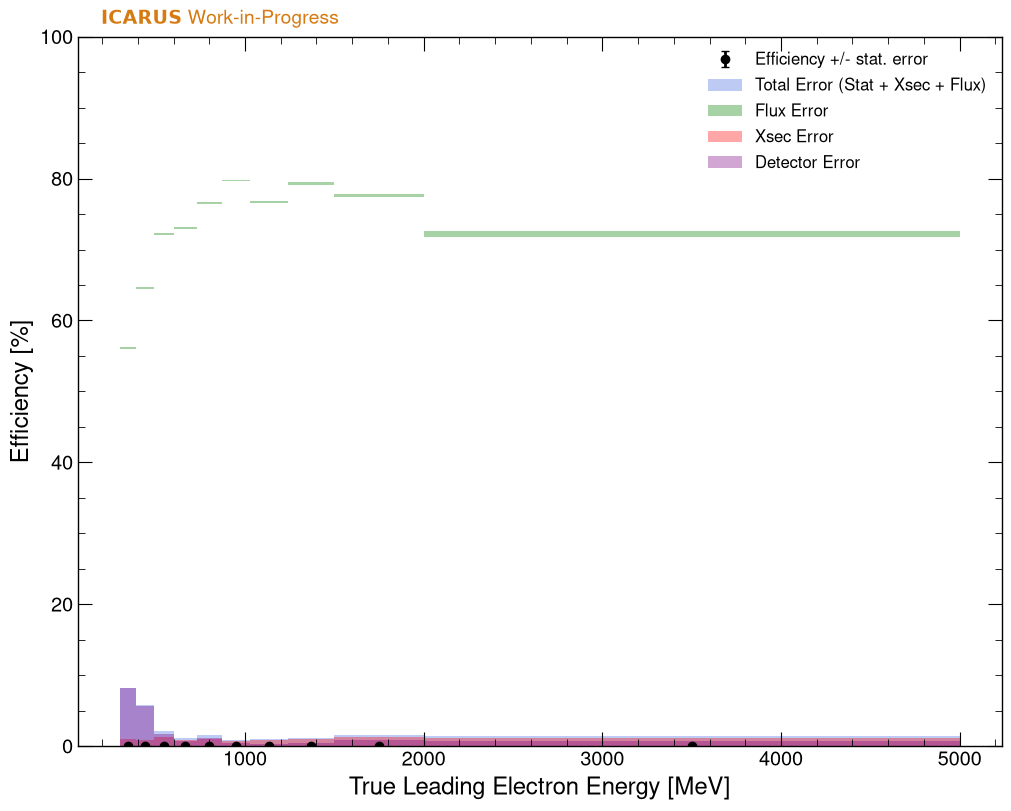

In [68]:
info = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots_sept15/efficiency_error_total_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl')

errorbar_x, errorbar_y, errorbar_yerr, bar_x, bar_y, bar_values, bar_widths = info

# Create figure with style applied BEFORE plotting
fig, ax, style = make_styled_plot("basic_icarus", figsize=(10, 8))

# If extracted yerr is all zeros, fall back to existing yerr variable.
yerr_to_plot = errorbar_yerr
if np.allclose(yerr_to_plot, 0) and 'yerr' in globals():
    yerr_to_plot = np.asarray(yerr, dtype=float)

print(yerr_to_plot)

# Overlay error bars on the same axes.
ax.errorbar(
    errorbar_x, errorbar_y,
    yerr=yerr_to_plot,
    fmt='o',
    color='black',
    capsize=3,
    label='Efficiency +/- stat. error'
)

# Re-draw bars using extracted bin centers and widths.
baseline = [y - err/2 for y, err in zip(errorbar_y, bar_values)]
ax.bar(
    bar_x, bar_values,
    width=bar_widths,
    align='center',
    color='royalblue',
    alpha=0.35,
    label='Total Error (Stat + Xsec + Flux)',
    bottom=baseline
)

info = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots_sept15/efficiency_error_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl')

errorbar_x, errorbar_y, errorbar_yerr, bar_x, bar_y, bar_values, bar_widths = info

baseline = [y - err/2 for y, err in zip(errorbar_y, bar_values)]
ax.bar(
    bar_x, bar_values,
    width=bar_widths,
    align='center',
    color='green',
    alpha=0.35,
    label='Flux Error',
    bottom=baseline
)

info = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots_sept15/efficiency_error_xsec_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl')

errorbar_x, errorbar_y, errorbar_yerr, bar_x, bar_y, bar_values, bar_widths = info

baseline = [y - err/2 for y, err in zip(errorbar_y, bar_values)]
ax.bar(
    bar_x, bar_values,
    width=bar_widths,
    align='center',
    color='red',
    alpha=0.35,
    label='Xsec Error',
    bottom=baseline
)

info = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots_sept15/efficiency_error_detector_trueTree/efficiency_vs_trueLeadingElectronEnergy.pkl')

errorbar_x, errorbar_y, errorbar_yerr, bar_x, bar_y, bar_values, bar_widths = info

baseline = [y - err/2 for y, err in zip(errorbar_y, bar_values)]
ax.bar(
    bar_x, bar_values,
    width=bar_widths,
    align='center',
    color='purple',
    alpha=0.35,
    label='Detector Error',
    bottom=baseline
)

ax.set_xlabel('True Leading Electron Energy [MeV]')
ax.set_ylabel('Efficiency [%]')
ax.legend()
ax.set_ylim(0, 100)
plt.show()

In [32]:
def get_total_histogram_from_stacked(pkl_file):
    """Extract total histogram from stacked bar containers in a pickled figure."""
    with open(pkl_file, 'rb') as f:
        fig_temp = pickle.load(f)
    
    ax_temp = fig_temp.axes[0]
    
    # Extract bar positions and sum all heights
    if len(ax_temp.containers) > 0:
        bin_lefts = None
        bin_widths = None
        total_heights = None
        
        for cont in ax_temp.containers:
            lefts = np.array([rect.get_x() for rect in cont])
            widths = np.array([rect.get_width() for rect in cont])
            heights = np.array([rect.get_height() for rect in cont], dtype=float)
            
            if bin_lefts is None:
                bin_lefts = lefts
                bin_widths = widths
                total_heights = heights.copy()
            else:
                # Align if needed and sum
                if len(heights) == len(total_heights):
                    total_heights += heights
                else:
                    # Pad shorter array with zeros
                    if len(heights) < len(total_heights):
                        heights = np.pad(heights, (0, len(total_heights) - len(heights)), constant_values=0.0)
                    else:
                        total_heights = np.pad(total_heights, (0, len(heights) - len(total_heights)), constant_values=0.0)
                    total_heights += heights
        
        # Create bin edges from left edges and widths
        bin_edges = np.append(bin_lefts, bin_lefts[-1] + bin_widths[-1])
        
        plt.close(fig_temp)
        return bin_edges, total_heights
    else:
        plt.close(fig_temp)
        raise RuntimeError("No stacked bar containers found in the plot")

# Extract total counts histogram
edges_total, heights_total = get_total_histogram_from_stacked("/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type_trueSignal/plot_true_leading_electron_energy.pkl")
edges_sel, heights_sel = get_total_histogram_from_stacked("/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_leading_electron_energy.pkl")

# Create a new figure with dual y-axes
fig_combined = plt.figure(figsize=(14, 10))
ax1 = fig_combined.add_subplot(111)

# Extract all three error components from pkl files
info_total = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_with_error/efficiency_vs_trueLeadingElectronEnergy_total.pkl')
errorbar_x_t, errorbar_y_t, errorbar_yerr_t, bar_x_t, bar_y_t, bar_values_t, bar_widths_t = info_total

info_flux = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_with_error/efficiency_vs_trueLeadingElectronEnergy_flux.pkl')
errorbar_x_f, errorbar_y_f, errorbar_yerr_f, bar_x_f, bar_y_f, bar_values_f, bar_widths_f = info_flux

info_xsec = extract_info('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_with_error/efficiency_vs_trueLeadingElectronEnergy_xsec.pkl')
errorbar_x_x, errorbar_y_x, errorbar_yerr_x, bar_x_x, bar_y_x, bar_values_x, bar_widths_x = info_xsec

# Left y-axis: Efficiency with all three error components
ax1.errorbar(errorbar_x_t, errorbar_y_t, yerr=errorbar_yerr_t, fmt='o', 
             color='black', capsize=3, label='Efficiency +/- stat. error')

baseline_t = [y - err/2 for y, err in zip(errorbar_y_t, bar_values_t)]
ax1.bar(bar_x_t, bar_values_t, width=bar_widths_t, align='center',
        color='royalblue', alpha=0.35, label='Total Error (Stat + Xsec + Flux)', bottom=baseline_t)

baseline_f = [y - err/2 for y, err in zip(errorbar_y_f, bar_values_f)]
ax1.bar(bar_x_f, bar_values_f, width=bar_widths_f, align='center',
        color='green', alpha=0.35, label='Flux Error', bottom=baseline_f)

baseline_x = [y - err/2 for y, err in zip(errorbar_y_x, bar_values_x)]
ax1.bar(bar_x_x, bar_values_x, width=bar_widths_x, align='center',
        color='red', alpha=0.35, label='Xsec Error', bottom=baseline_x)

ax1.set_xlabel('True Leading Electron Energy [MeV]', fontsize=12)
ax1.set_ylabel('Efficiency [%]', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 100)

# Right y-axis: Total Counts (step histogram)
ax2 = ax1.twinx()
color_counts = 'tab:red'
ax2.set_ylabel('Total Counts', color=color_counts, fontsize=12)
ax2.stairs(heights_total, edges_total, fill=False, edgecolor=color_counts, linewidth=2.5, 
           label='Total Signal Events', baseline=0)
ax2.stairs(heights_sel, edges_sel, fill=False, edgecolor='tab:blue', linewidth=2.5, 
           label='Selected Signal Events', baseline=0)
ax2.tick_params(axis='y', labelcolor=color_counts)
ax2.set_ylim(0, 2400)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, ncols=2)

fig_combined.tight_layout()
plt.show()

print(f"Total counts: {np.sum(heights_total)}")

/tmp/ipykernel_212655/3456782863.py:81: UserWarning: This figure was saved with matplotlib version 3.9.4 and loaded with 3.11.1 so may not function correctly.
  _orig_fig_ss(self, state)


AttributeError: 'Line2D' object has no attribute 'get_x'

Error in callback <function _draw_all_if_interactive at 0x7f860247c0f0> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'Axes' object has no attribute '_axis_map'

AttributeError: 'Axes' object has no attribute '_axis_map'

<Figure size 1000x800 with 1 Axes>

## Fix systematics vs variable plots to look nice

In [44]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import io
import pickle
from IPython.display import Image, display
from pathlib import Path

# Compatibility: older matplotlib stored bound references to this method in pickles
import matplotlib.figure as _mpl_figure
if not hasattr(_mpl_figure.Figure, '_remove_suplabel'):
    _mpl_figure.Figure._remove_suplabel = lambda self, *args, **kwargs: None

class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith('numpy._core'):
            module = module.replace('numpy._core', 'numpy.core', 1)
        return super().find_class(module, name)


def recolor_pickled_figure(pkl_file, legend_loc='upper center', legend_ncol=4, anchor=(0.6, 0.75), ylim=None, legend_text_size=10, figsize=None):
    custom_colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
        '#3182bd', '#31a354', '#756bb1', '#636363', '#e6550d',
        '#969696', '#6baed6', '#74c476', '#9e9ac8', '#fd8d3c',
        '#bdbdbd', '#9ecae1', '#a1d99b', '#bcbddc', '#fdae6b',
        '#c6dbef', '#c7e9c0', '#dadaeb', '#fdd0a2', '#f0f0f0',
        '#08519c', '#006d2c', '#54278f', '#a50f15', '#225ea8',
        '#238b45', '#6a51a3', '#cb181d', '#4292c6', '#41ab5d',
        '#807dba', '#ef3b2c', '#6baed6', '#74c476', '#9e9ac8',
    ]

    if len(custom_colors) != 50:
        raise ValueError(f'Expected 50 custom colors, got {len(custom_colors)}')

    cmap = ListedColormap(custom_colors)

    def pick_color(index):
        return cmap((index % 50) / 49.0)

    # with open(pkl_file, 'rb') as f:
    #     fig = pickle.load(f)
    with open(pkl_file, 'rb') as f:
        fig = _CompatUnpickler(f).load()

    # Close immediately so IPython's inline backend doesn't try to display it
    plt.close(fig)
    # Attach a fresh Agg canvas so savefig uses the local renderer, not a stale one
    from matplotlib.backends.backend_agg import FigureCanvasAgg
    FigureCanvasAgg(fig)
    if figsize is not None:
        fig.set_size_inches(figsize)
        fig.set_layout_engine(None)  # disable constrained layout so tight_layout can work

    integrals = {}  # label -> mean fractional uncertainty (%)

    for ax in fig.axes:
        idx = 0

        total_lines = len(ax.get_lines())
        for line in ax.get_lines():
            color = pick_color(idx)
            idx += 1
            if idx == total_lines:
                color = 'black'
            line.set_color(color)
            line.set_markeredgecolor(color)
            if line.get_marker() not in [None, '', 'None', ' ']:
                line.set_markerfacecolor(color)

        total_patches = len(ax.patches)
        for patch in ax.patches:
            color = pick_color(idx)
            idx += 1
            if idx == total_patches:
                color = 'black'
            if hasattr(patch, 'set_edgecolor'):
                patch.set_edgecolor(color)
            if hasattr(patch, 'set_facecolor'):
                patch.set_facecolor(color)

            # Collect integral for StepPatch systematics
            if isinstance(patch, mpatches.StepPatch):
                label = patch.get_label()
                if not label.startswith('_') and label != 'Total':
                    try:
                        d = patch.get_data()
                        vals = np.asarray(d.values, dtype=float)
                        edges = np.asarray(d.edges, dtype=float)
                        widths = np.diff(edges)
                        total_width = edges[-1] - edges[0]
                        mean_unc = np.sum(np.abs(vals) * widths) / total_width * 100
                        integrals[label] = mean_unc
                    except Exception:
                        pass

        total_collections = len(ax.collections)
        for coll in ax.collections:
            color = pick_color(idx)
            idx += 1
            if idx == total_collections:
                color = 'black'
            if hasattr(coll, 'set_color'):
                coll.set_color(color)
            if hasattr(coll, 'set_edgecolor'):
                coll.set_edgecolor(color)
            if hasattr(coll, 'set_facecolor'):
                coll.set_facecolor(color)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            old_legend = ax.get_legend()
            if old_legend is not None:
                old_legend.remove()
            ax.legend(handles, labels, ncol=legend_ncol, frameon=True, loc=legend_loc, bbox_to_anchor=anchor, fontsize=legend_text_size)

        if ylim is not None:
            ax.set_ylim(ylim)

    if figsize is not None:
        try:
            fig.tight_layout()
        except Exception:
            pass
    plt.rcParams.update({"text.usetex": False})
    png_buffer = io.BytesIO()
    bbox = None if figsize is not None else 'tight'
    fig.savefig(png_buffer, format='png', bbox_inches=bbox, dpi=140)
    plt.close(fig)
    png_buffer.seek(0)
    display(Image(data=png_buffer.getvalue()))
    png_buffer.close()


    if integrals:
        total = np.sqrt(sum(v**2 for v in integrals.values()))
        print("Systematics ranked by average fractional uncertainty (smallest → largest):")
        for label, val in sorted(integrals.items(), key=lambda x: x[1]):
            print(f"  {val:6.3f}%  {label}")
        print(f"Total (quadrature sum): {total:6.3f}%")


/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


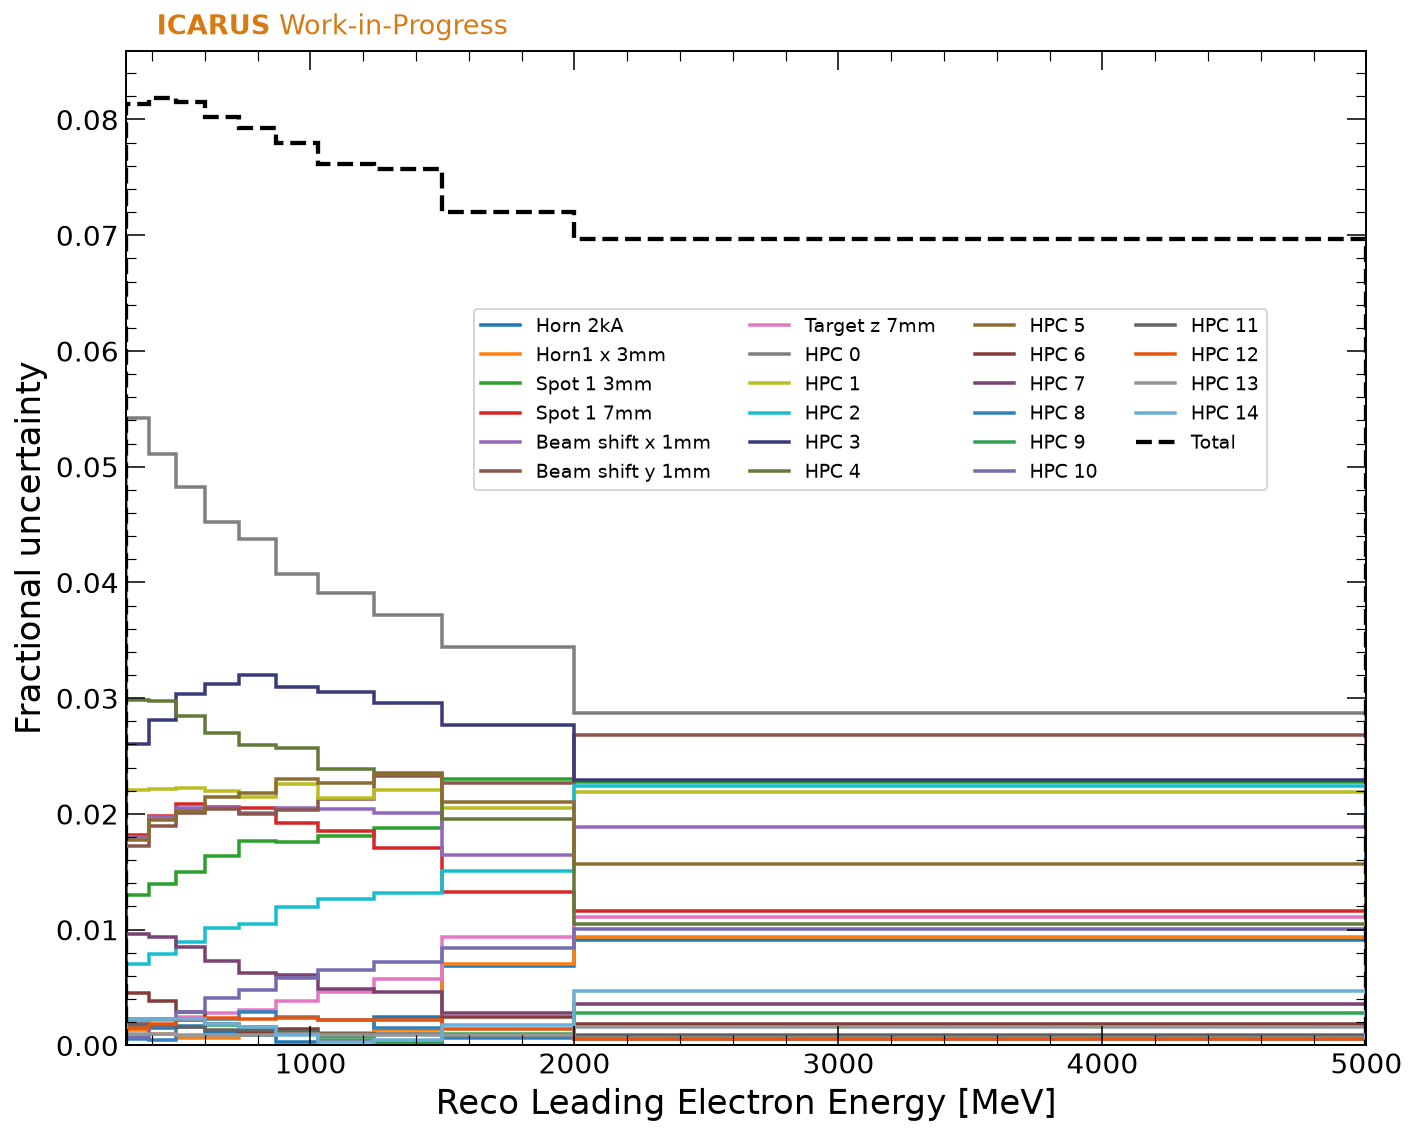

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.091%  HPC 8
   0.098%  HPC 11
   0.106%  HPC 12
   0.134%  HPC 13
   0.182%  HPC 6
   0.221%  HPC 9
   0.351%  HPC 14
   0.423%  HPC 7
   0.689%  Horn 2kA
   0.698%  Horn1 x 3mm
   0.854%  HPC 10
   0.905%  Target z 7mm
   1.365%  Spot 1 7mm
   1.540%  HPC 4
   1.781%  HPC 5
   1.869%  HPC 2
   1.891%  Beam shift x 1mm
   2.130%  Spot 1 3mm
   2.177%  HPC 1
   2.482%  Beam shift y 1mm
   2.527%  HPC 3
   3.296%  HPC 0
Total (quadrature sum):  7.079%


In [45]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux/plot_sys_eleE.pkl',
    legend_loc='upper center',
    legend_ncol=4,
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


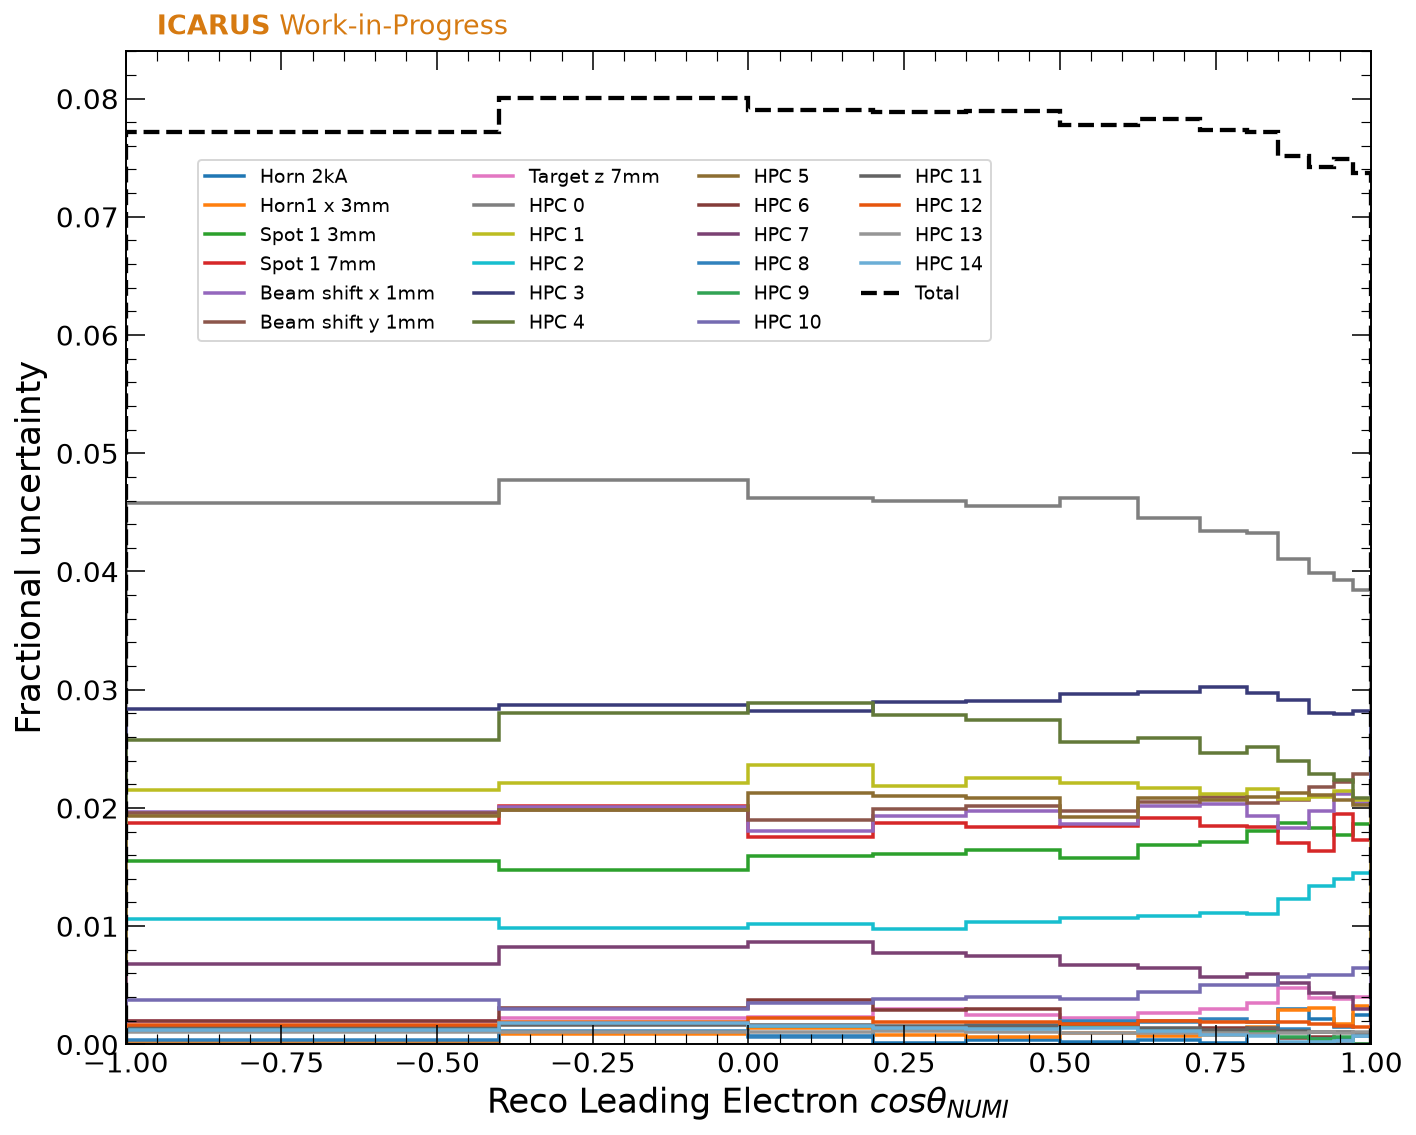

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.078%  Horn 2kA
   0.087%  Horn1 x 3mm
   0.102%  HPC 8
   0.103%  HPC 13
   0.129%  HPC 14
   0.139%  HPC 9
   0.150%  HPC 11
   0.181%  HPC 12
   0.236%  HPC 6
   0.246%  Target z 7mm
   0.389%  HPC 10
   0.712%  HPC 7
   1.057%  HPC 2
   1.594%  Spot 1 3mm
   1.876%  Spot 1 7mm
   1.956%  Beam shift x 1mm
   1.994%  Beam shift y 1mm
   2.013%  HPC 5
   2.193%  HPC 1
   2.652%  HPC 4
   2.878%  HPC 3
   4.559%  HPC 0
Total (quadrature sum):  7.800%


In [14]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux/plot_sys_eleCosThetaNUMI.pkl',
    legend_loc='upper left',
    legend_ncol=4,
    anchor=(0.05, 0.9)
)

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


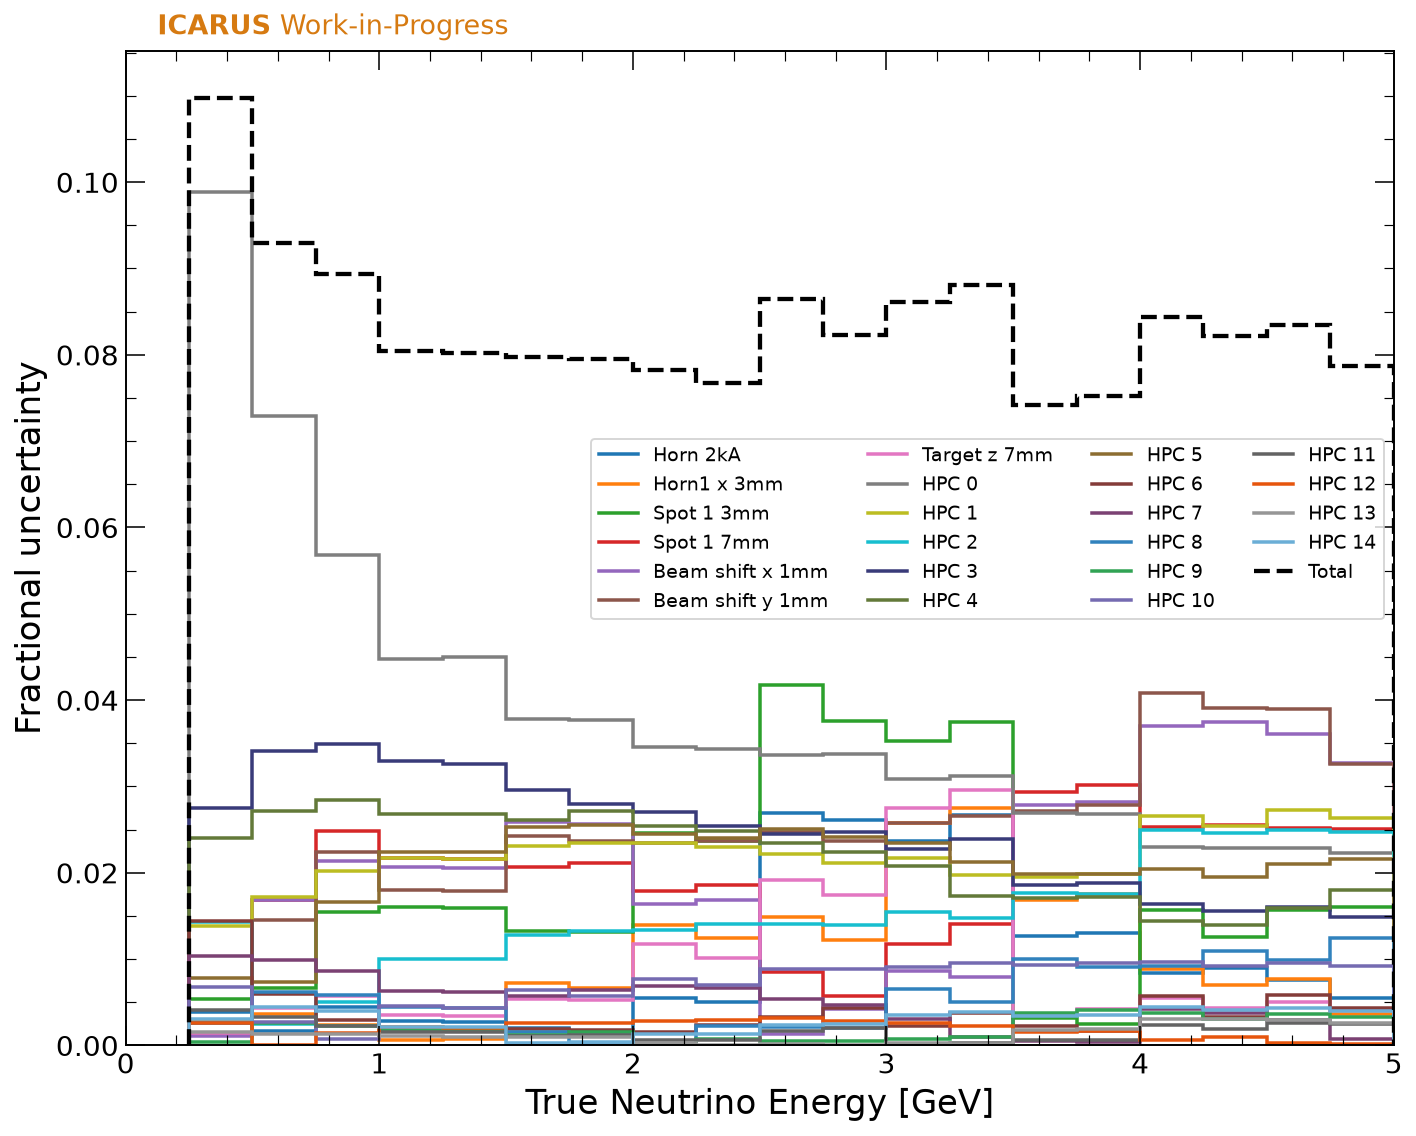

Systematics ranked by average fractional uncertainty (smallest → largest):
     nan%  Horn 2kA
     nan%  Horn1 x 3mm
     nan%  Spot 1 3mm
     nan%  Spot 1 7mm
     nan%  Beam shift x 1mm
     nan%  Beam shift y 1mm
     nan%  Target z 7mm
     nan%  HPC 0
     nan%  HPC 1
     nan%  HPC 2
     nan%  HPC 3
     nan%  HPC 4
     nan%  HPC 5
     nan%  HPC 6
     nan%  HPC 7
     nan%  HPC 8
     nan%  HPC 9
     nan%  HPC 10
     nan%  HPC 11
     nan%  HPC 12
     nan%  HPC 13
     nan%  HPC 14
Total (quadrature sum):    nan%


In [17]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux/plot_sys_nuE.pkl',
    legend_loc='upper right',
    legend_ncol=4,
    anchor=(1.0, 0.62)
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


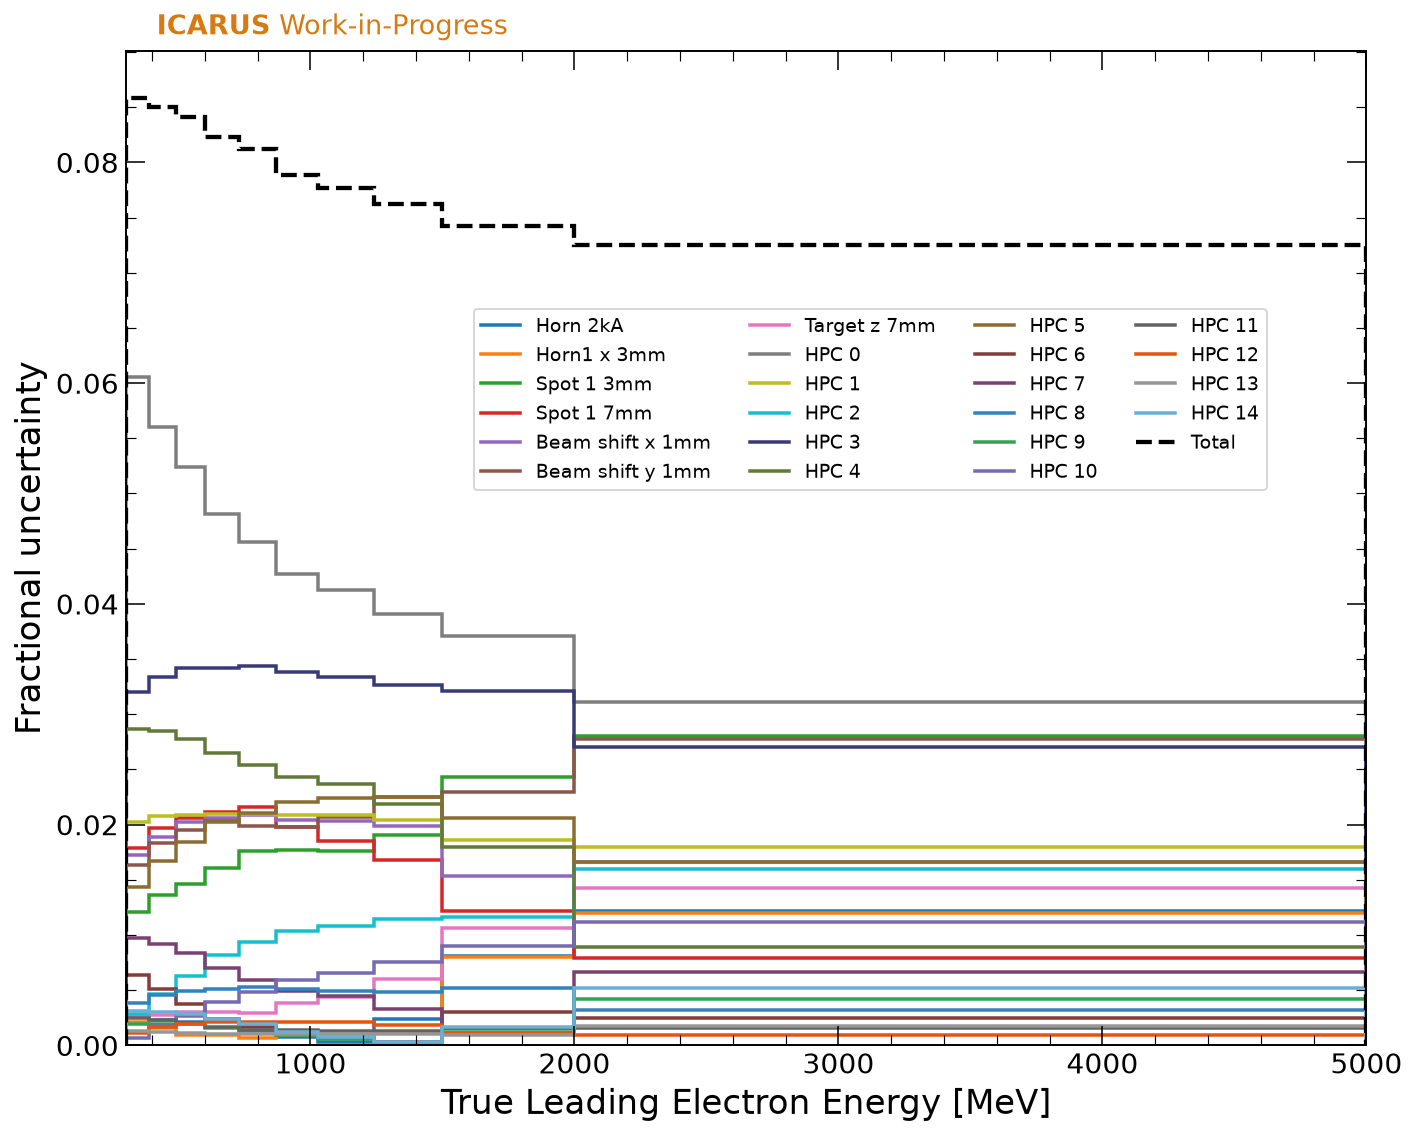

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.121%  HPC 12
   0.149%  HPC 13
   0.160%  HPC 11
   0.240%  HPC 6
   0.311%  HPC 9
   0.385%  HPC 8
   0.388%  HPC 14
   0.584%  HPC 7
   0.880%  Horn1 x 3mm
   0.906%  Horn 2kA
   0.936%  HPC 10
   1.126%  Target z 7mm
   1.127%  Spot 1 7mm
   1.373%  HPC 2
   1.399%  HPC 4
   1.732%  Beam shift x 1mm
   1.804%  HPC 5
   1.876%  HPC 1
   2.473%  Spot 1 3mm
   2.533%  Beam shift y 1mm
   2.920%  HPC 3
   3.552%  HPC 0
Total (quadrature sum):  7.291%


In [18]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux/plot_sys_trueEleE.pkl',
    legend_loc='upper center',
    legend_ncol=4,
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


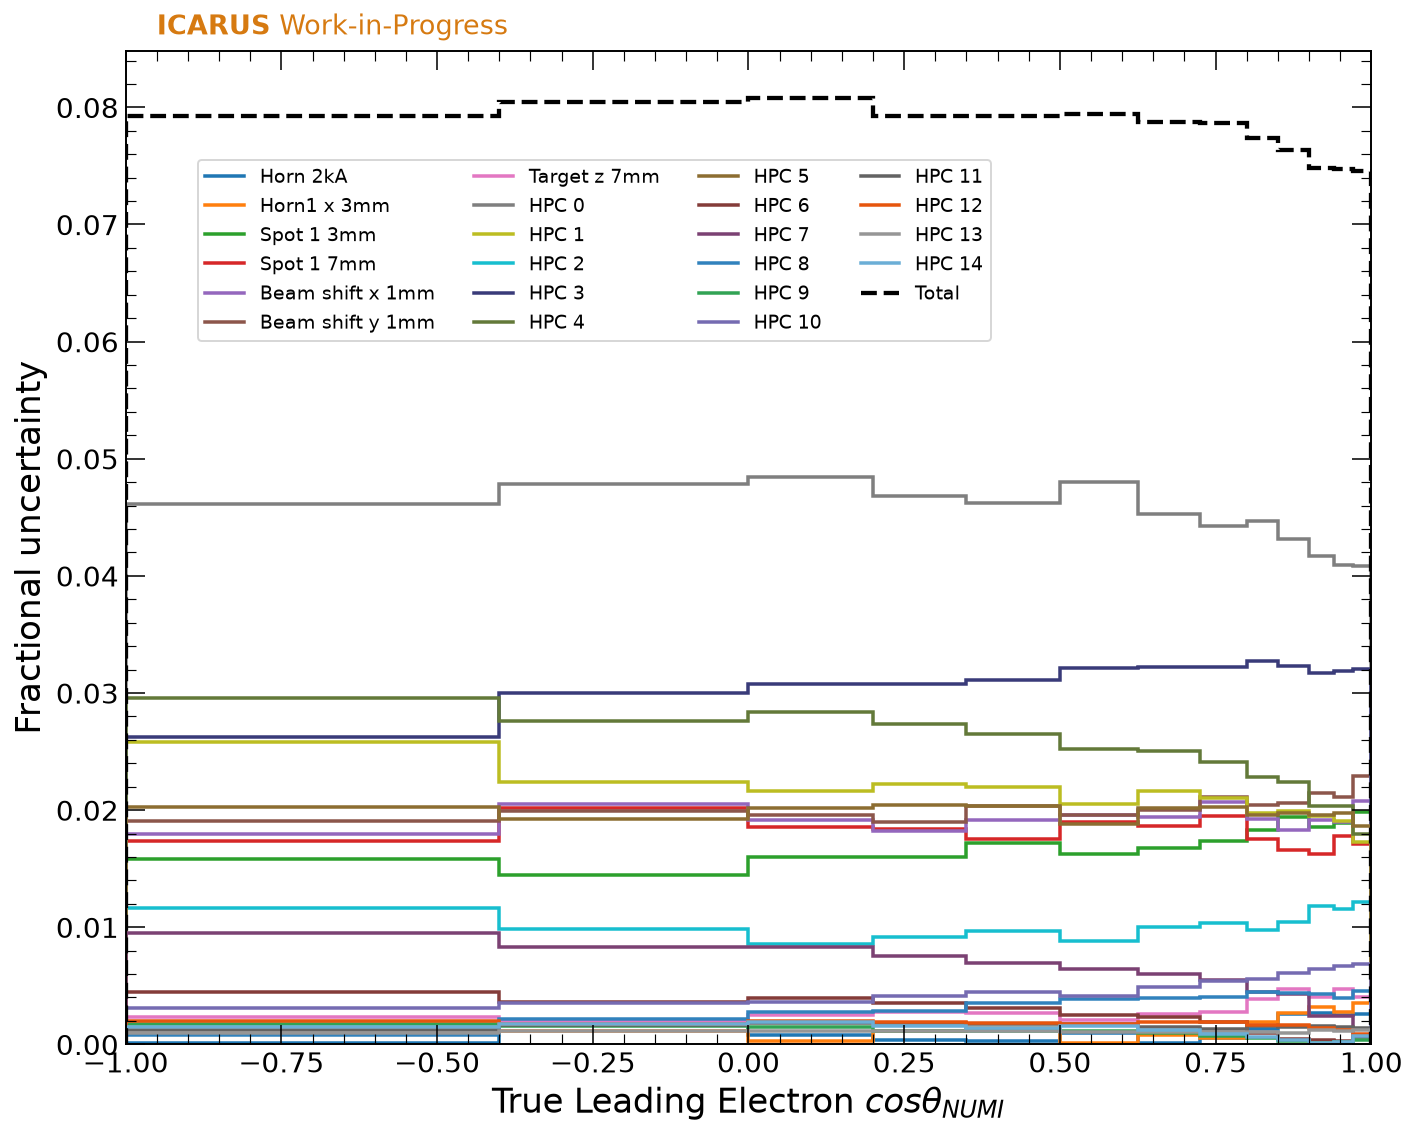

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.089%  Horn 2kA
   0.107%  HPC 13
   0.121%  Horn1 x 3mm
   0.133%  HPC 9
   0.142%  HPC 14
   0.153%  HPC 11
   0.185%  HPC 12
   0.244%  HPC 8
   0.254%  Target z 7mm
   0.335%  HPC 6
   0.398%  HPC 10
   0.765%  HPC 7
   1.025%  HPC 2
   1.613%  Spot 1 3mm
   1.836%  Spot 1 7mm
   1.909%  Beam shift x 1mm
   1.976%  Beam shift y 1mm
   1.990%  HPC 5
   2.279%  HPC 1
   2.709%  HPC 4
   2.963%  HPC 3
   4.643%  HPC 0
Total (quadrature sum):  7.906%


In [19]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_flux/plot_sys_trueEleCosThetaNUMI.pkl',
    legend_loc='upper left',
    legend_ncol=4,
    anchor=(0.05, 0.9)
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


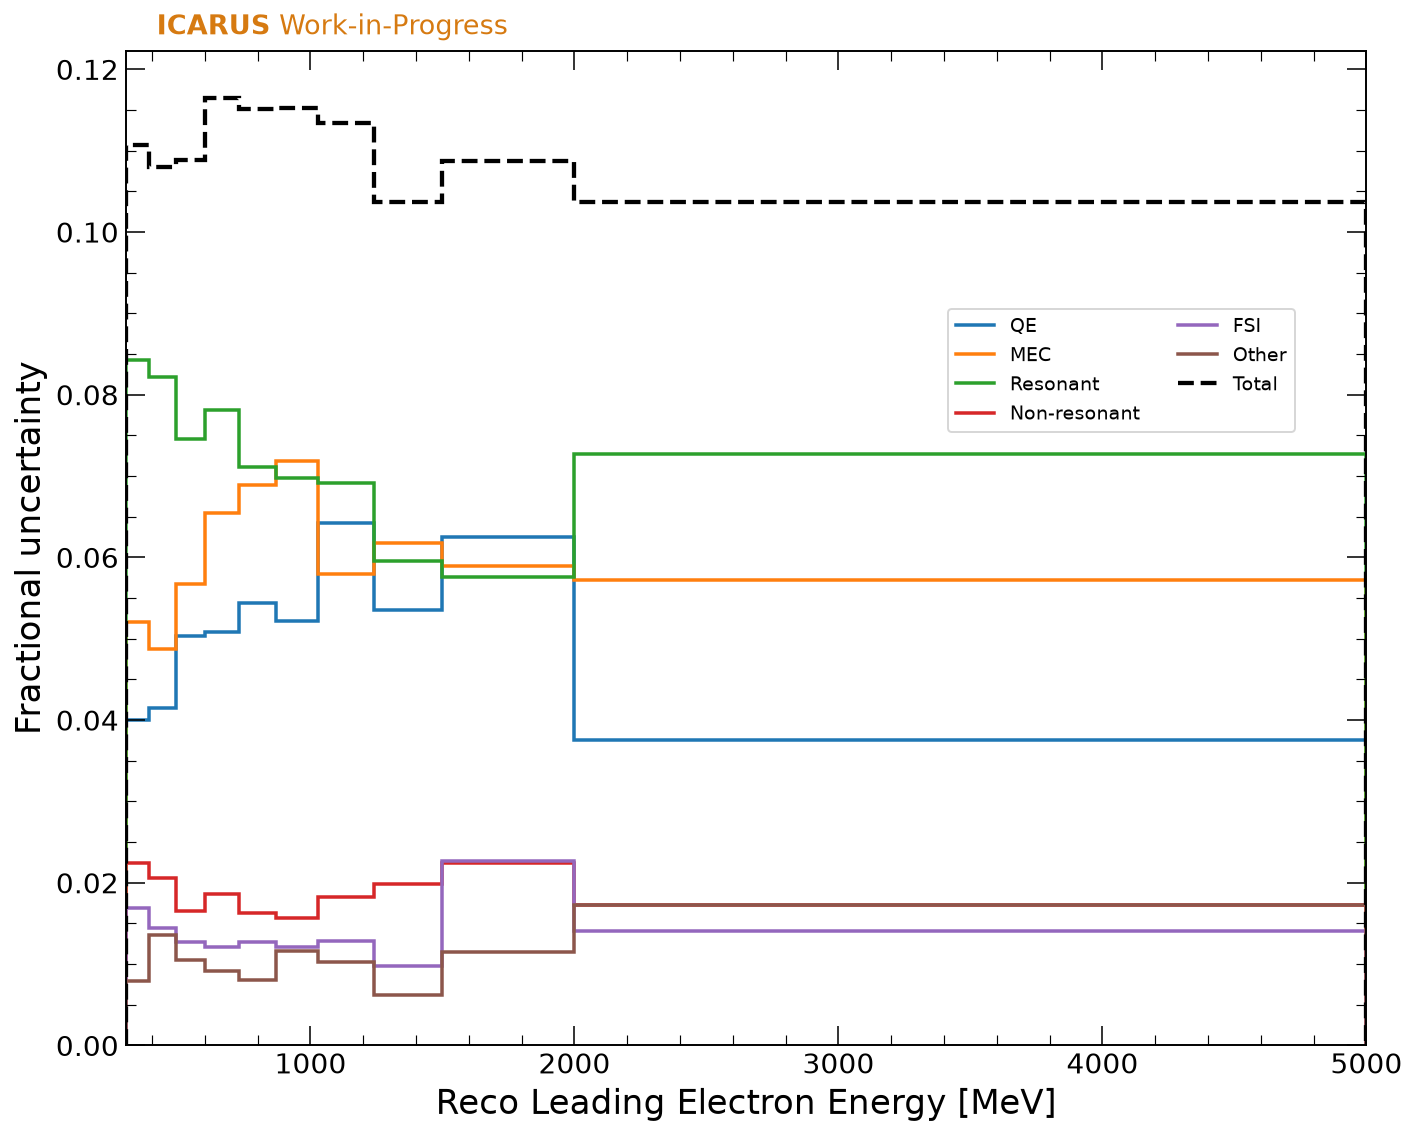

Systematics ranked by average fractional uncertainty (smallest → largest):
   1.458%  FSI
   1.458%  Other
   1.810%  Non-resonant
   4.405%  QE
   5.845%  MEC
   7.067%  Resonant
Total (quadrature sum): 10.537%


In [20]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec/plot_sys_eleE.pkl',
    legend_loc='upper right',
    legend_ncol=2,
    anchor=(0.95, 0.75)
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


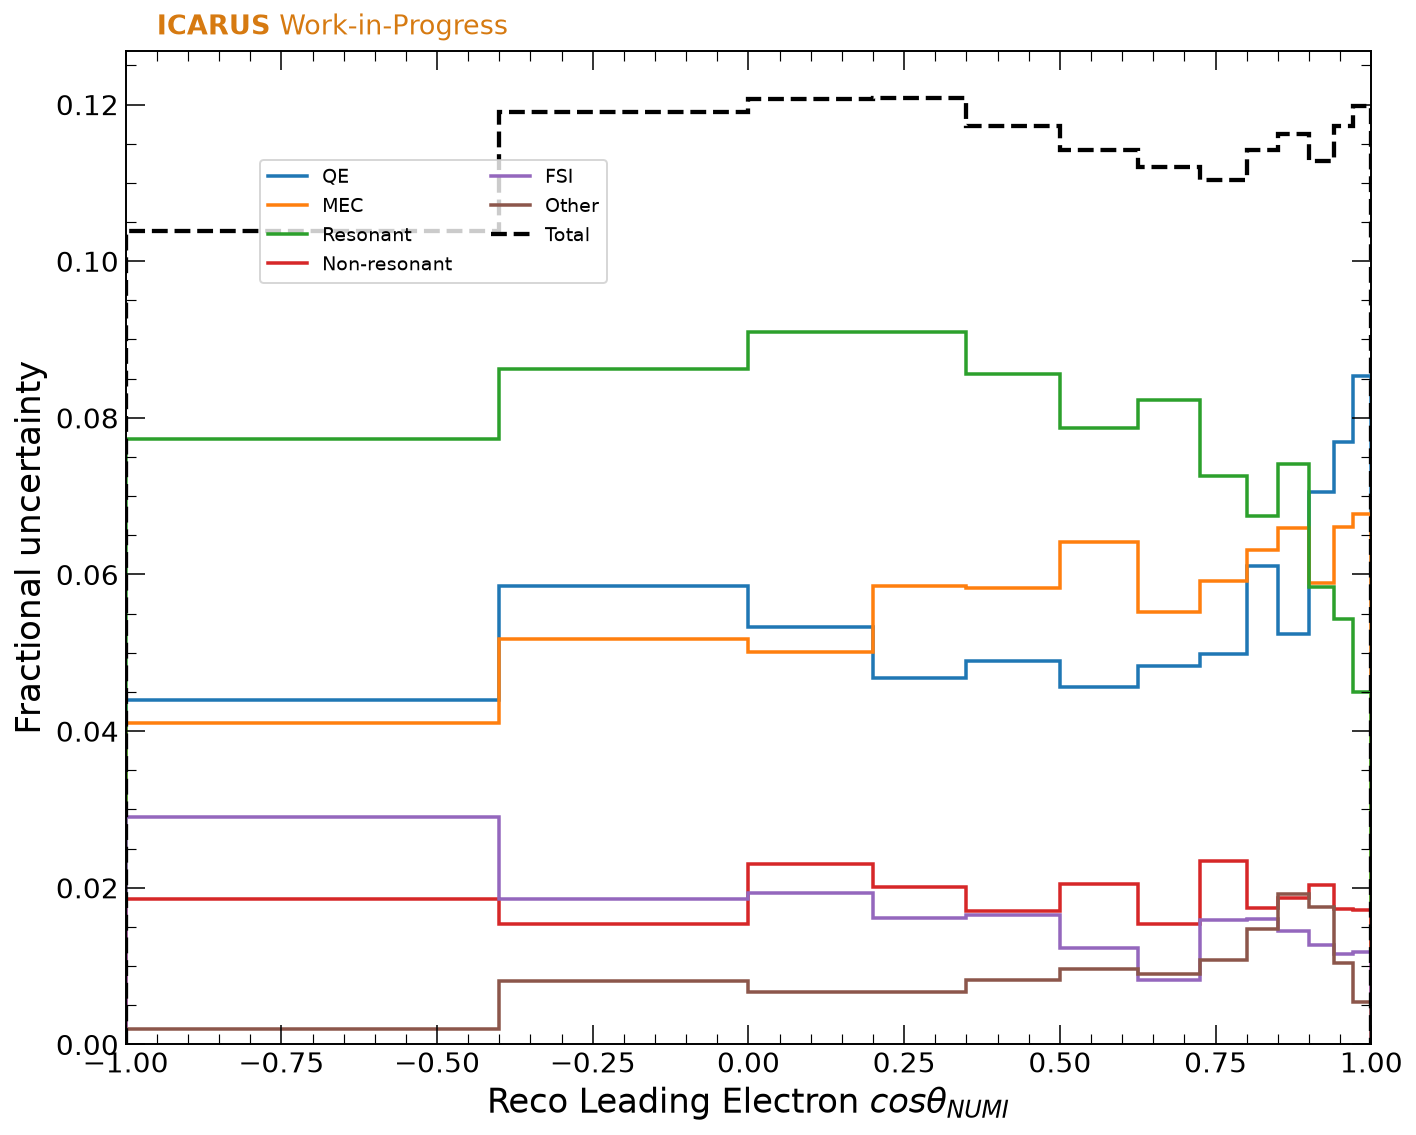

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.686%  Other
   1.845%  Non-resonant
   1.992%  FSI
   5.122%  QE
   5.181%  MEC
   8.073%  Resonant
Total (quadrature sum): 11.229%


In [21]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec/plot_sys_eleCosThetaNUMI.pkl',
    legend_loc='upper left',
    legend_ncol=2,
    anchor=(0.1, 0.9)
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


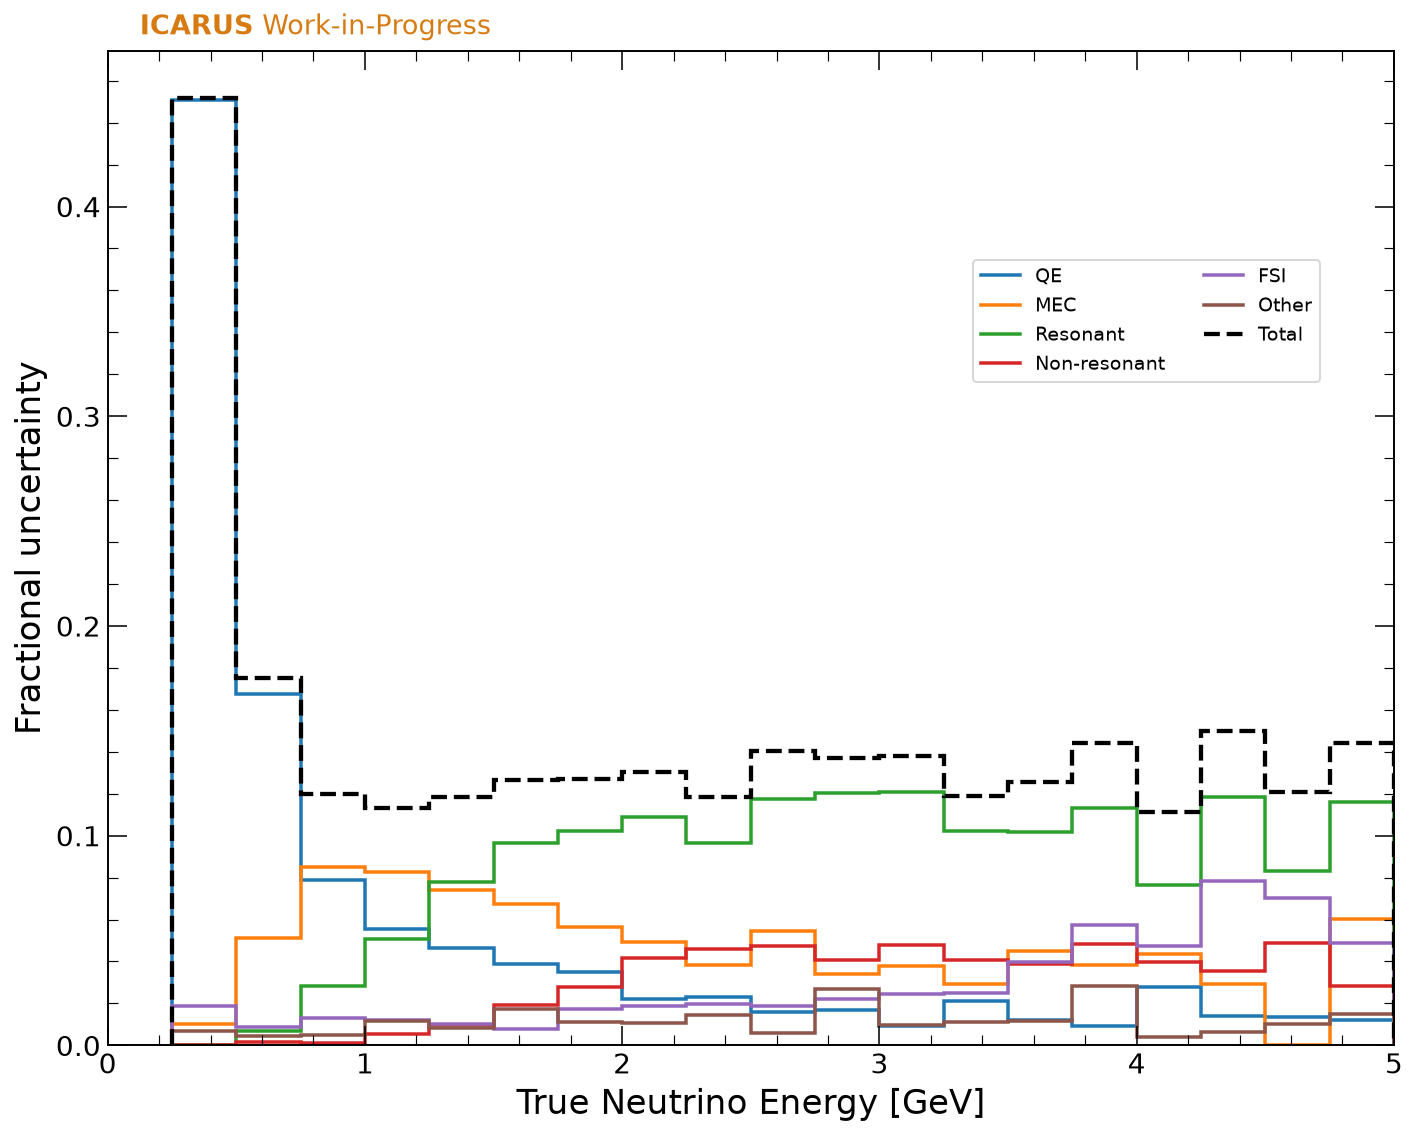

Systematics ranked by average fractional uncertainty (smallest → largest):
     nan%  QE
     nan%  MEC
     nan%  Resonant
     nan%  Non-resonant
     nan%  FSI
     nan%  Other
Total (quadrature sum):    nan%


In [23]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec/plot_sys_nuE.pkl',
    legend_loc='upper right',
    legend_ncol=2,
    anchor=(0.95, 0.8)
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


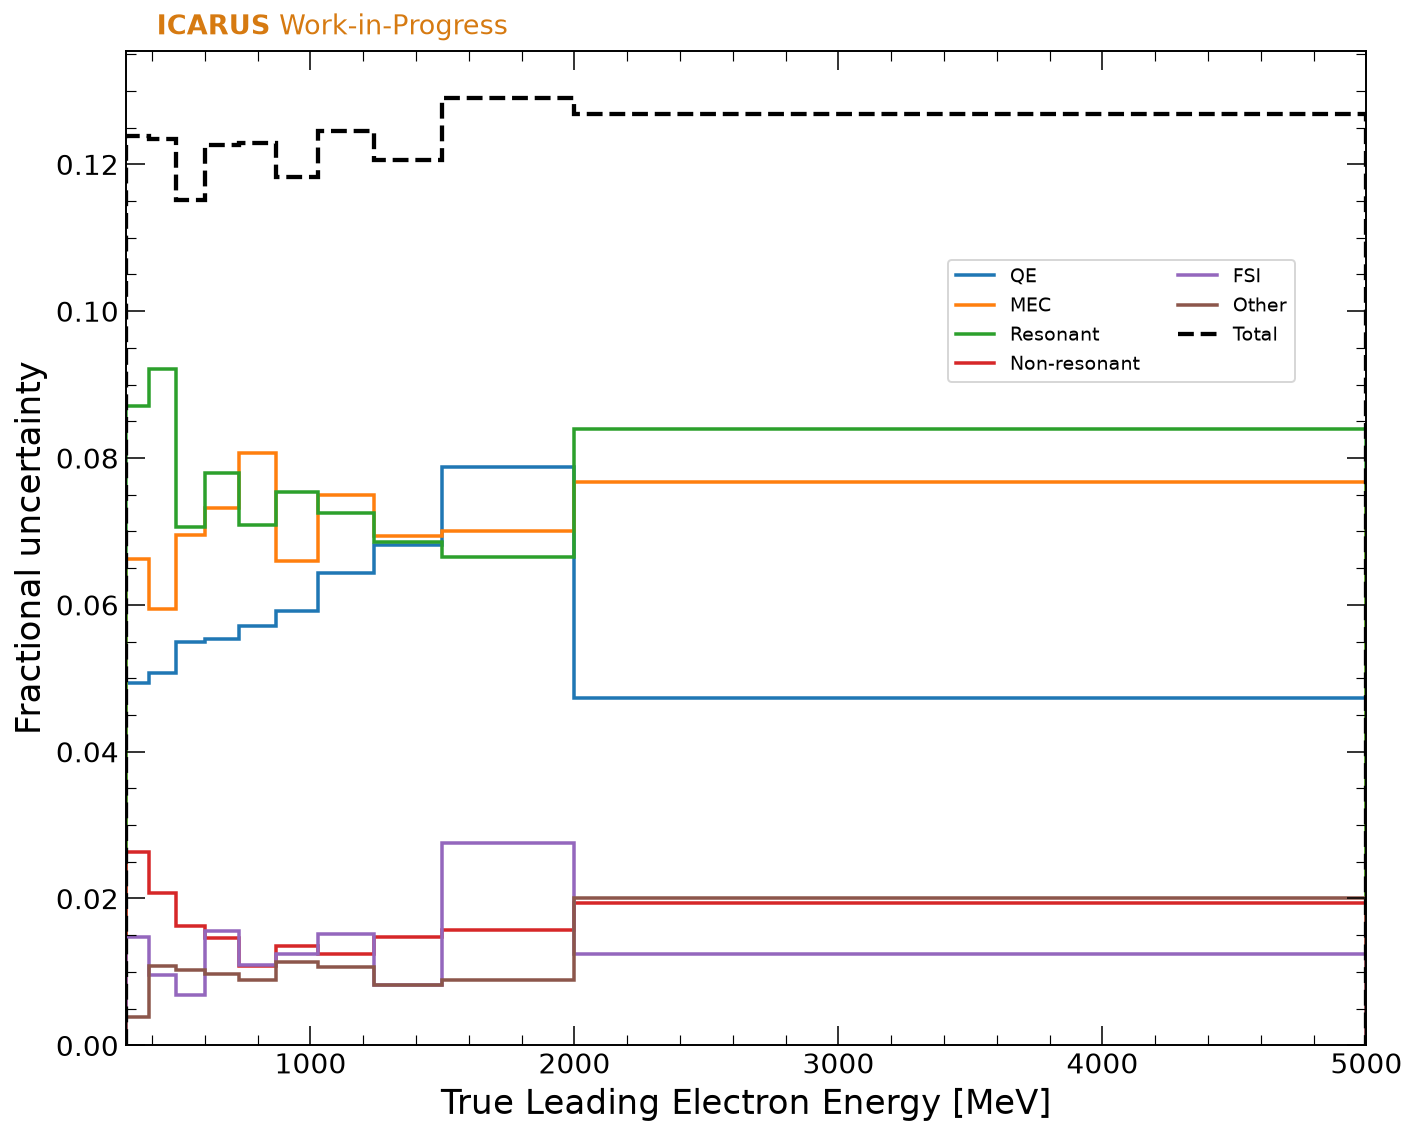

Systematics ranked by average fractional uncertainty (smallest → largest):
   1.383%  FSI
   1.617%  Other
   1.791%  Non-resonant
   5.376%  QE
   7.441%  MEC
   7.978%  Resonant
Total (quadrature sum): 12.476%


In [24]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec/plot_sys_trueEleE.pkl',
    legend_loc='upper right',
    legend_ncol=2,
    anchor=(0.95, 0.8)
 )

/tmp/ipykernel_212655/1769279695.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


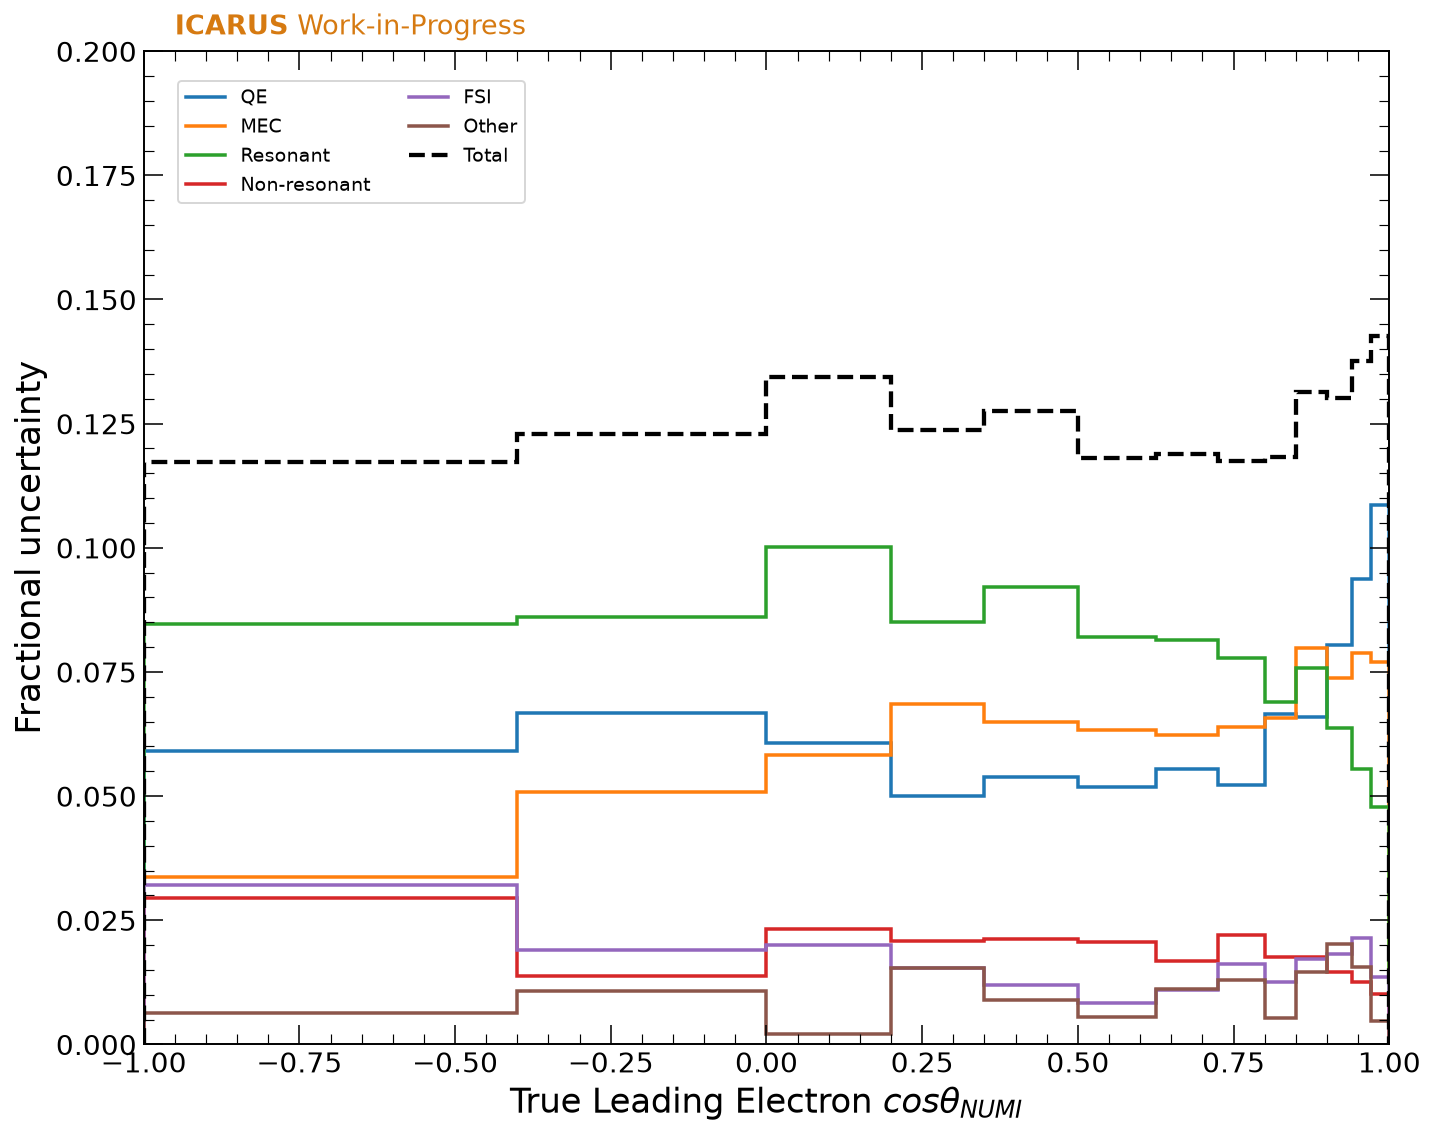

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.869%  Other
   2.077%  FSI
   2.154%  Non-resonant
   5.306%  MEC
   6.087%  QE
   8.446%  Resonant
Total (quadrature sum): 12.093%


In [25]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec/plot_sys_trueEleCosThetaNUMI.pkl',
    legend_loc='upper left',
    legend_ncol=2,
    anchor=(0.02, 0.98),
    ylim=(0, 0.20)
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


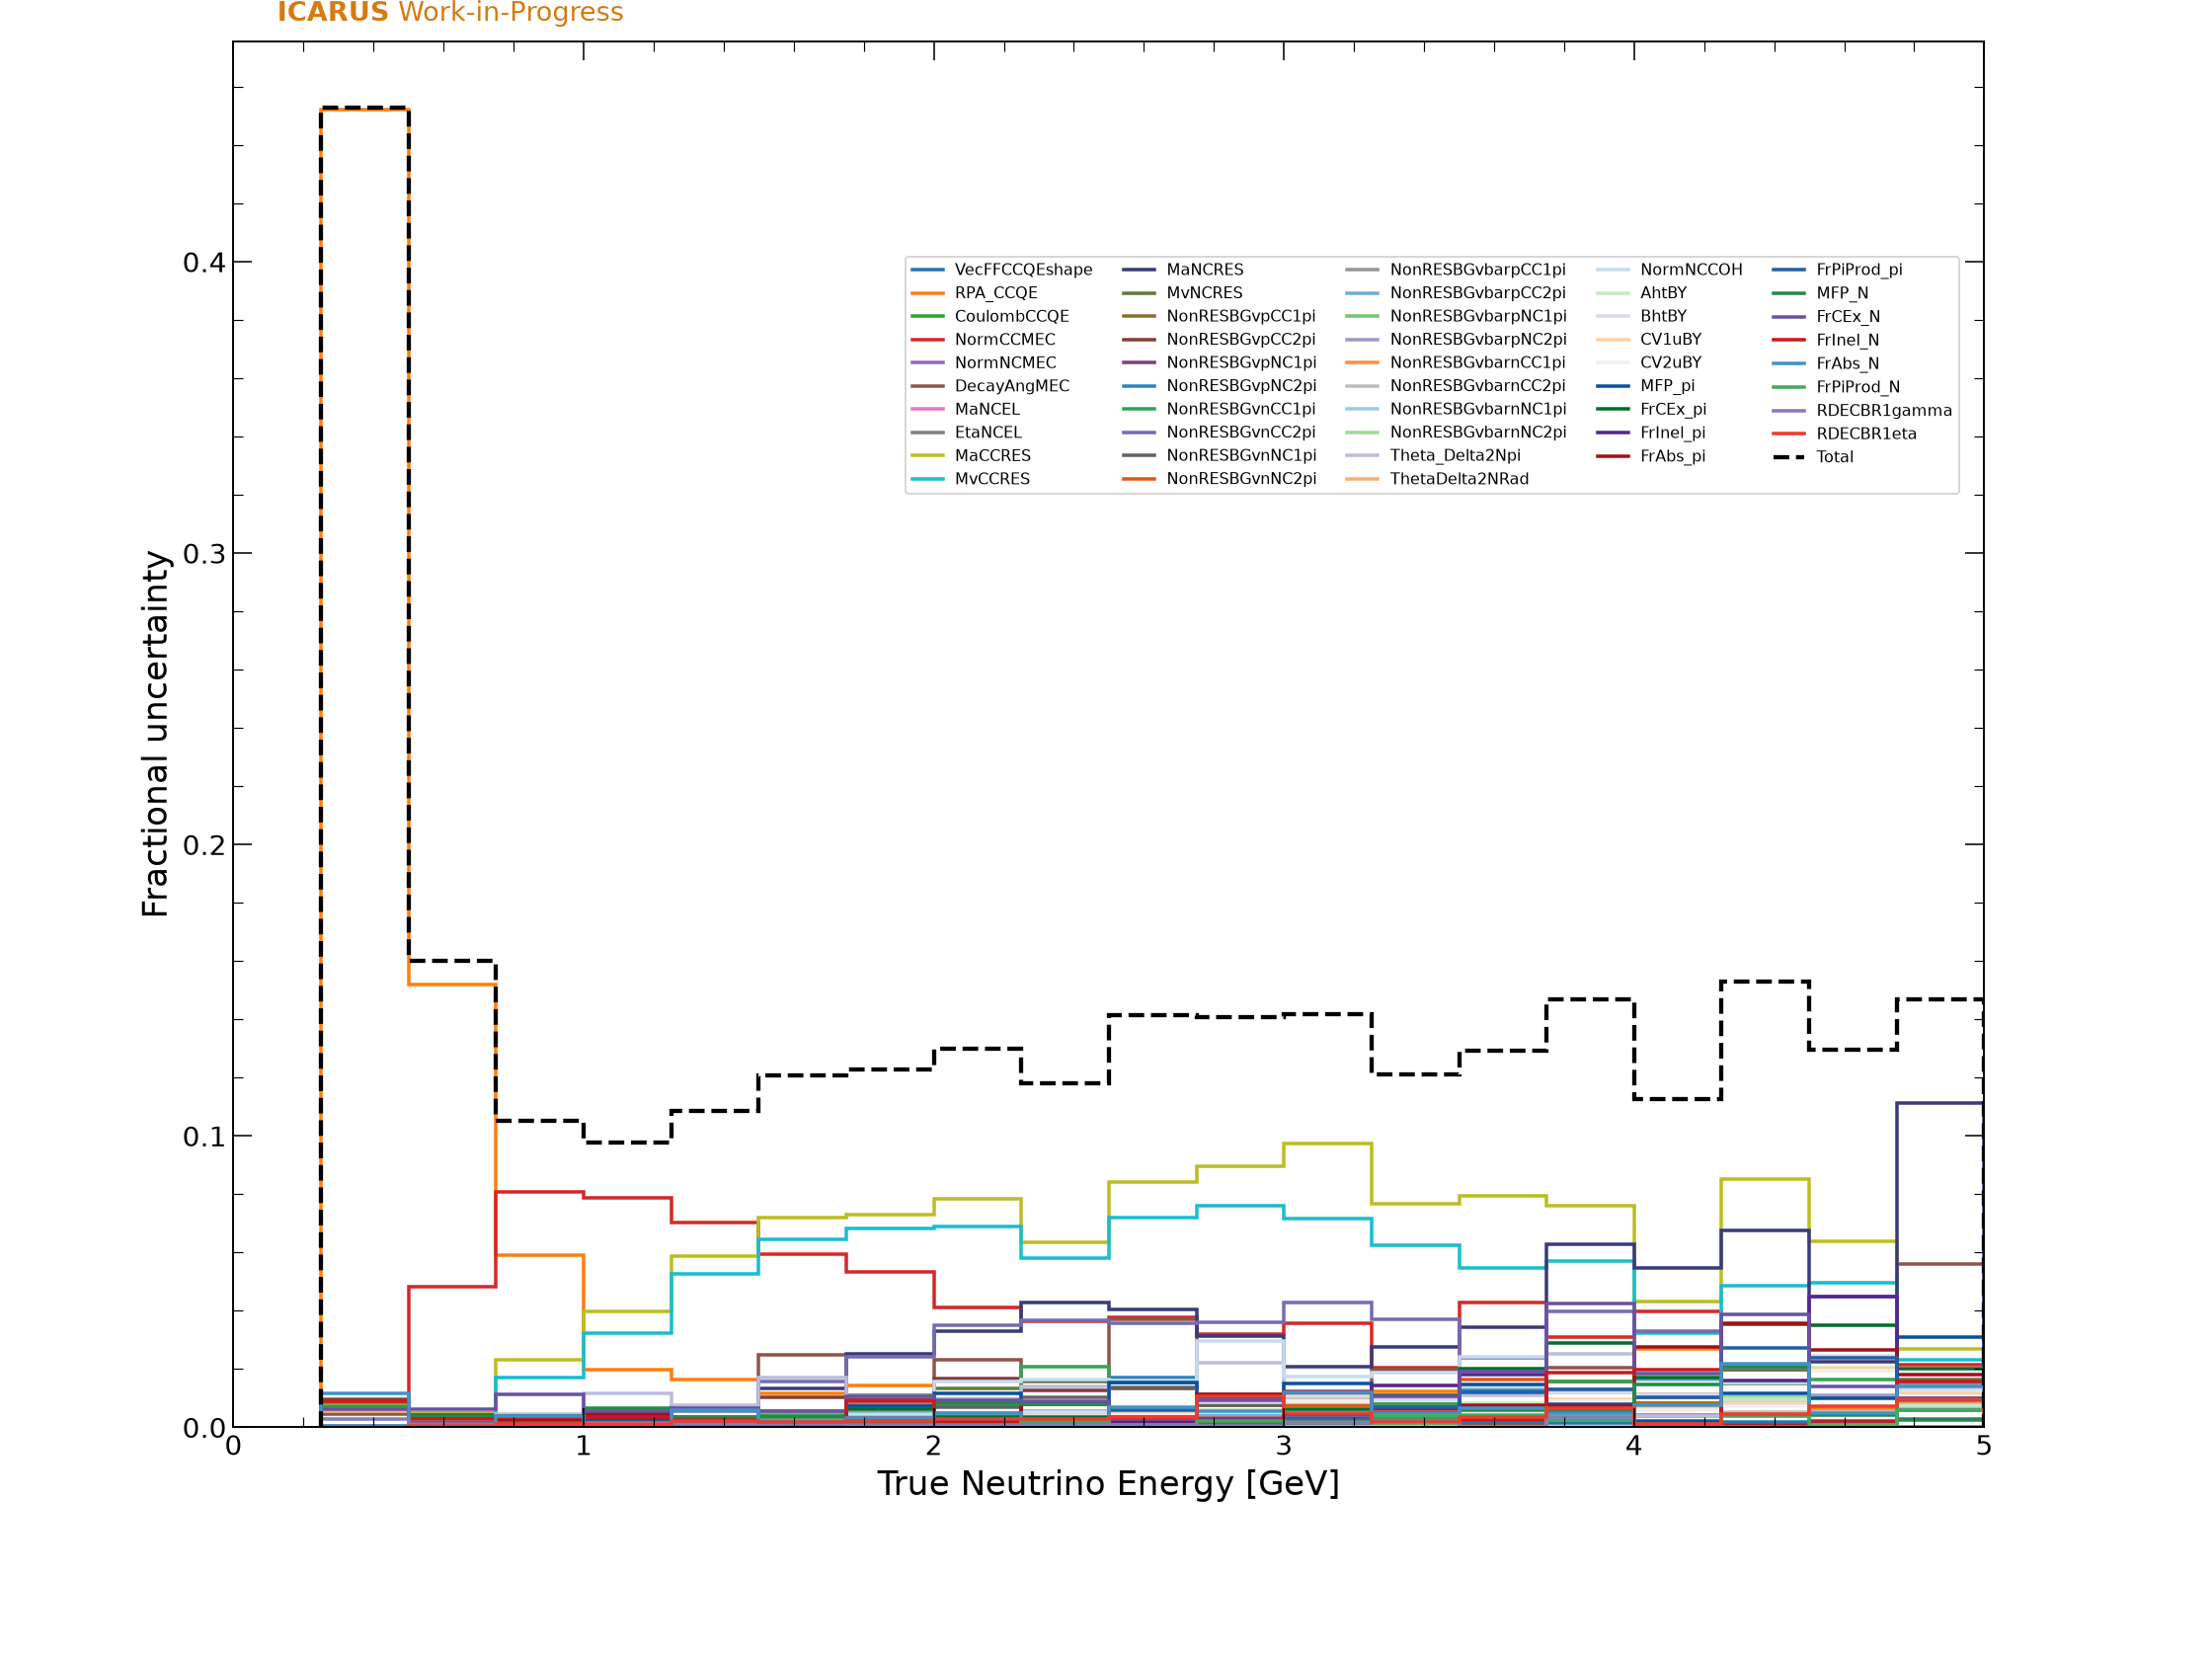

Systematics ranked by average fractional uncertainty (smallest → largest):
     nan%  VecFFCCQEshape
     nan%  RPA_CCQE
     nan%  CoulombCCQE
     nan%  NormCCMEC
     nan%  NormNCMEC
     nan%  DecayAngMEC
     nan%  MaNCEL
     nan%  EtaNCEL
     nan%  MaCCRES
     nan%  MvCCRES
     nan%  MaNCRES
     nan%  MvNCRES
     nan%  NonRESBGvpCC1pi
     nan%  NonRESBGvpCC2pi
     nan%  NonRESBGvpNC1pi
     nan%  NonRESBGvpNC2pi
     nan%  NonRESBGvnCC1pi
     nan%  NonRESBGvnCC2pi
     nan%  NonRESBGvnNC1pi
     nan%  NonRESBGvnNC2pi
     nan%  NonRESBGvbarpCC1pi
     nan%  NonRESBGvbarpCC2pi
     nan%  NonRESBGvbarpNC1pi
     nan%  NonRESBGvbarpNC2pi
     nan%  NonRESBGvbarnCC1pi
     nan%  NonRESBGvbarnCC2pi
     nan%  NonRESBGvbarnNC1pi
     nan%  NonRESBGvbarnNC2pi
     nan%  Theta_Delta2Npi
     nan%  ThetaDelta2NRad
     nan%  NormNCCOH
     nan%  AhtBY
     nan%  BhtBY
     nan%  CV1uBY
     nan%  CV2uBY
     nan%  MFP_pi
     nan%  FrCEx_pi
     nan%  FrInel_pi
     nan%  FrAbs_p

In [47]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec_all/plot_sys_nuE.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.99, 0.85),
    legend_text_size=8,
    figsize=(16, 12),
)

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


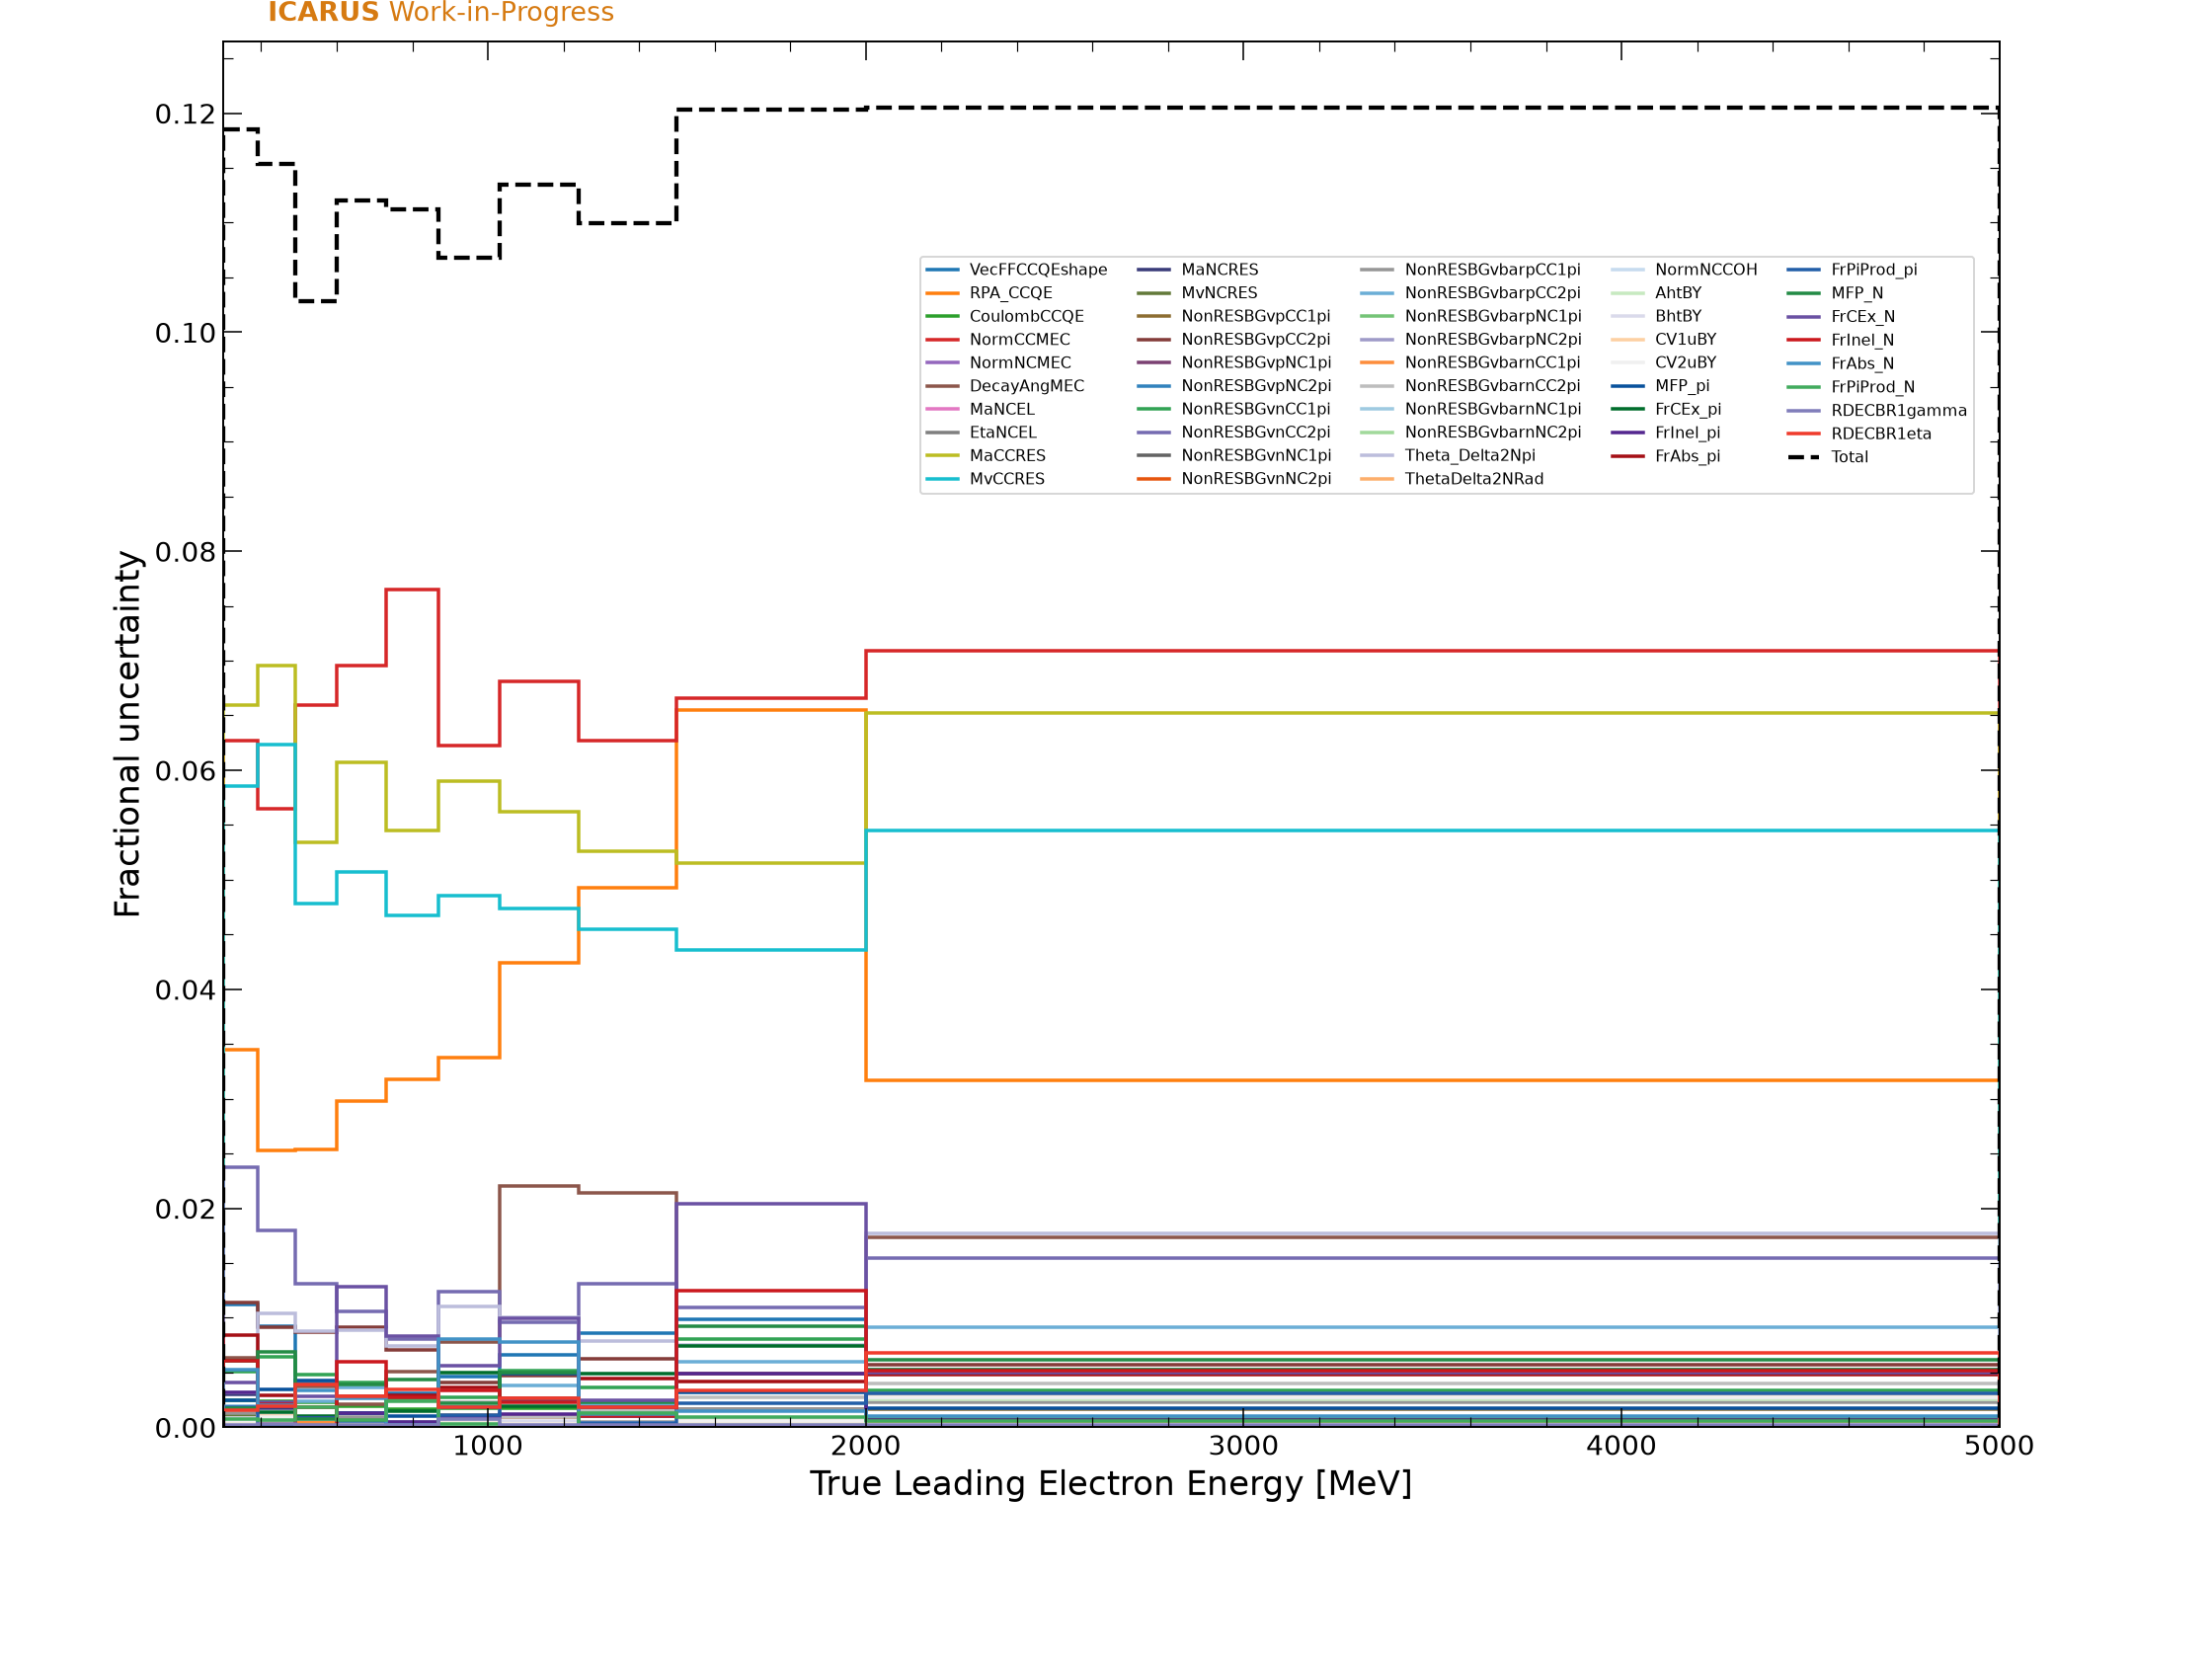

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.000%  NormNCMEC
   0.000%  MaNCEL
   0.000%  EtaNCEL
   0.000%  NonRESBGvnNC1pi
   0.000%  NonRESBGvbarpNC1pi
   0.000%  NonRESBGvbarpNC2pi
   0.000%  NonRESBGvbarnNC1pi
   0.000%  NonRESBGvbarnNC2pi
   0.000%  NormNCCOH
   0.002%  NonRESBGvpNC1pi
   0.002%  NonRESBGvpNC2pi
   0.002%  NonRESBGvnNC2pi
   0.004%  MvNCRES
   0.004%  ThetaDelta2NRad
   0.011%  MaNCRES
   0.024%  RDECBR1gamma
   0.048%  NonRESBGvbarnCC1pi
   0.073%  FrPiProd_N
   0.114%  CoulombCCQE
   0.119%  NonRESBGvpCC1pi
   0.128%  FrInel_pi
   0.179%  FrAbs_N
   0.183%  AhtBY
   0.183%  NonRESBGvbarpCC1pi
   0.191%  CV2uBY
   0.197%  CV1uBY
   0.200%  BhtBY
   0.207%  MFP_pi
   0.243%  FrPiProd_pi
   0.313%  NonRESBGvbarnCC2pi
   0.406%  NonRESBGvnCC1pi
   0.446%  FrAbs_pi
   0.499%  FrCEx_pi
   0.529%  RDECBR1eta
   0.532%  FrInel_N
   0.573%  VecFFCCQEshape
   0.576%  MFP_N
   0.591%  NonRESBGvpCC2pi
   0.693%  FrCEx_N
   0.694%  NonRESB

In [49]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec_all/plot_sys_trueEleE.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.99, 0.85),
    legend_text_size=8,
    figsize=(16, 12)
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


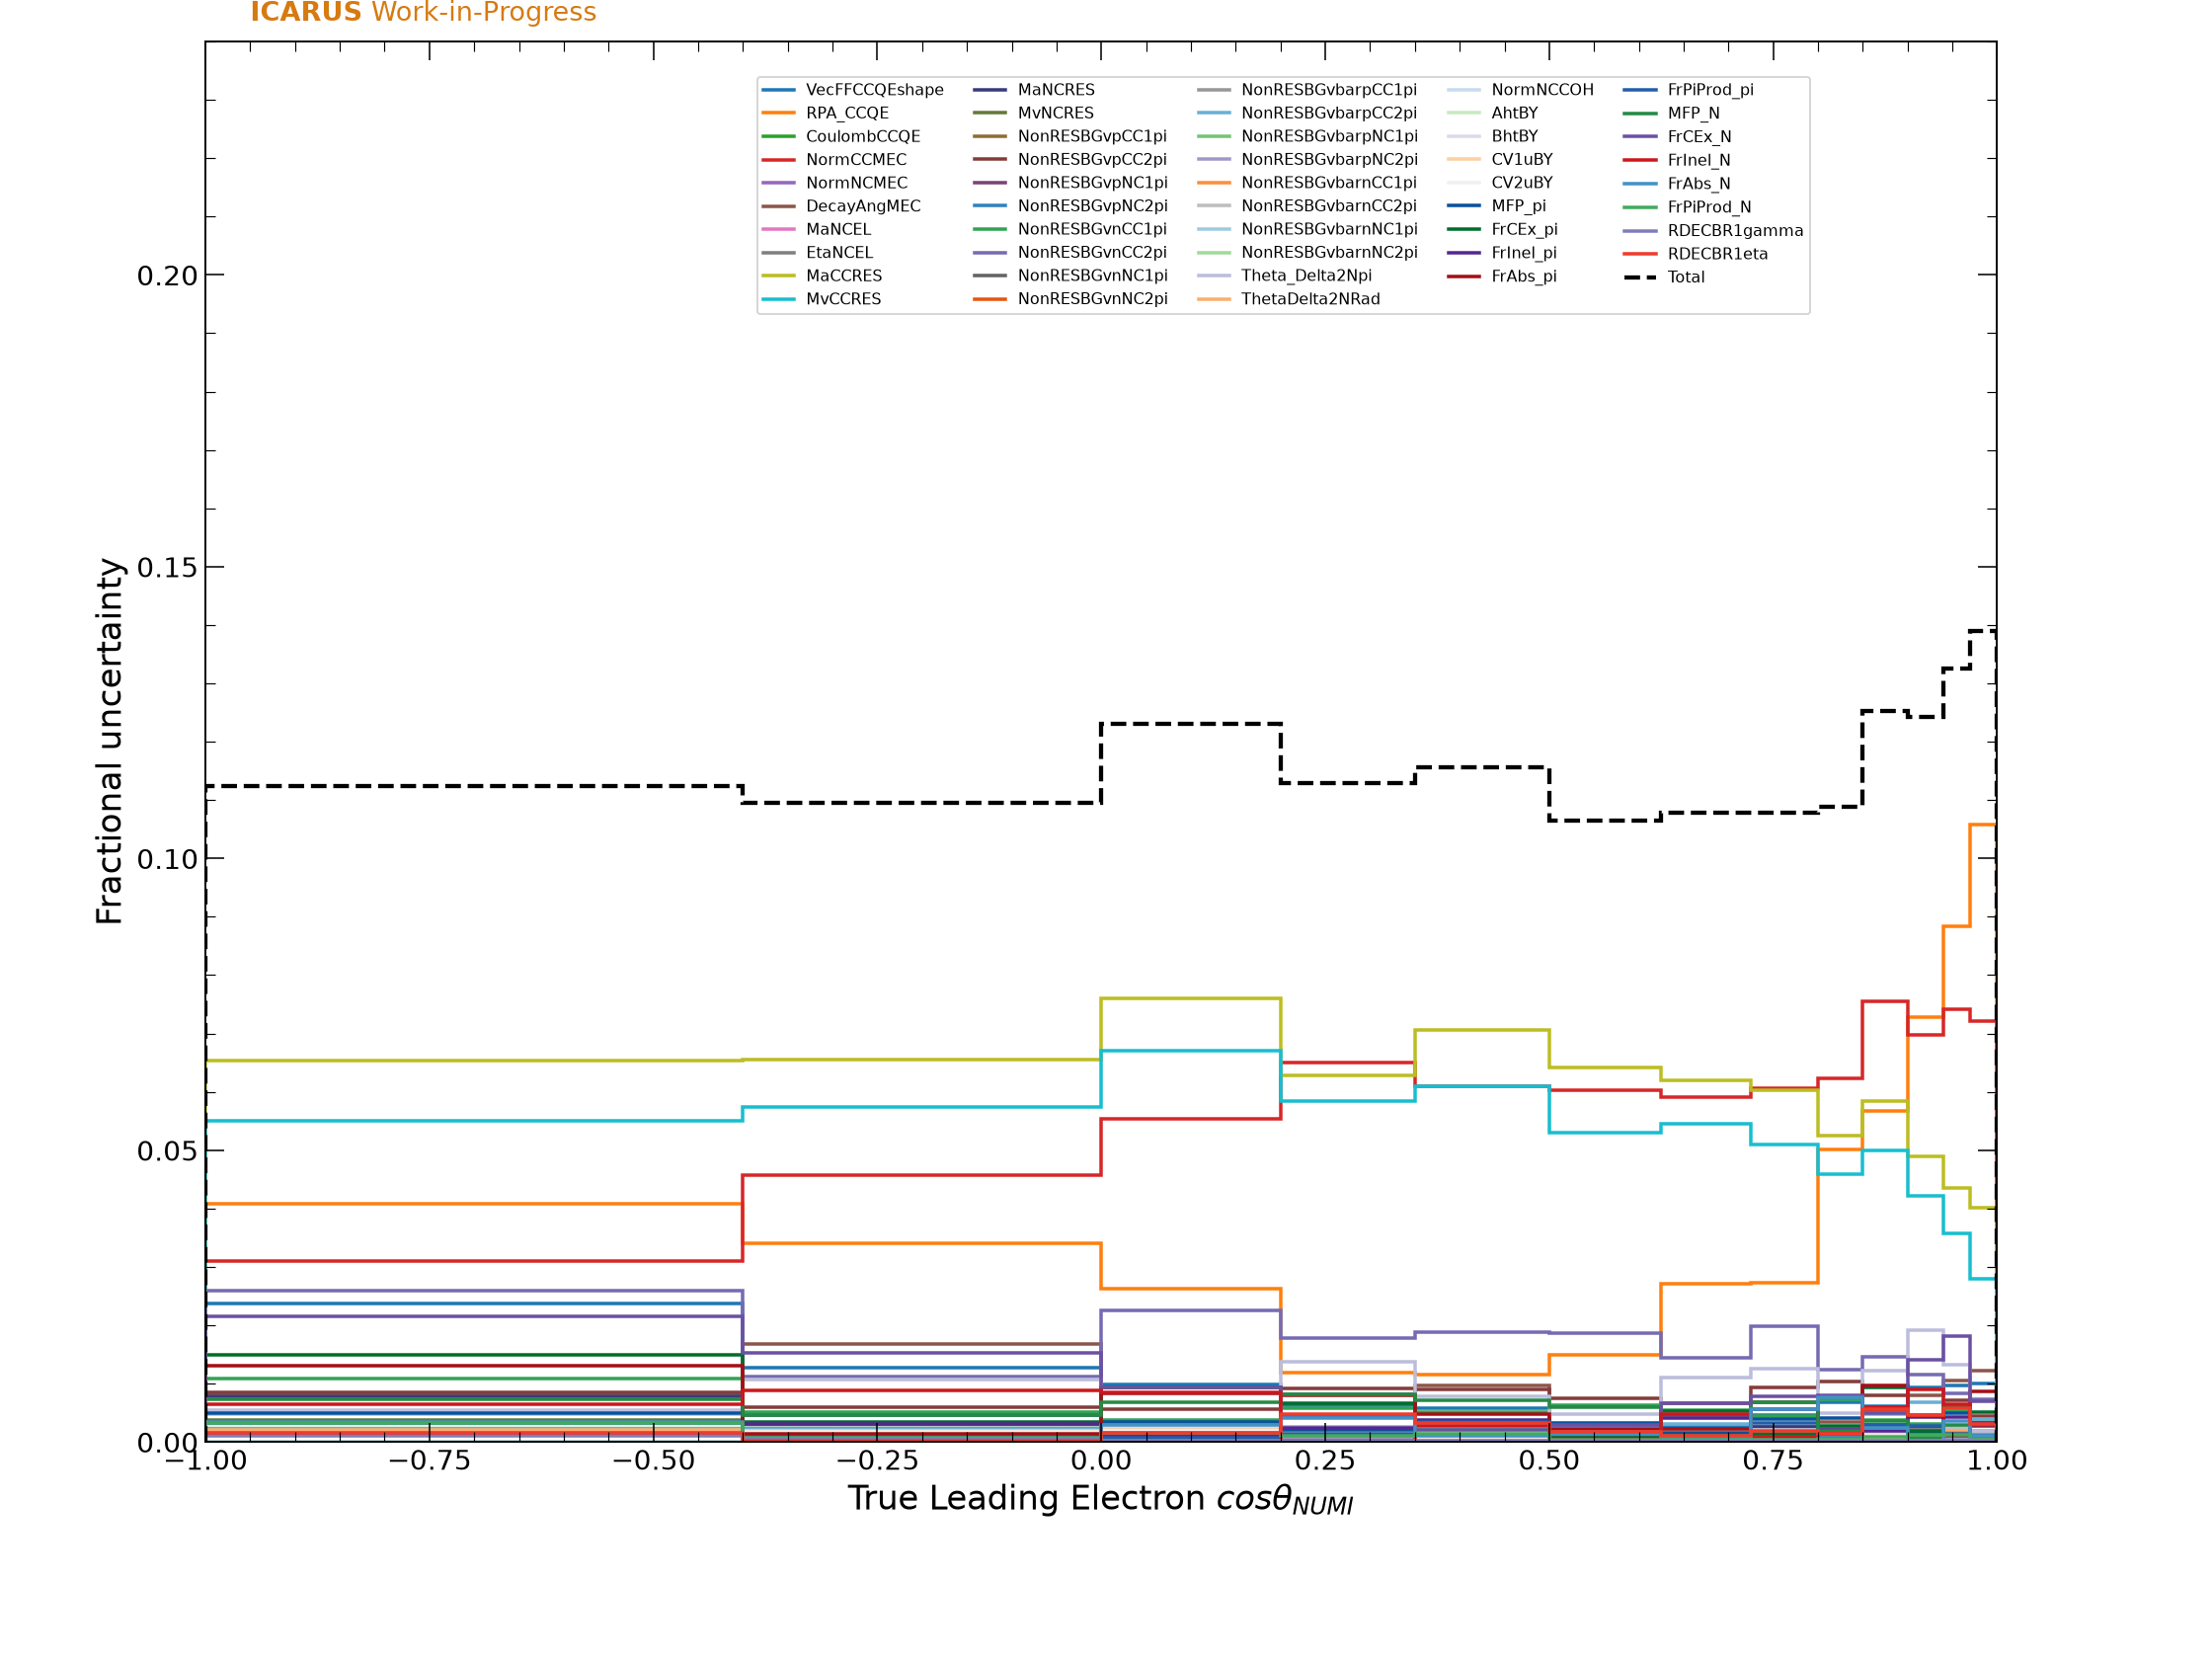

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.000%  NormNCMEC
   0.000%  MaNCEL
   0.000%  EtaNCEL
   0.000%  NonRESBGvbarnNC1pi
   0.002%  NonRESBGvpNC1pi
   0.004%  NonRESBGvbarnNC2pi
   0.004%  NormNCCOH
   0.007%  NonRESBGvbarnCC1pi
   0.011%  NonRESBGvnNC1pi
   0.016%  NonRESBGvbarpNC1pi
   0.038%  NonRESBGvpCC1pi
   0.045%  NonRESBGvbarpNC2pi
   0.052%  RDECBR1gamma
   0.055%  NonRESBGvbarpCC1pi
   0.067%  NonRESBGvbarnCC2pi
   0.073%  ThetaDelta2NRad
   0.073%  NonRESBGvnNC2pi
   0.160%  FrPiProd_N
   0.165%  MvNCRES
   0.187%  CV2uBY
   0.190%  RDECBR1eta
   0.191%  AhtBY
   0.202%  CoulombCCQE
   0.204%  CV1uBY
   0.206%  FrPiProd_pi
   0.233%  FrInel_pi
   0.233%  NonRESBGvpNC2pi
   0.237%  FrAbs_N
   0.238%  NonRESBGvbarpCC2pi
   0.295%  BhtBY
   0.361%  MFP_pi
   0.462%  MaNCRES
   0.556%  FrInel_N
   0.585%  MFP_N
   0.678%  NonRESBGvnCC1pi
   0.700%  FrAbs_pi
   0.755%  NonRESBGvpCC2pi
   0.774%  FrCEx_pi
   0.778%  Theta_Delta2Npi
   0.7

In [50]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec_all/plot_sys_trueEleCosThetaNUMI.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.9, 0.98),
    legend_text_size=8,
    ylim=(0, 0.24),
    figsize=(16, 12)

 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


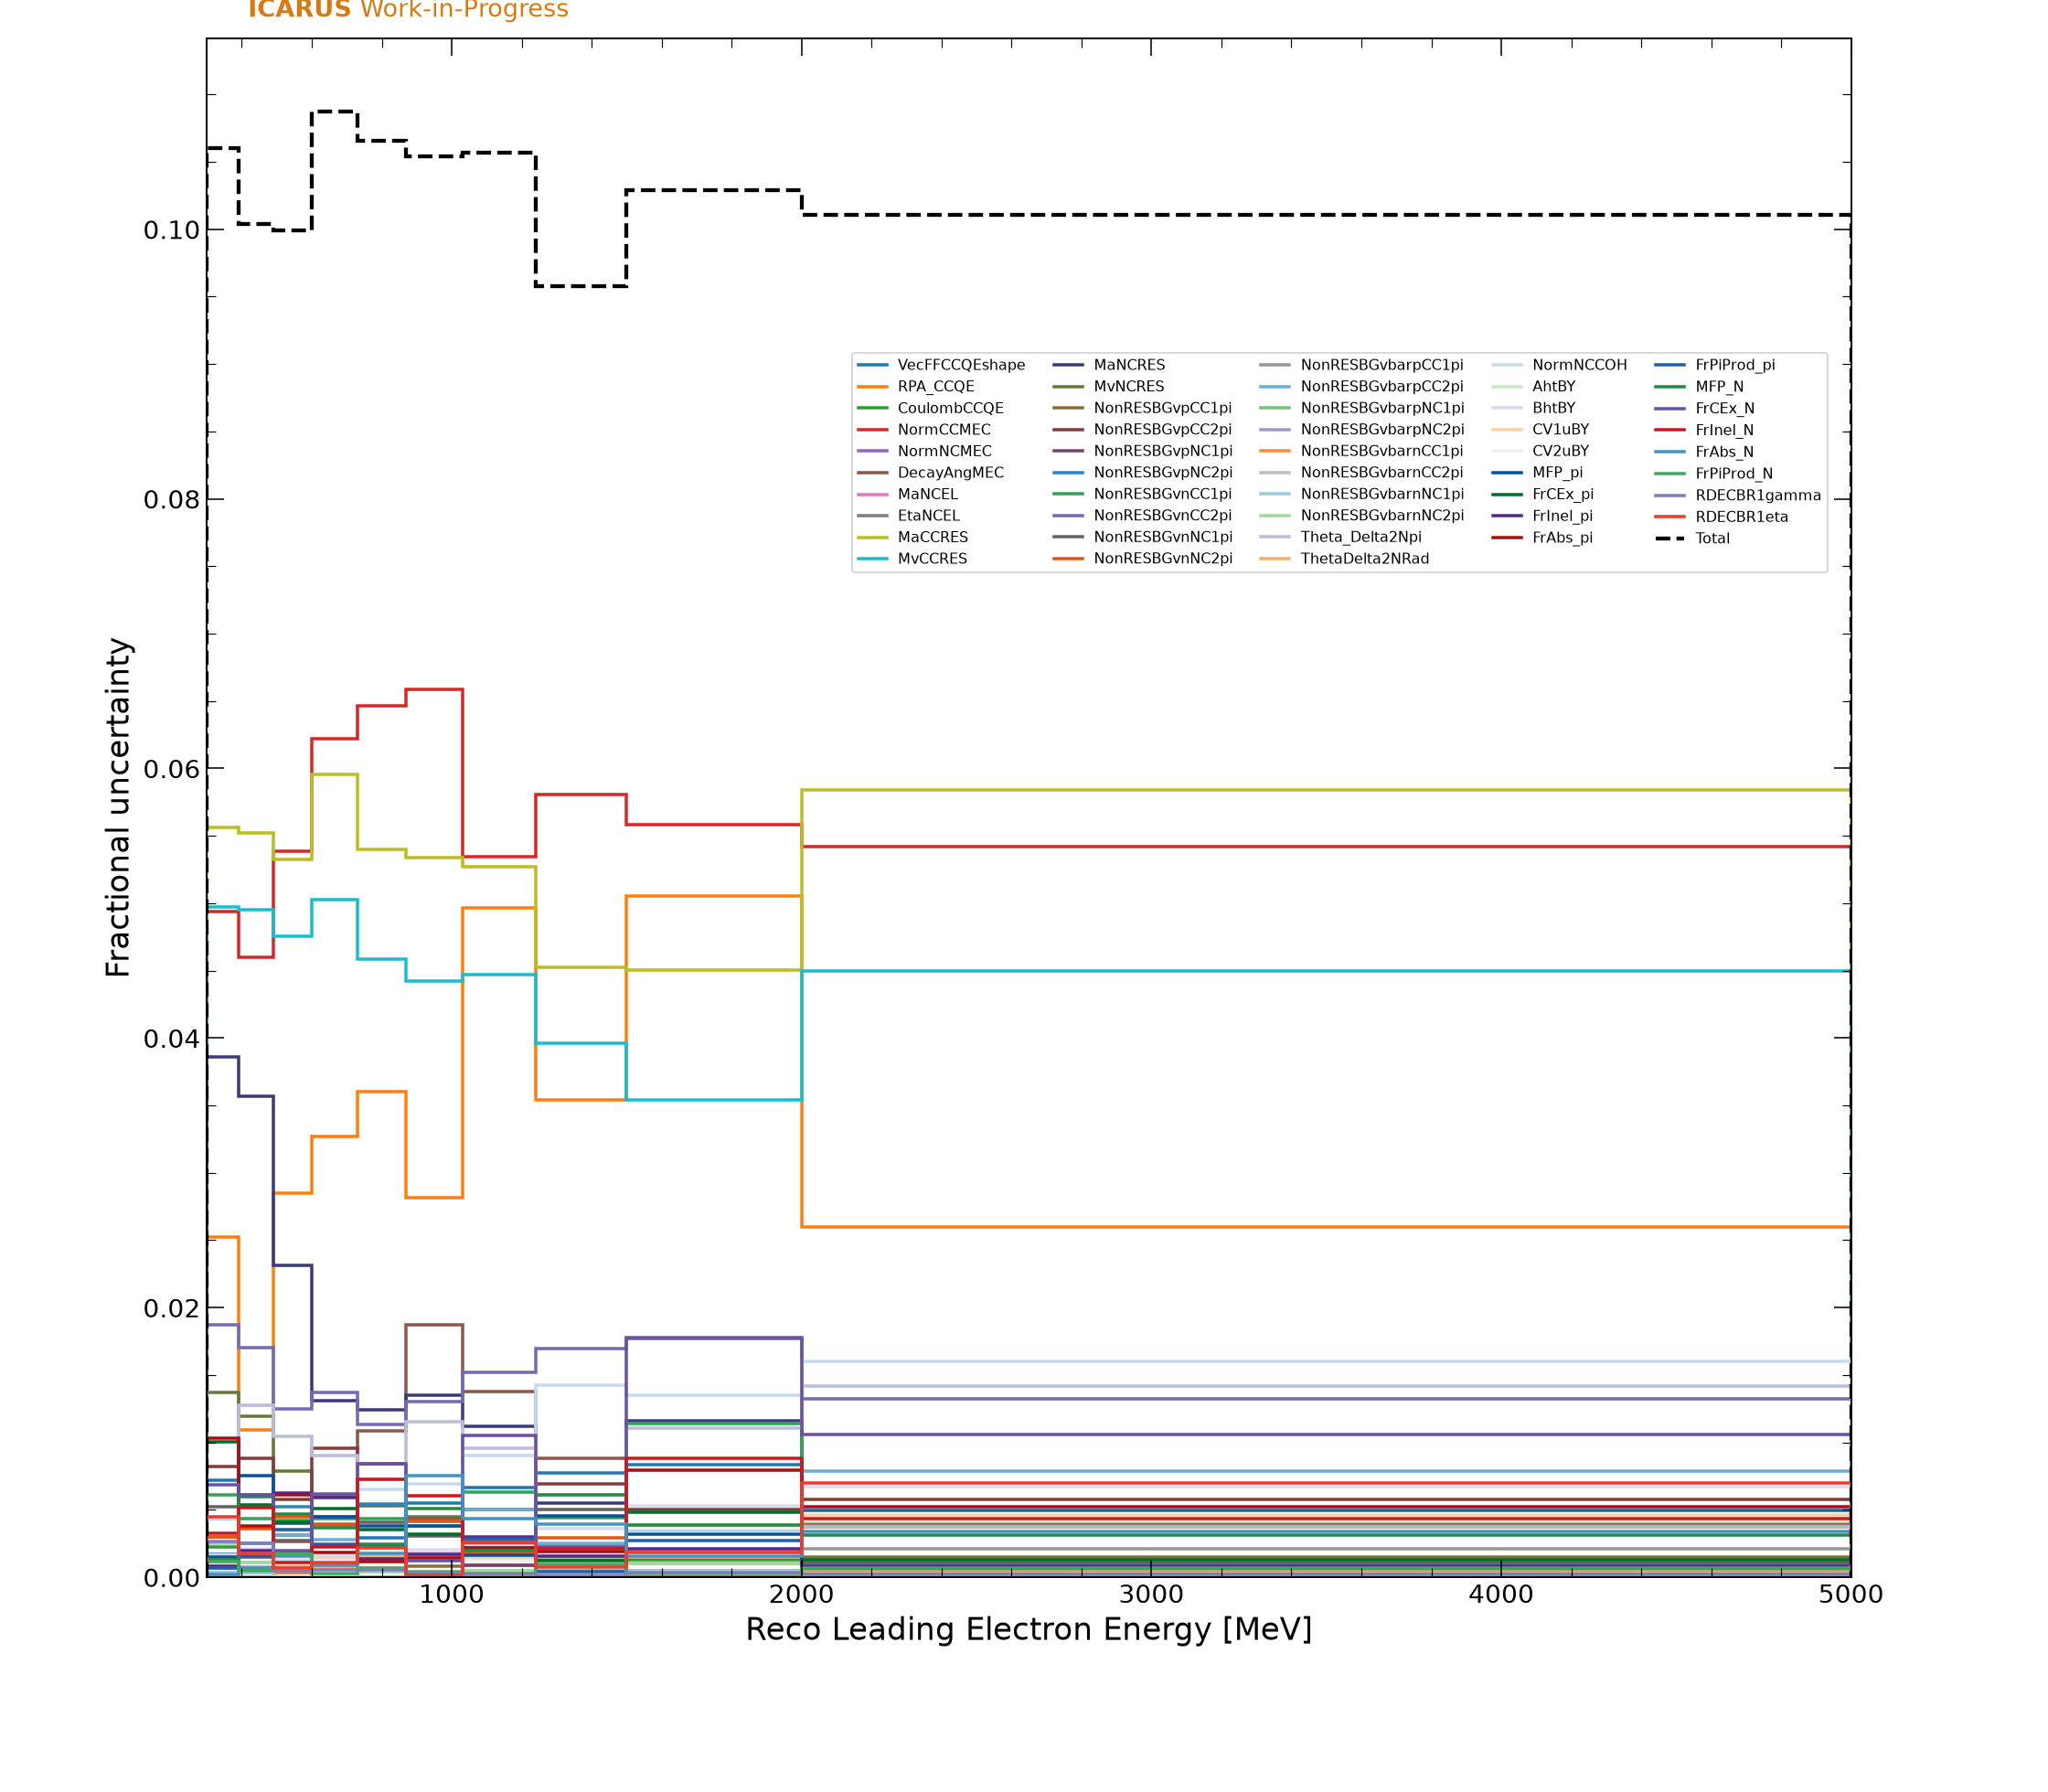

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.000%  MaNCEL
   0.000%  EtaNCEL
   0.001%  NormNCMEC
   0.013%  NonRESBGvbarnNC1pi
   0.017%  NonRESBGvbarpNC2pi
   0.032%  NonRESBGvbarnNC2pi
   0.033%  RDECBR1gamma
   0.036%  ThetaDelta2NRad
   0.039%  NonRESBGvpNC1pi
   0.045%  NonRESBGvbarnCC1pi
   0.046%  NonRESBGvbarpNC1pi
   0.063%  FrPiProd_N
   0.091%  CoulombCCQE
   0.101%  NonRESBGvnNC2pi
   0.109%  NonRESBGvpCC1pi
   0.145%  FrInel_pi
   0.167%  NonRESBGvpNC2pi
   0.170%  MvNCRES
   0.172%  NonRESBGvbarpCC1pi
   0.176%  MFP_pi
   0.208%  NonRESBGvnNC1pi
   0.226%  FrCEx_pi
   0.288%  NonRESBGvbarnCC2pi
   0.312%  FrAbs_N
   0.343%  AhtBY
   0.344%  CV2uBY
   0.346%  MFP_N
   0.374%  CV1uBY
   0.387%  FrPiProd_pi
   0.463%  FrInel_N
   0.464%  VecFFCCQEshape
   0.492%  FrAbs_pi
   0.505%  RDECBR1eta
   0.508%  NonRESBGvnCC1pi
   0.530%  DecayAngMEC
   0.541%  BhtBY
   0.595%  NonRESBGvpCC2pi
   0.597%  NonRESBGvbarpCC2pi
   0.793%  MaNCRES
   0.

In [55]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec_all/plot_sys_eleE.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.99, 0.8),
    legend_text_size=8,
    figsize=(16, 14)
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


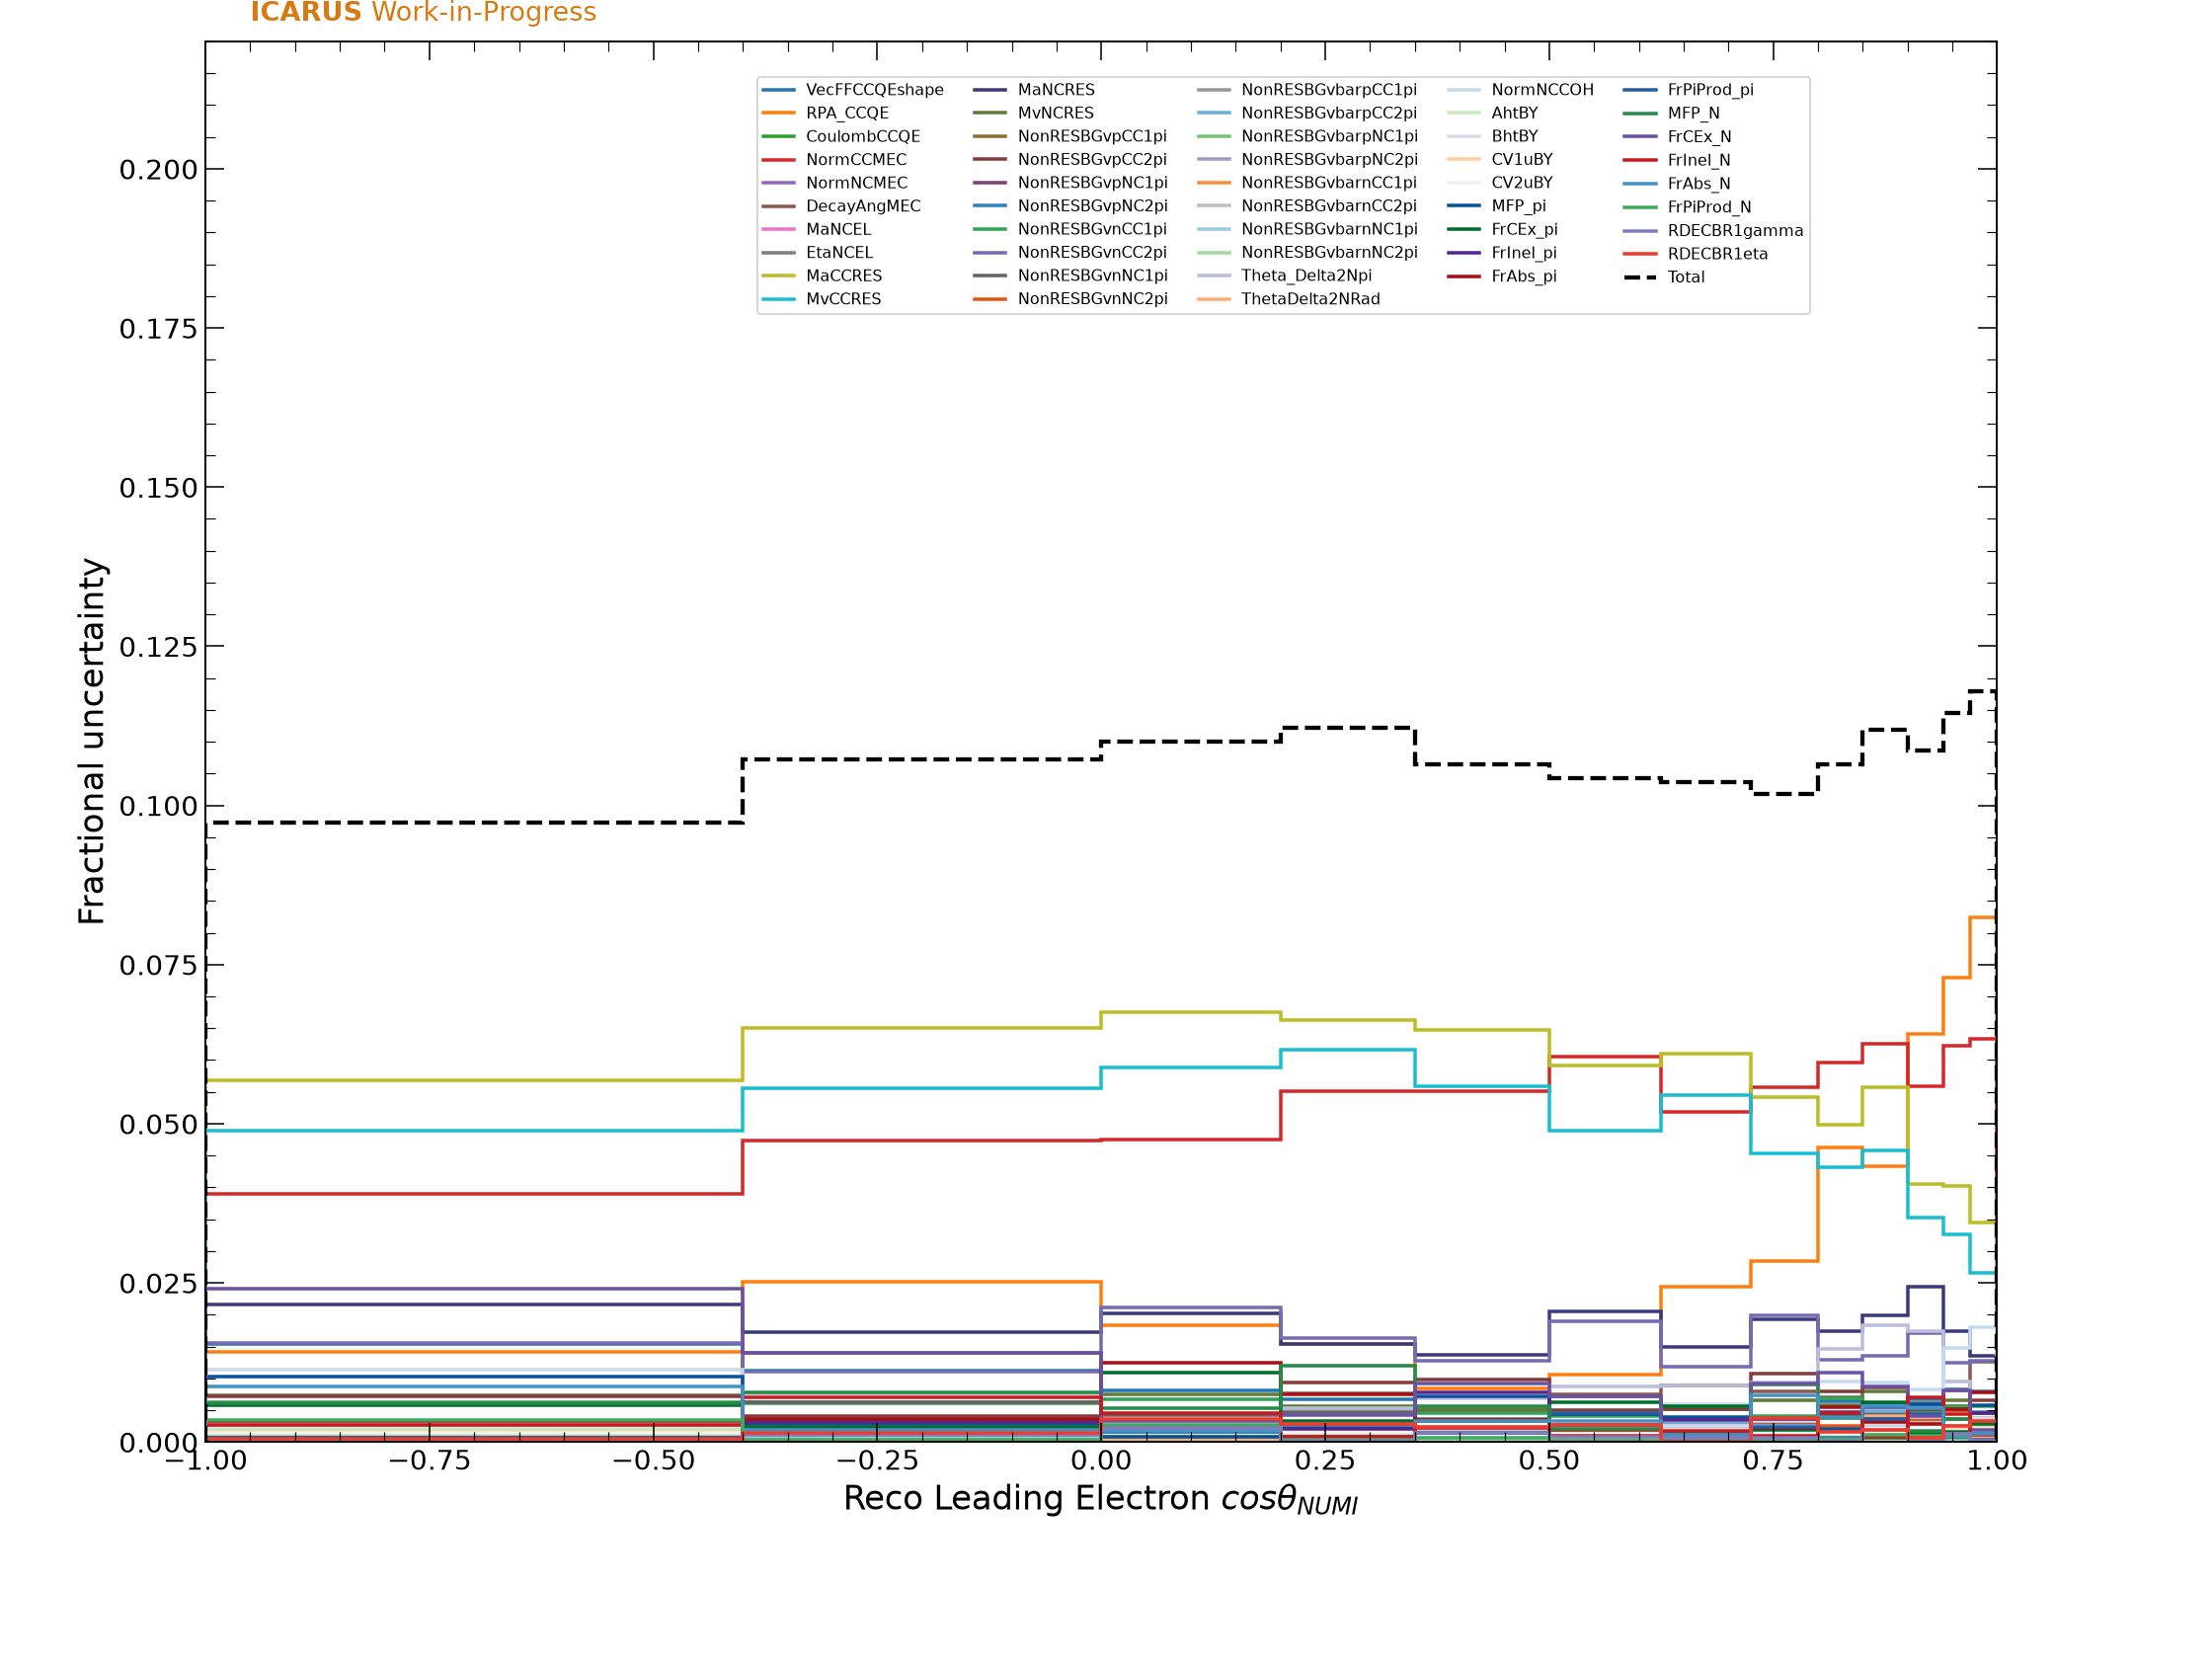

Systematics ranked by average fractional uncertainty (smallest → largest):
   0.000%  MaNCEL
   0.000%  EtaNCEL
   0.013%  NormNCMEC
   0.015%  NonRESBGvbarpNC2pi
   0.024%  NonRESBGvbarnNC1pi
   0.032%  NonRESBGvbarnCC1pi
   0.049%  NonRESBGvbarpNC1pi
   0.055%  ThetaDelta2NRad
   0.058%  NonRESBGvpCC1pi
   0.076%  NonRESBGvbarpCC1pi
   0.084%  RDECBR1gamma
   0.088%  NonRESBGvbarnNC2pi
   0.094%  NonRESBGvbarnCC2pi
   0.126%  NonRESBGvpNC1pi
   0.140%  FrPiProd_pi
   0.154%  FrPiProd_N
   0.166%  CV2uBY
   0.169%  RDECBR1eta
   0.176%  AhtBY
   0.178%  CoulombCCQE
   0.180%  CV1uBY
   0.213%  NonRESBGvbarpCC2pi
   0.219%  NonRESBGvnNC2pi
   0.245%  BhtBY
   0.253%  NonRESBGvpNC2pi
   0.261%  FrInel_pi
   0.340%  FrInel_N
   0.366%  NonRESBGvnNC1pi
   0.447%  FrAbs_pi
   0.456%  FrAbs_N
   0.485%  FrCEx_pi
   0.530%  MFP_pi
   0.574%  NonRESBGvnCC1pi
   0.595%  Theta_Delta2Npi
   0.599%  MFP_N
   0.608%  DecayAngMEC
   0.619%  NormNCCOH
   0.643%  NonRESBGvpCC2pi
   0.656%  MvNCRES
  

In [52]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_xsec_all/plot_sys_eleCosThetaNUMI.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.9, 0.98),
    legend_text_size=8,
    ylim=(0, 0.22),
    figsize=(16, 12)
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


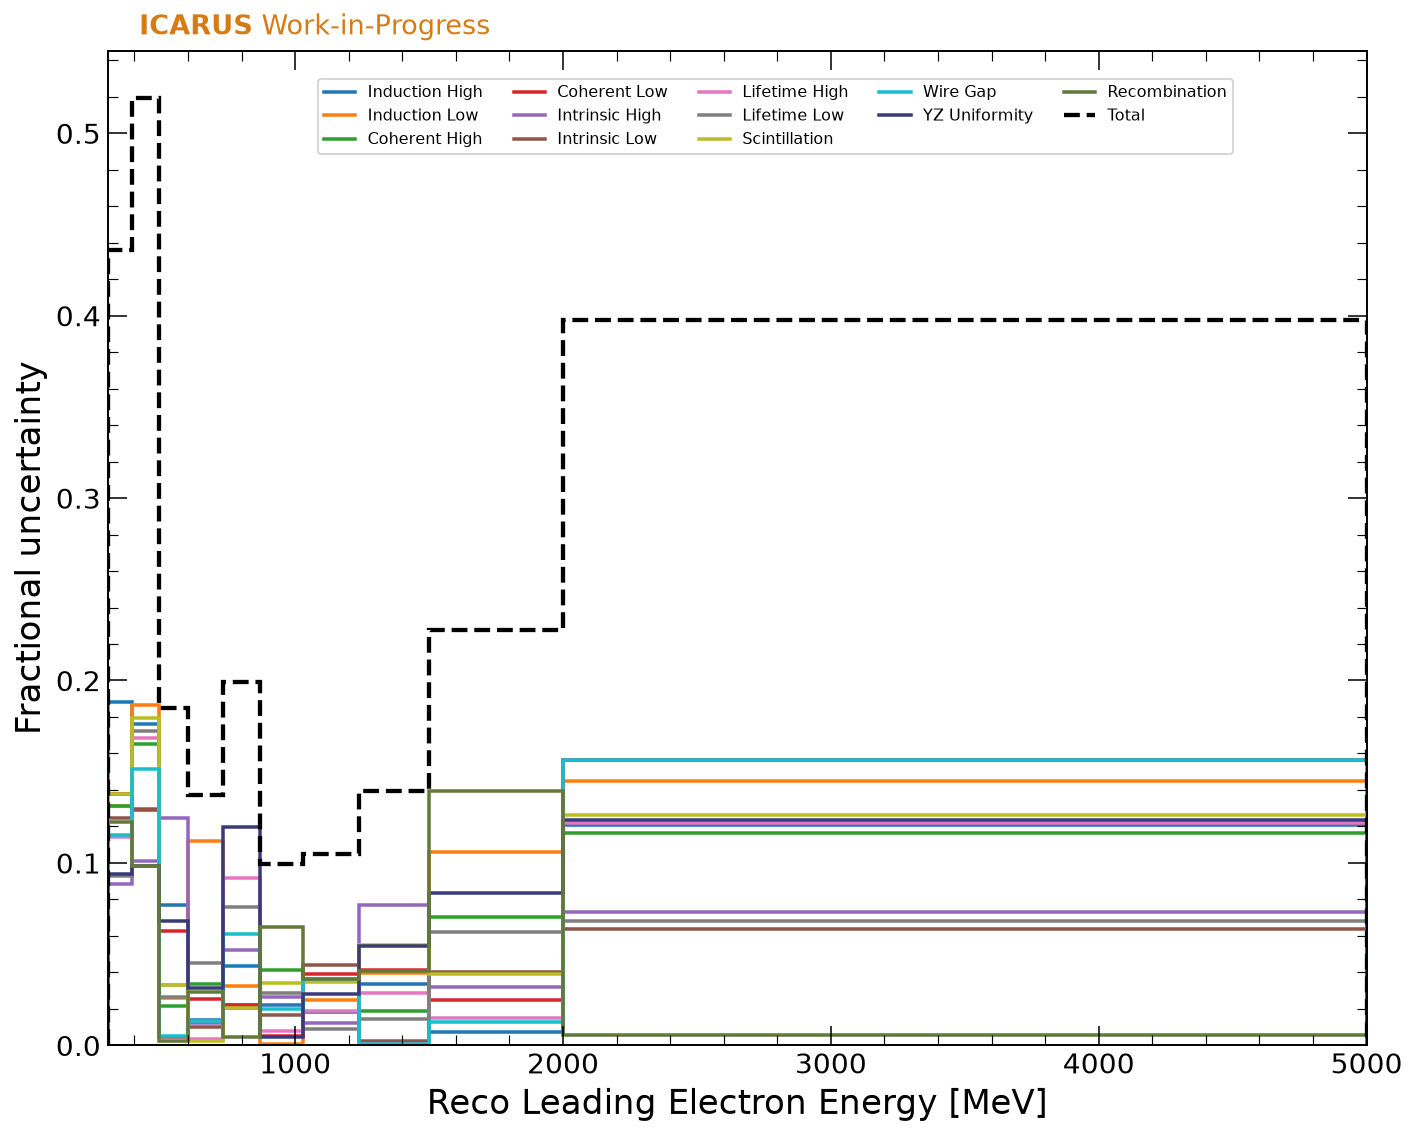

Systematics ranked by average fractional uncertainty (smallest → largest):
   2.995%  Recombination
   5.365%  Intrinsic Low
   6.179%  Lifetime Low
   6.429%  Intrinsic High
   9.147%  Lifetime High
   9.196%  Induction High
   9.400%  Coherent High
   9.858%  Scintillation
  10.209%  YZ Uniformity
  11.133%  Wire Gap
  11.479%  Coherent Low
  11.818%  Induction Low
Total (quadrature sum): 31.155%


In [58]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_detector/plot_sys_eleE.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.9, 0.98),
    legend_text_size=8,
    #ylim=(0, 0.22),
    # figsize=(16, 12)
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


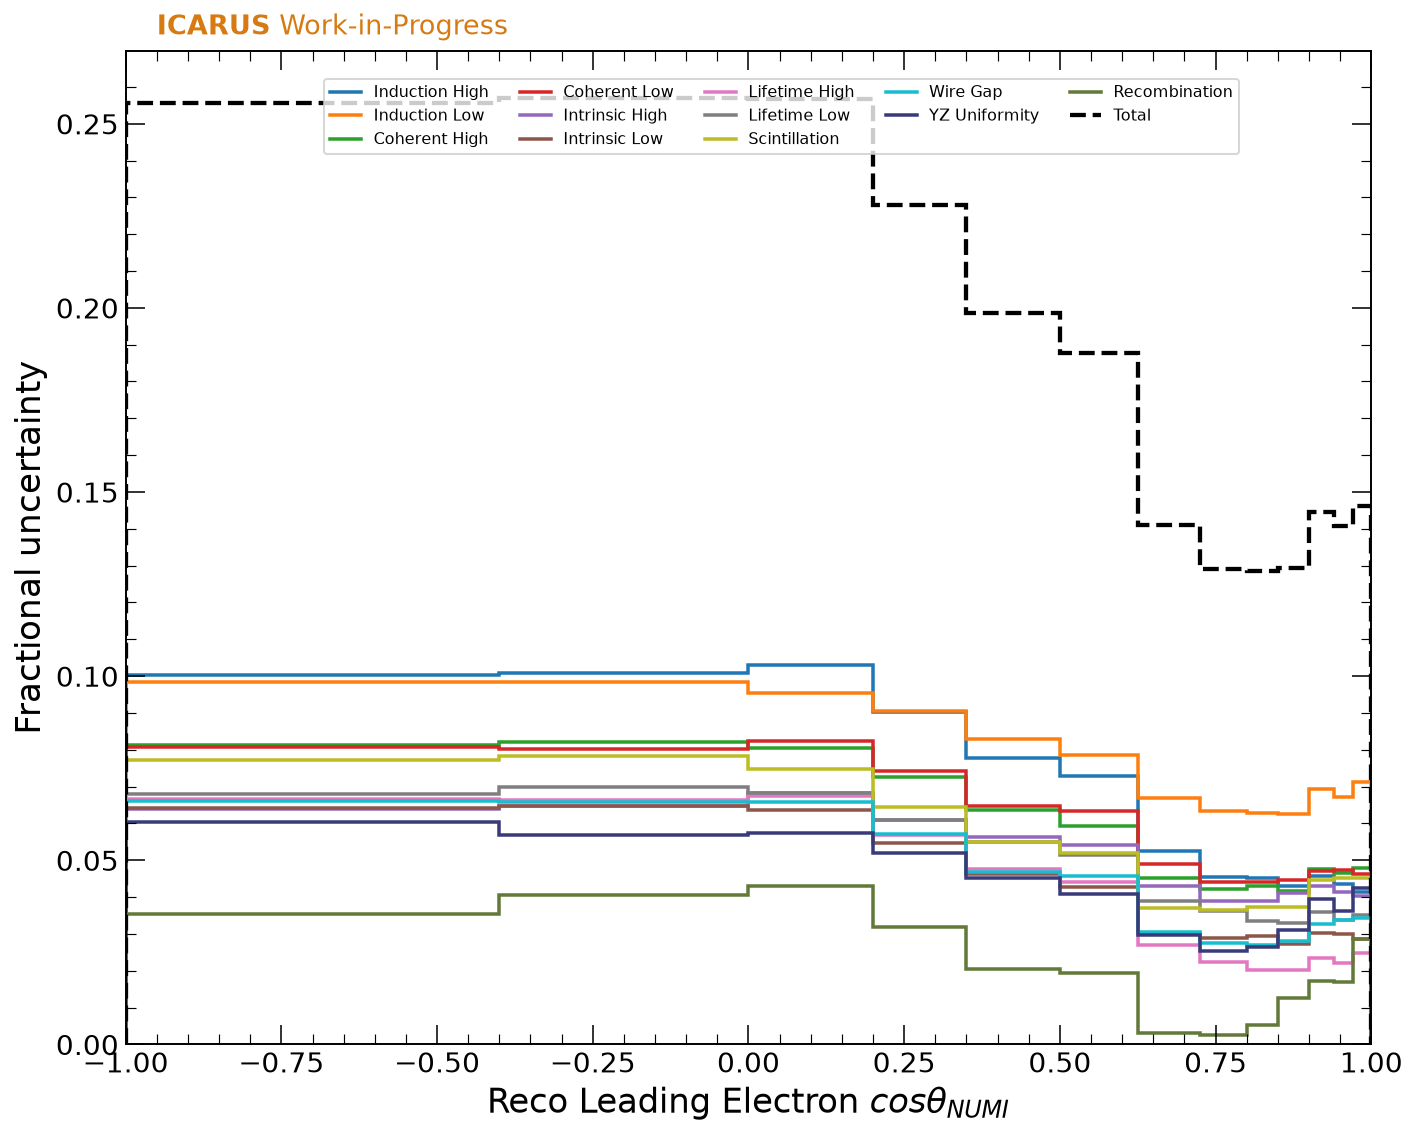

Systematics ranked by average fractional uncertainty (smallest → largest):
   2.990%  Recombination
   5.094%  YZ Uniformity
   5.426%  Intrinsic Low
   5.497%  Lifetime High
   5.584%  Wire Gap
   5.880%  Intrinsic High
   5.977%  Lifetime Low
   6.588%  Scintillation
   7.109%  Coherent High
   7.156%  Coherent Low
   8.643%  Induction High
   8.895%  Induction Low
Total (quadrature sum): 22.249%


In [59]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_detector/plot_sys_eleCosThetaNUMI.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.9, 0.98),
    legend_text_size=8,
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


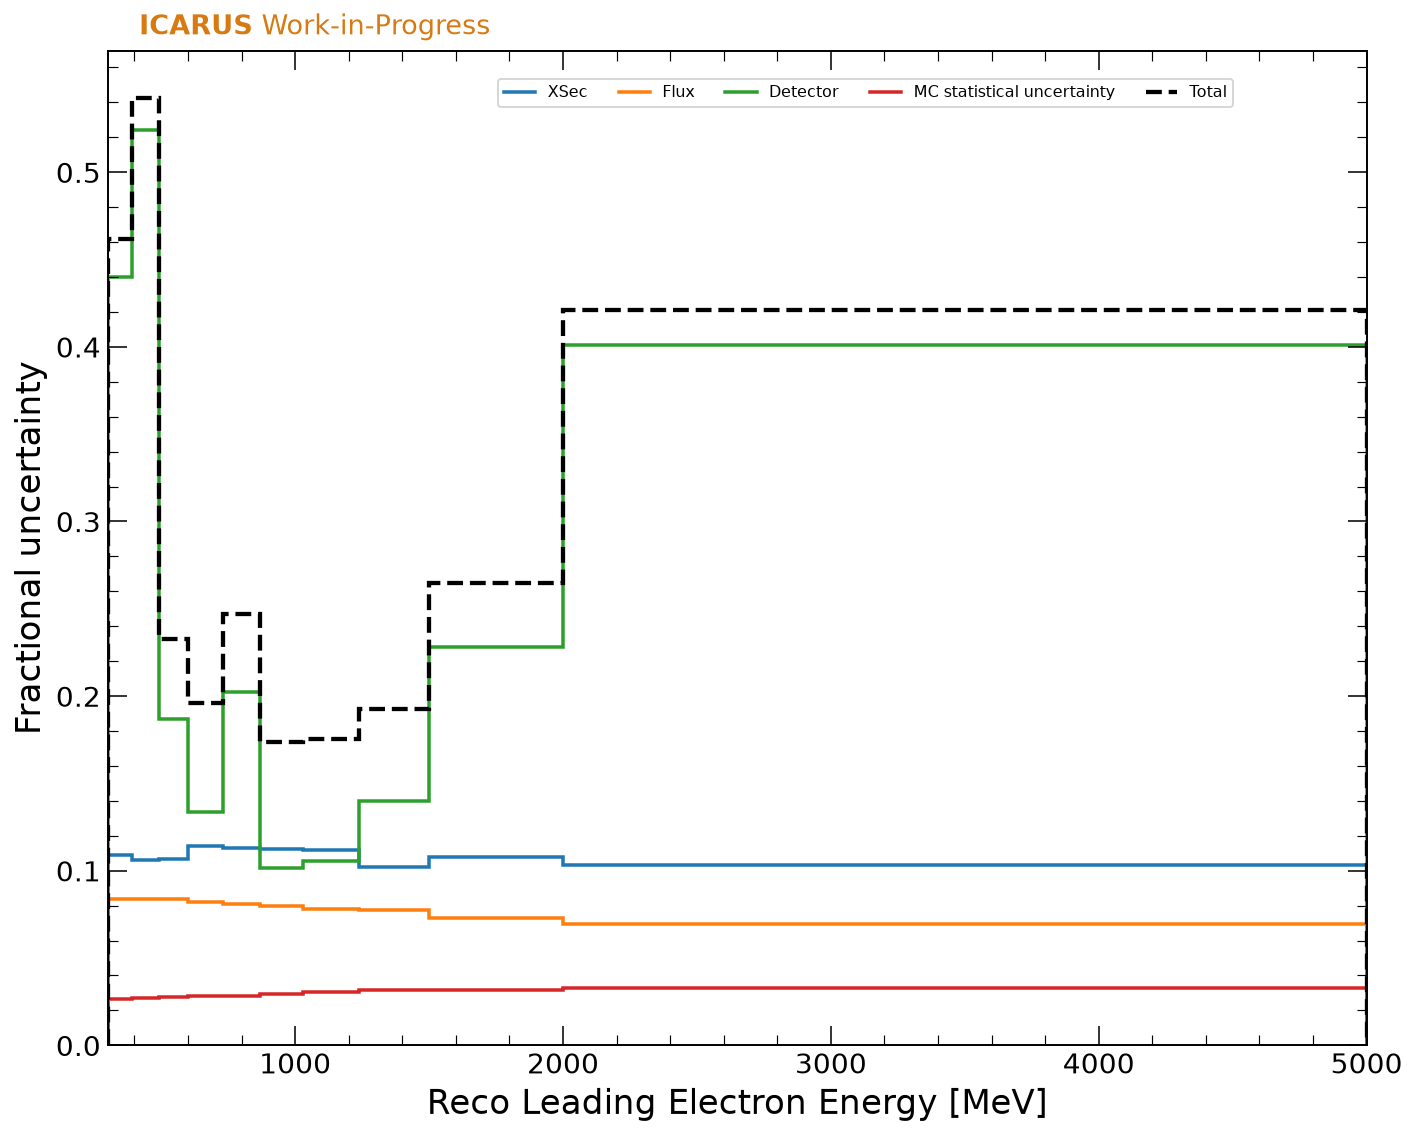

Systematics ranked by average fractional uncertainty (smallest → largest):
   3.167%  MC statistical uncertainty
   7.271%  Flux
  10.532%  XSec
  32.991%  Detector
Total (quadrature sum): 35.527%


In [60]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_total/plot_sys_eleE.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.9, 0.98),
    legend_text_size=8,
    #ylim=(0, 0.22),
    # figsize=(16, 12)
 )

/tmp/ipykernel_212655/2271129480.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


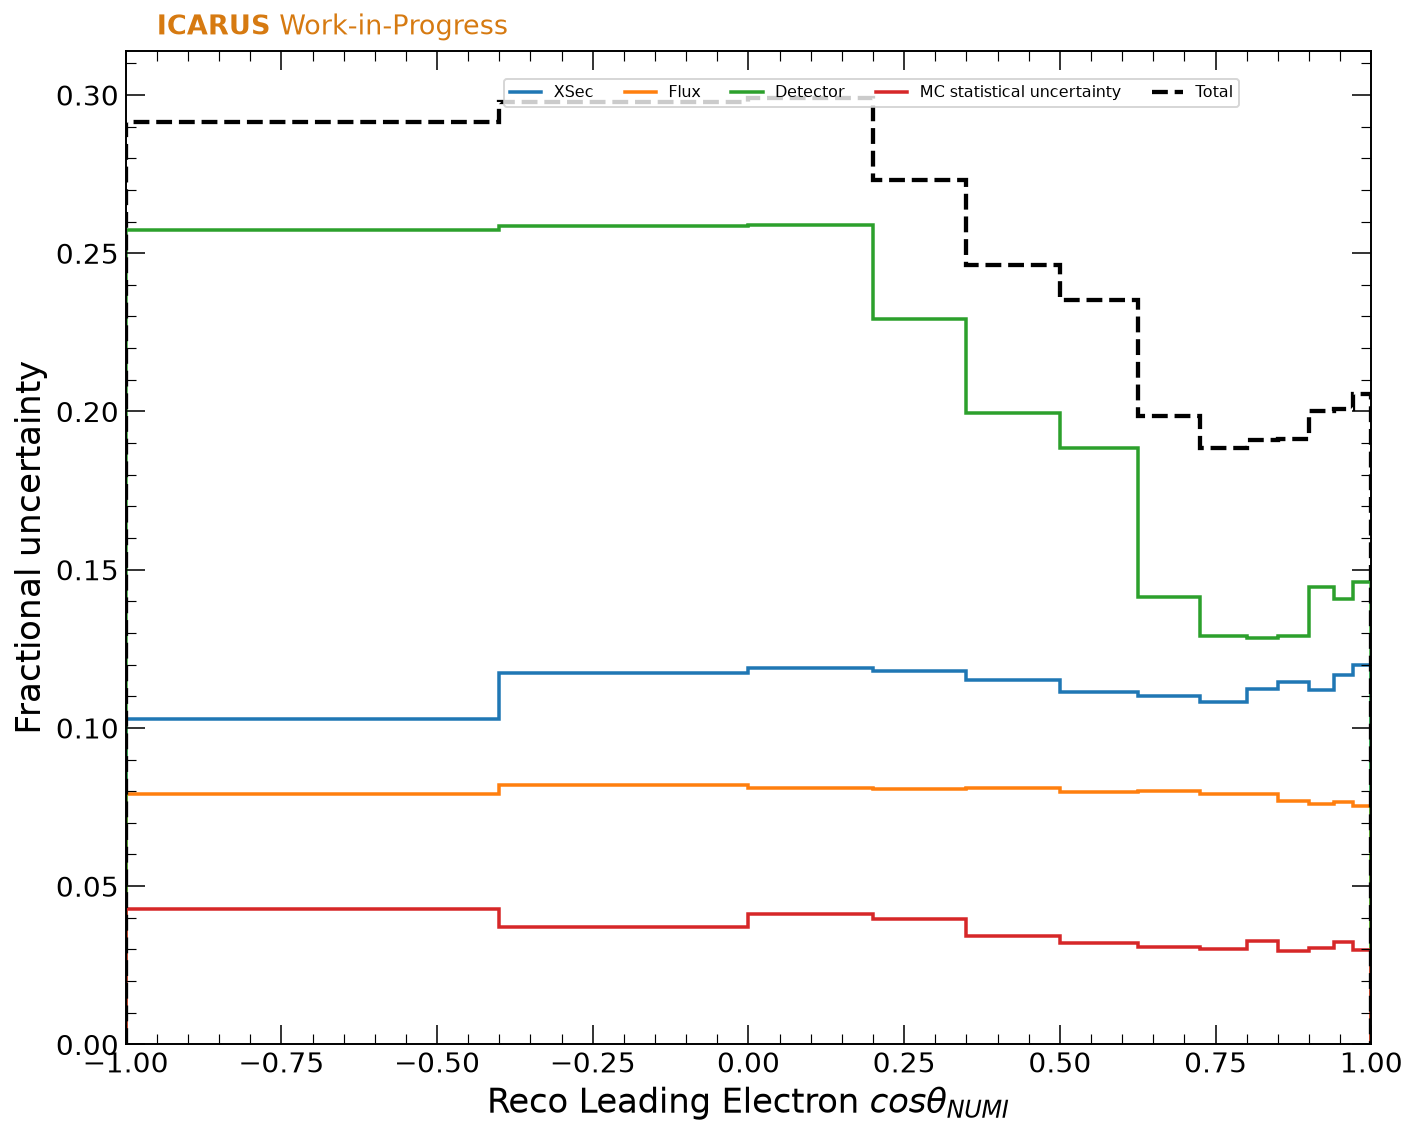

Systematics ranked by average fractional uncertainty (smallest → largest):
   3.771%  MC statistical uncertainty
   8.000%  Flux
  11.163%  XSec
  22.427%  Detector
Total (quadrature sum): 26.568%


In [61]:
recolor_pickled_figure(
    '/nashome/m/micarrig/icarus/nuESpine/plots_sept15/systematics_total/plot_sys_eleCosThetaNUMI.pkl',
    legend_loc='upper right',
    legend_ncol=5,
    anchor=(0.9, 0.98),
    legend_text_size=8,
 )

## Analyze Visible Energy - Leading Electron Energy (nu)

Fit parameters:
N     = 329.47244840137887 +/- 18.65740164783643
beta  = 0.9606263402615998 +/- 0.13079102606186618
m     = 2.0612165072756317 +/- 0.32117452698541377
mu    = 0.005584330170196033 +/- 0.004750311740695942
sigma = 0.06223071993291864 +/- 0.004409301925647392


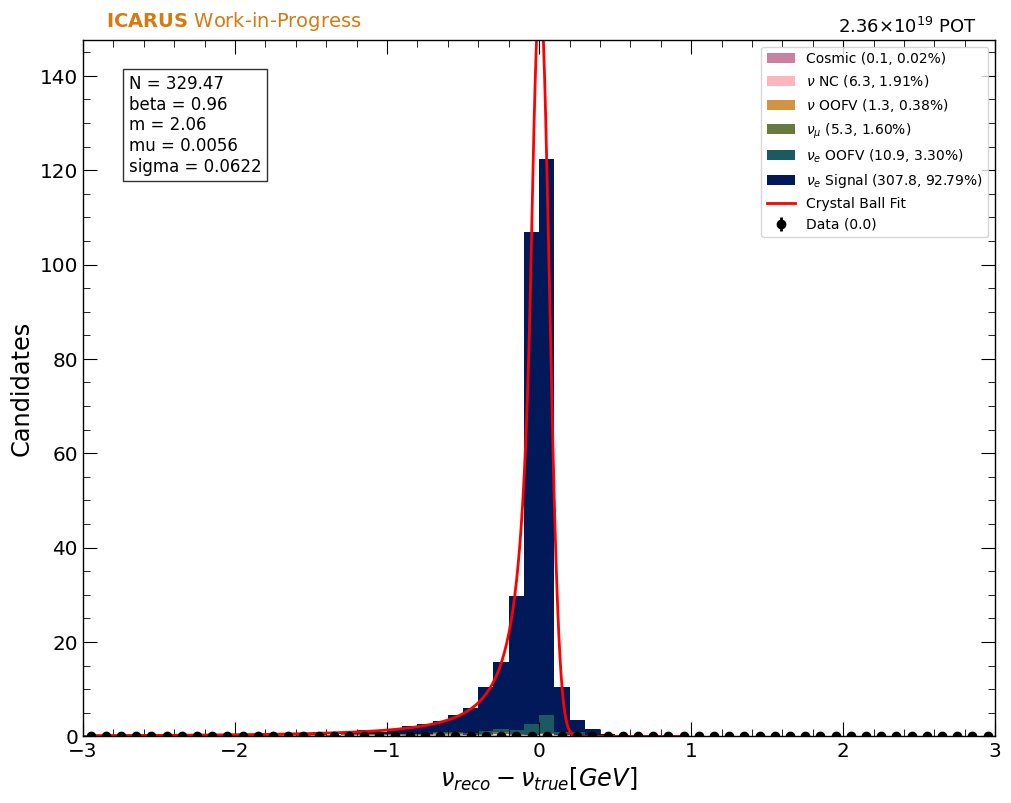

In [91]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import crystalball
from scipy.optimize import curve_fit

# --------------------------------------------------
# Load figure
# --------------------------------------------------

with open('/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_nu_diff.pkl', 'rb') as f:
    fig = pickle.load(f)

ax = fig.axes[0]

# --------------------------------------------------
# Extract histogram from matplotlib figure
# --------------------------------------------------

patches = ax.patches

# unique bin centers
all_centers = np.array([
    p.get_x() + p.get_width()/2
    for p in patches
])

all_heights = np.array([
    p.get_height()
    for p in patches
])

bin_width = patches[0].get_width()

# group identical centers
unique_centers = np.unique(all_centers)

summed_heights = []

for c in unique_centers:

    mask = np.isclose(all_centers, c)

    summed_heights.append(
        np.sum(all_heights[mask])
    )

centers = unique_centers
heights = np.array(summed_heights)

# --------------------------------------------------
# Remove empty bins
# --------------------------------------------------

mask = heights > 0
mask = mask & (centers > -3.0) & (centers < 1.0)

centers = centers[mask]
heights = heights[mask]

# --------------------------------------------------
# Crystal Ball fit function
# --------------------------------------------------

def cb_fit(x, N, beta, m, mu, sigma):

    return (
        N * bin_width
        * crystalball.pdf(
            x,
            beta,
            m,
            loc=mu,
            scale=sigma
        )
    )

# --------------------------------------------------
# Initial guesses
# --------------------------------------------------

p0 = [
    140,                 # normalization
    1.5,                             # beta
    3,                               # m
    -0.05,     # mu
    0.05                             # sigma
]

# --------------------------------------------------
# Bounds (helps stability a LOT)
# --------------------------------------------------

bounds = (
    [1, 0.5, 1.1, -1, 0.001],
    [1e9, 10, 100, 1, 10]
)

sigma_y = np.sqrt(heights)
sigma_y[sigma_y == 0] = 1

# --------------------------------------------------
# Perform fit
# --------------------------------------------------

popt, pcov = curve_fit(
    cb_fit,
    centers,
    heights,
    p0=p0,
    bounds=bounds,
    sigma=sigma_y,
    absolute_sigma=True,
    maxfev=100000
)

# --------------------------------------------------
# Draw fit
# --------------------------------------------------

xfit = np.linspace(
    np.min(centers),
    np.max(centers),
    500
)

yfit = cb_fit(xfit, *popt)

ax.plot(
    xfit,
    yfit,
    color='red',
    lw=2,
    label='Crystal Ball Fit'
)

ax.legend()
# ax.set_ylim(0, 175)

# --------------------------------------------------
# Print parameters
# --------------------------------------------------

perr = np.sqrt(np.diag(pcov))

print("Fit parameters:")
print("N     =", popt[0], "+/-", perr[0])
print("beta  =", popt[1], "+/-", perr[1])
print("m     =", popt[2], "+/-", perr[2])
print("mu    =", popt[3], "+/-", perr[3])
print("sigma =", popt[4], "+/-", perr[4])

fit_text = (
    f"N = {popt[0]:.2f}\n"
    f"beta = {popt[1]:.2f}\n"
    f"m = {popt[2]:.2f}\n"
    f"mu = {popt[3]:.4f}\n"
    f"sigma = {popt[4]:.4f}"
)

ax.text(
    0.05,           # x position in axes coordinates
    0.95,           # y position
    fit_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.show()

In [79]:
patches = ax.patches
print(len(patches))

360


# Compare to nue CC Np 0Pi Selection

In [15]:
fin = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCNp0pi.root:events/debugMC/all")

In [16]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_single_electron", "1 Electron-like Particle"))
selections.append(selection("reco_multiproton", ">=1 Proton-like Particles"))
selections.append(selection("reco_no_charged_pions", "No Charged Pion-like Particles"))
selections.append(selection("reco_leading_electron_cut_axial_spread", "Axial Spread > 0.02"))
selections.append(selection("reco_leading_electron_cut_directional_spread", "Directional Spread < 0.25"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 7.5 cm"))
selections.append(selection("reco_good_proton", "Good Proton-like Particle"))
selections.append(selection("reco_good_electron", "Good Electron-like Particle"))

In [17]:
hists = get_effHists('reco_leading_electron_ke', fin, selections, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron KE Efficiency", "Leading Electron KE (MeV)", "Efficiency", range=(0.1, 1.2))

c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (618/618)
Applying selection: Flash Cut
Efficiency after Flash Cut: 0.6893 (426/618)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.6796 (420/618)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6440 (398/618)
Applying selection: 1 Electron-like Particle
Efficiency after 1 Electron-like Particle: 0.5631 (348/618)
Applying selection: >=1 Proton-like Particles
Efficiency after >=1 Proton-like Particles: 0.4094 (253/618)
Applying selection: No Charged Pion-like Particles
Efficiency after No Charged Pion-like Particles: 0.3430 (212/618)
Applying selection: Axial Spread > 0.02
Efficiency after Axial Spread > 0.02: 0.3366 (208/618)
Applying selection: Directional Spread < 0.25
Efficiency after Directional Spread < 0.25: 0.3350 (207/618)
Applying selection: Vertex Distance < 7.5 cm
Efficiency after Vertex Distance < 7.5 cm: 0.3220 (199/618)
Applying selection: Good Pro

Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skippe

## Compare SPINE and Pandora Pre Selection

In [225]:
f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_eff/t_eff")
f_spine = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/all")

In [226]:
f_pandora.keys()

['tNueEnergy',
 'rShowerEnergy',
 'rShowerDeDx',
 'rShowerDensity',
 'rShowerConversionGap',
 'rLongestTrackLength',
 'rBarycenterDeltaZ',
 'rBarycenterRadius',
 'rFiducial',
 'rShowerContained',
 'rMuonChi2',
 'tInteractionMode',
 'tNeutrinoType',
 'rSubleadingShowerEnergy',
 'rShowerEResidual',
 'rSecondaryShowerEResidual',
 'rNeutrinoScore',
 'tShowerLength',
 'rShowerLenResidual',
 'rVertexResidual',
 'tShowerE',
 'tSubleadingShowerE',
 'kLongestTrackLengthResidual',
 'tTLongestTrackLength',
 'kShowerCosAngle',
 'kShowerP',
 'tFiducial',
 'rShowerLength',
 'rShowerEndX',
 'rShowerEndY',
 'rShowerEndZ',
 'rShowerStartX',
 'rShowerStartY',
 'rShowerStartZ',
 'rVertexCryo',
 'rTruthPDGID',
 'rClearCosmic',
 'rLargestShowerCut',
 'tGoodNue',
 'Run',
 'Subrun',
 'Evt',
 'Slice']

In [229]:
f_pandora.keys(), f_spine.keys()

spineSel = (f_spine['true_category'].array() == 0)

#pandoraSel = (f_pandora['tNeutrinoType'].array() == 2) & (f_pandora['tFiducial'].array() == 1)
pandoraSel = (f_pandora['tGoodNue'].array() == 1)

spineEvents = len(f_spine['true_neutrino_energy'].array()[spineSel])
pandoraEvents = len(f_pandora['tNueEnergy'].array()[pandoraSel])

print("There are {} events in the SPINE file and {} events in the Pandora file.".format(spineEvents, pandoraEvents))
print("There are {} unique events in the SPINE file and {} unique events in the Pandora file.".format(len(np.unique(f_spine['true_neutrino_energy'].array()[spineSel])), len(np.unique(f_pandora['tNueEnergy'].array()[pandoraSel]))))

There are 618 events in the SPINE file and 626 events in the Pandora file.
There are 435 unique events in the SPINE file and 557 unique events in the Pandora file.


In [96]:
spineNu = ak.count_nonzero(np.abs(f_spine['true_pdg'].array()) == 12)
pandoraNu = ak.count_nonzero(np.abs(f_pandora['tNeutrinoType'].array()) == 2)

print("There are {} true electron neutrinos in the SPINE file.".format(spineNu))
print("There are {} true electron neutrinos in the Pandora file.".format(pandoraNu))

There are 1656 true electron neutrinos in the SPINE file.
There are 955 true electron neutrinos in the Pandora file.


In [97]:
spine_vals = ak.to_numpy(f_spine['true_neutrino_energy'].array()[spineSel])
pandora_vals = ak.to_numpy(f_pandora['tNueEnergy'].array()[pandoraSel])

all_vals = np.union1d(spine_vals, pandora_vals)

for v in all_vals:
    if np.isnan(v):
        spine_count = np.count_nonzero(np.isnan(spine_vals))
        pandora_count = np.count_nonzero(np.isnan(pandora_vals))
    else:
        spine_count = np.count_nonzero(spine_vals == v)
        pandora_count = np.count_nonzero(pandora_vals == v)
    if spine_count != pandora_count:
        print("Neutrino energy {}, SPINE count {}, Pandora count {}".format(v, spine_count, pandora_count))

Neutrino energy 0.170705646276474, SPINE count 2, Pandora count 1
Neutrino energy 0.3943537473678589, SPINE count 2, Pandora count 1
Neutrino energy 0.4617410898208618, SPINE count 2, Pandora count 1
Neutrino energy 0.48265162110328674, SPINE count 2, Pandora count 1
Neutrino energy 0.48549866676330566, SPINE count 1, Pandora count 0
Neutrino energy 0.5533434152603149, SPINE count 3, Pandora count 1
Neutrino energy 0.5987469553947449, SPINE count 2, Pandora count 1
Neutrino energy 0.6143943667411804, SPINE count 4, Pandora count 1
Neutrino energy 0.6334453225135803, SPINE count 2, Pandora count 1
Neutrino energy 0.6344477534294128, SPINE count 2, Pandora count 1
Neutrino energy 0.6931791305541992, SPINE count 2, Pandora count 1
Neutrino energy 0.7048733234405518, SPINE count 2, Pandora count 1
Neutrino energy 0.7250644564628601, SPINE count 1, Pandora count 2
Neutrino energy 0.7479201555252075, SPINE count 1, Pandora count 2
Neutrino energy 0.7523621916770935, SPINE count 1, Pandora co

In [107]:
# True interactions, vs reco interactions, vs total neutrinos

f_event = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/eventLevel")

f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_evt/t_evt")

f_pandoraEvt.keys()

['CutType', 'SpillCutType', 'NumNuE', 'nNue', 'nNumu', 'Run', 'Subrun', 'Evt']

In [108]:
c1 = r.TCanvas("c1", "c1", 800, 600)
l = r.TLegend(0.6,0.6,0.88,0.88)

t_int = f_event['event_ntrue'].array()
r_int = f_event['event_nreco'].array()
t_nu = f_event['event_nnu'].array()
t_numu = f_event['event_nnu_mu'].array()
t_nue = f_event['event_nnu_e'].array()

h_t_int = r.TH1F("h_t_int", "True Interactions", 100, 0, 100)
h_r_int = r.TH1F("h_r_int", "Reconstructed Interactions", 100, 0, 100)
h_t_nu = r.TH1F("h_t_nu", "Total Neutrinos", 10, 0, 10)
h_t_numu = r.TH1F("h_t_numu", "Muon Neutrinos", 10, 0, 10)
h_t_nue = r.TH1F("h_t_nue", "Electron Neutrinos", 10, 0, 10)

h_t_int.FillN(len(t_int), arr.array('d', t_int), np.ones(len(t_int)))
h_r_int.FillN(len(r_int), arr.array('d', r_int), np.ones(len(r_int)))
h_t_nu.FillN(len(t_nu), arr.array('d', t_nu), np.ones(len(t_nu)))
h_t_numu.FillN(len(t_numu), arr.array('d', t_numu), np.ones(len(t_numu)))
h_t_nue.FillN(len(t_nue), arr.array('d', t_nue), np.ones(len(t_nue)))

h_t_int.GetYaxis().SetRangeUser(0, max(h_t_int.GetMaximum(), h_r_int.GetMaximum(), h_t_nu.GetMaximum())*1.2)
h_t_int.SetLineColor(r.kBlack)
h_t_int.Draw("HIST")
l.AddEntry(h_t_int, "True Interactions", "l")
h_r_int.SetLineColor(r.kRed)
l.AddEntry(h_r_int, "Reconstructed Interactions", "l")
h_r_int.Draw("HIST SAME")
h_t_nu.SetLineColor(r.kBlue)
l.AddEntry(h_t_nu, "Total Neutrinos", "l")
h_t_nu.Draw("HIST SAME")

l.Draw()
c1.Draw()

h_t_int.GetMaximum(), h_r_int.GetMaximum(), h_t_nu.GetMaximum()
print(t_int, r_int, t_nu)

[33, 33, 37, 22, 37, 26, 27, 24, 19, ..., 33, 32, 24, 37, 24, 36, 19, 25, 33] [48, 38, 44, 30, 51, 39, 38, 30, 27, ..., 42, 44, 30, 48, 31, 52, 28, 37, 44] [1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, ..., 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TROOT::Append>: Replacing existing TH1: h_t_int (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_r_int (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_nu (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_numu (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_nue (Potential memory leak).


In [109]:
t_nueP = f_pandoraEvt['nNue'].array()
t_numuP = f_pandoraEvt['nNumu'].array()

h_t_nueP = r.TH1F("h_t_nueP", "Electron Neutrinos (Pandora)", 10, 0, 10)
h_t_numuP = r.TH1F("h_t_numuP", "Muon Neutrinos (Pandora)", 10, 0, 10)

h_t_nueP.FillN(len(t_nueP), arr.array('d', t_nueP), np.ones(len(t_nueP)))
h_t_numuP.FillN(len(t_numuP), arr.array('d', t_numuP), np.ones(len(t_numuP)))

l = r.TLegend(0.6,0.6,0.88,0.88)

h_t_nueP.GetYaxis().SetRangeUser(0, max(h_t_nueP.GetMaximum(), h_t_numuP.GetMaximum())*1.2)
h_t_nueP.SetLineColor(r.kGreen+2)
h_t_nueP.Draw("HIST")
l.AddEntry(h_t_nueP, "Electron Neutrinos (Pandora)", "l")
h_t_numuP.SetLineColor(r.kMagenta)
l.AddEntry(h_t_numuP, "Muon Neutrinos (Pandora)", "l")
h_t_numuP.Draw("HIST SAME") 

l.Draw()
c1.Draw()

n_nueP = ak.count_nonzero(t_nueP)
n_numuP = ak.count_nonzero(t_numuP)
n_totalP = n_nueP + n_numuP

print(f"There are {n_nueP} electron neutrinos and {n_numuP} muon neutrinos, for a total of {n_totalP} neutrinos (Pandora).")

There are 2081 electron neutrinos and 43287 muon neutrinos, for a total of 45368 neutrinos (Pandora).


Warning in <TROOT::Append>: Replacing existing TH1: h_t_nueP (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_numuP (Potential memory leak).


In [111]:
c1.Clear()
l = r.TLegend(0.6,0.6,0.88,0.88)

h_t_nu.SetLineColor(r.kBlack)
h_t_nu.GetYaxis().SetRangeUser(0, max(h_t_nu.GetMaximum(), h_t_numu.GetMaximum(), h_t_nue.GetMaximum())*1.2)
h_t_nu.Draw("HIST")
l.AddEntry(h_t_nu, "Total Neutrinos", "l")
h_t_numu.SetLineColor(r.kRed)
h_t_numu.Draw("HIST SAME")
l.AddEntry(h_t_numu, "Muon Neutrinos", "l")
h_t_nue.SetLineColor(r.kBlue)
h_t_nue.Draw("HIST SAME")
l.AddEntry(h_t_nue, "Electron Neutrinos", "l")
l.Draw()
c1.Draw()

n_total, n_nue, n_numu = 0, 0, 0
for i in range(h_t_nu.GetNbinsX()+1):
    n_total += h_t_nu.GetBinContent(i+1) * i
    n_nue += h_t_nue.GetBinContent(i+1) * i
    n_numu += h_t_numu.GetBinContent(i+1) * i

print("There are {} total neutrinos, {} electron neutrinos, and {} muon neutrinos (SPINE).".format(n_total, n_nue, n_numu))


There are 45368.0 total neutrinos, 2081.0 electron neutrinos, and 43287.0 muon neutrinos (SPINE).


In [40]:
## compare efficiency SPINE vs Pandora
## denominator is going to be total true nue, numerator is interactions/slices passing selections

# f_spine = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/all")
# f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_eff/t_eff")

# f_spineEvt = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/eventLevel")
# f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_evt/t_evt")

f_spine = uproot.open("root://fndcadoor.fnal.gov://icarus/scratch/users/micarrig/nueCCInclusiveSpineVSPandora/output/merged_output.root:events/NuMIFull/all")
f_pandora = uproot.open("root://fndcadoor.fnal.gov://icarus/scratch/users/micarrig/nueInclusive4/outputs/00/output_0.root:t_eff/t_eff")

f_spineEvt = uproot.open("root://fndcadoor.fnal.gov://icarus/scratch/users/micarrig/nueCCInclusiveSpineVSPandora/output/merged_output.root:events/NuMIFull/eventLevel")
f_pandoraEvt = uproot.open("root://fndcadoor.fnal.gov://icarus/scratch/users/micarrig/nueInclusive4/outputs/00/output_0.root:t_evt/t_evt")

nEvt_spine = ak.sum(f_spineEvt['event_nnu_e'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_spine, nEvt_pandora))
if nEvt_spine != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 14938.0 electron neutrino events in the SPINE file and 14938.0 electron neutrino events in the Pandora file.


In [41]:
from collections import Counter

print(f_pandora.keys())

nue_p = f_pandora['tNueEnergy'].array(library='np')
evt_p = f_pandora['Evt'].array(library='np')
run_p = f_pandora['Run'].array(library='np')
sub_p = f_pandora['Subrun'].array(library='np')

good_nue_p = f_pandora['tGoodNue'].array(library='np').astype(bool)
sel_p = np.where(good_nue_p == 1)

print(len(nue_p[sel_p]), len(evt_p[sel_p]), len(run_p[sel_p]), len(sub_p[sel_p]))
# print(nue_p[sel_p][:20])
# print(evt_p[sel_p][:20])
# print(run_p[sel_p][:20])
# print(sub_p[sel_p][:20])
ziped_p = np.column_stack((nue_p[sel_p], run_p[sel_p], sub_p[sel_p], evt_p[sel_p]))
vals_p, counts_p = np.unique(ziped_p, axis=0, return_counts=True)


print(f_spine.keys())
nue_s = f_spine['true_neutrino_energy'].array(library='np')
evt_s = f_spine['Evt'].array(library='np')
run_s = f_spine['Run'].array(library='np')
sub_s = f_spine['Subrun'].array(library='np')

good_nue_s = f_spine['true_category'].array(library='np')
sel_s = np.where(good_nue_s == 0)
print(len(nue_s[sel_s]), len(evt_s[sel_s]), len(run_s[sel_s]), len(sub_s[sel_s]))

ziped_s = np.column_stack((nue_s[sel_s], run_s[sel_s], sub_s[sel_s], evt_s[sel_s]))
vals_s, counts_s = np.unique(ziped_s, axis=0, return_counts=True)

['tNueEnergy', 'rShowerEnergy', 'rShowerDeDx', 'rShowerDensity', 'rShowerConversionGap', 'rLongestTrackLength', 'rBarycenterDeltaZ', 'rBarycenterRadius', 'rFiducial', 'rShowerContained', 'rMuonChi2', 'tInteractionMode', 'tNeutrinoType', 'rSubleadingShowerEnergy', 'rShowerEResidual', 'rSecondaryShowerEResidual', 'rNeutrinoScore', 'tShowerLength', 'rShowerLenResidual', 'rVertexResidual', 'tShowerE', 'tSubleadingShowerE', 'kLongestTrackLengthResidual', 'tTLongestTrackLength', 'kShowerCosAngle', 'kShowerP', 'tFiducial', 'rShowerLength', 'rShowerEndX', 'rShowerEndY', 'rShowerEndZ', 'rShowerStartX', 'rShowerStartY', 'rShowerStartZ', 'rVertexCryo', 'rTruthPDGID', 'rClearCosmic', 'rLargestShowerCut', 'tGoodNue', 'Run', 'Subrun', 'Evt', 'Slice']
3542 3542 3542 3542
['reco_containment_cut', 'reco_cut_type', 'reco_ele_beam_open_angle', 'reco_electron_multiplicity', 'reco_electron_softmax_cut', 'reco_fiducial_cut', 'reco_flash_cut', 'reco_flash_time', 'reco_has_particle_multiplicity', 'reco_is_dat

(3542, 4516)

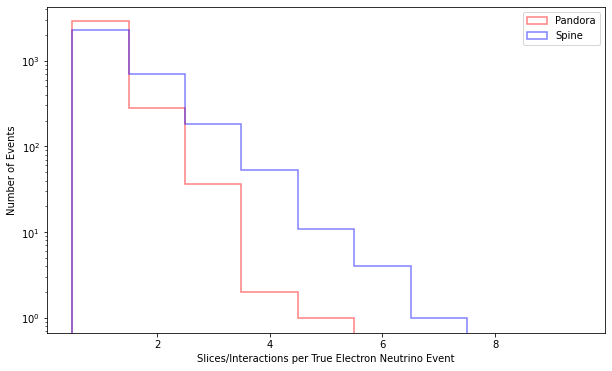

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(counts_p, bins=np.arange(0.5, 10.5, 1), alpha=0.5, label='Pandora', color='red', edgecolor='red', linewidth=1.5, histtype='step')
plt.hist(counts_s, bins=np.arange(0.5, 10.5, 1), alpha=0.5, label='Spine', color='blue', edgecolor='blue', linewidth=1.5, histtype='step')
plt.xlabel('Slices/Interactions per True Electron Neutrino Event')
plt.ylabel('Number of Events')
plt.legend()
plt.yscale('log')
np.sum(counts_p), np.sum(counts_s)

In [47]:
vals_p[0, :]

array([ 0.15070428,  1.        ,  0.        , 20.        ])

[None, None, None, None, None, None, None, None]

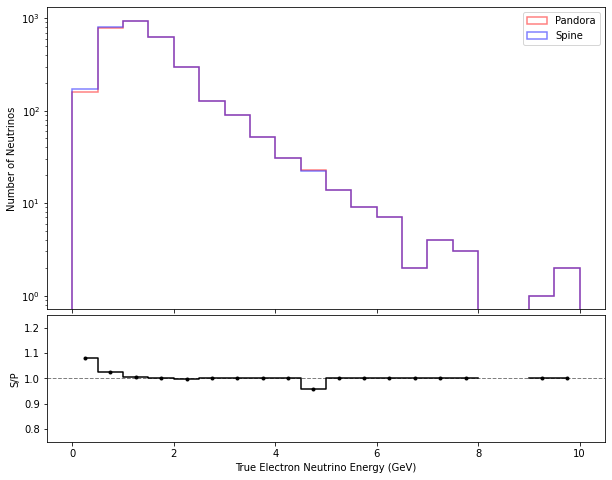

In [60]:
plt.figure(figsize=(10, 8))

xlim = 10

nuE_p = np.where(vals_p[:, 0] > xlim, xlim, vals_p[:, 0])
nuE_s = np.where(vals_s[:, 0] > xlim, xlim, vals_s[:, 0])

plt.hist(nuE_p, bins=20, range=(0,xlim), alpha=0.5, label='Pandora', color='red', edgecolor='red', linewidth=1.5, histtype='step')
plt.hist(nuE_s, bins=20, range=(0,xlim), alpha=0.5, label='Spine', color='blue', edgecolor='blue', linewidth=1.5, histtype='step')
plt.xlabel('True Electron Neutrino Energy (GeV)')
plt.ylabel('Number of Neutrinos')
plt.legend()
plt.yscale('log')

fig = plt.gcf()
ax_top = plt.gca()

# Make space for a ratio panel
pos = ax_top.get_position()
ratio_h = 0.22
gap = 0.01
ax_top.set_position([pos.x0, pos.y0 + ratio_h + gap, pos.width, pos.height - ratio_h - gap])
ax_ratio = fig.add_axes([pos.x0, pos.y0, pos.width, ratio_h], sharex=ax_top)

# Recompute binned counts for ratio (Spine / Pandora)
bin_edges = np.linspace(0, xlim, 21)
h_p, _ = np.histogram(nuE_p, bins=bin_edges)
h_s, _ = np.histogram(nuE_s, bins=bin_edges)

ratio = np.divide(
    h_s, h_p,
    out=np.full(h_s.shape, np.nan, dtype=float),
    where=h_p > 0
)

centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax_ratio.step(centers, ratio, where='mid', color='black', linewidth=1.5)
ax_ratio.plot(centers, ratio, 'o', color='black', markersize=3)

ax_ratio.set_ylabel('S/P')
ax_ratio.set_xlabel('True Electron Neutrino Energy (GeV)')
ax_ratio.set_ylim(0.75, 1.25)

plt.setp(ax_top.get_xticklabels(), visible=False)


In [201]:
def row_view(x):
    return np.ascontiguousarray(x).view(
        np.dtype((np.void, x.dtype.itemsize * x.shape[1]))
    )

shared = np.intersect1d(row_view(vals_p), row_view(vals_s))
n_shared = len(shared)

only_p = np.setdiff1d(row_view(vals_p), row_view(vals_s))
only_s = np.setdiff1d(row_view(vals_s), row_view(vals_p))

print("shared:", len(shared))
print("only P:", len(only_p))
print("only S:", len(only_s))

shared: 3164
only P: 14
only S: 52


In [151]:
c1 = r.TCanvas("c1", "c1", 800, 600)

h_nNue_spine = r.TH1F("h_nNue_spine", "Number of Electron Neutrinos (SPINE)", 5, 0, 5)
h_nNue_pandora = r.TH1F("h_nNue_pandora", "Number of Electron Neutrinos (Pandora)", 5, 0, 5)

h_nNue_spine.FillN(len(f_spineEvt['event_nnu_e'].array()), arr.array('d', f_spineEvt['event_nnu_e'].array()), np.ones(len(f_spineEvt['event_nnu_e'].array())))
h_nNue_pandora.FillN(len(f_pandoraEvt['nNue'].array()), arr.array('d', f_pandoraEvt['nNue'].array()), np.ones(len(f_pandoraEvt['nNue'].array())))

l = r.TLegend(0.6,0.6,0.88,0.88)
h_nNue_spine.GetYaxis().SetRangeUser(0, max(h_nNue_spine.GetMaximum(), h_nNue_pandora.GetMaximum())*1.2)
h_nNue_spine.SetLineColor(r.kBlue)
h_nNue_spine.Draw("HIST")
l.AddEntry(h_nNue_spine, "SPINE", "l")
h_nNue_pandora.SetLineColor(r.kRed)
h_nNue_pandora.Draw("HIST SAME")
l.AddEntry(h_nNue_pandora, "Pandora", "l")
l.Draw()

c1.SetLogy()
c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TROOT::Append>: Replacing existing TH1: h_nNue_spine (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_nNue_pandora (Potential memory leak).
Error in <THistPainter::PaintInit>: Cannot set Y axis to log scale


In [237]:
# spine_selections = []
# spine_selections.append(selection("reco_no_cut", "No Cut"))
# spine_selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
# spine_selections.append(selection("reco_valid_flashmatch", "Flash Cut"))
# spine_selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
# spine_selections.append(selection("reco_track_length", "Longest Track Length < 190 cm"))
# spine_selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
#spine_selections.append(selection("reco_leading_electron_containment_cut", "Leading Electron Containment Cut"))

spine_selections = []
spine_selections.append(selection("reco_no_cut", "No Cut"))
spine_selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
spine_selections.append(selection("reco_flash_cut", "Flash Cut"))
spine_selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
spine_selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
spine_selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
spine_selections.append(selection("reco_muon_multiplicity", "0 Muon-like Particles", operator='==', threshold=0))
spine_selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
spine_selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))

pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))


In [238]:
bins  = arr.array('d', [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000])

In [239]:
hists_spine = get_effHists('true_leading_electron_energy', f_spine, spine_selections,total=nEvt_spine, bins=bins, xmin=0, xmax=5000, nu_eff_var="true_neutrino_energy")

Applying selection: No Cut
total entries in selection: 11306582
Selected entries: 11046192
Purity: 4516/11046192 = 0.0004
290731 290731
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
total entries in selection: 4130763
Selected entries: 4023929
Purity: 4159/4023929 = 0.0010
156245 156245
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Flash Cut
total entries in selection: 123209
Selected entries: 120865
Purity: 3117/120865 = 0.0258
103322 103322
Efficiency after Flash Cut: 0.6902 (3117/4516)
Applying selection: Interaction Containment Cut
total entries in selection: 59861
Selected entries: 57539
Purity: 2983/57539 = 0.0518
55611 55611
Efficiency after Interaction Containment Cut: 0.6605 (2983/4516)
Applying selection: Vertex Distance < 3.25 cm
total entries in selection: 5029
Selected entries: 4802
Purity: 2402/4802 = 0.5002
4635 4635
Efficiency after Vertex Distance < 3.25 cm: 0.5319 (2402/4516)
Applying selection: >=1 Electron-like 

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [242]:
hists_pandora = get_effHists('tShowerE', f_pandora, pandora_selections, total=nEvt_pandora, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', nu_eff_var='tNueEnergy', signal_index=1, scale=1000)

Applying selection: No Cut
total entries in selection: 204728
Selected entries: 204728
Purity: 3542/204728 = 0.0173
204728 204728
Efficiency after No Cut: 1.0000 (3542/3542)
Applying selection: >= 1 Shower
total entries in selection: 39433
Selected entries: 39433
Purity: 2404/39433 = 0.0610
39433 39433
Efficiency after >= 1 Shower: 0.6787 (2404/3542)
Applying selection: Clear Cosmic
total entries in selection: 39433
Selected entries: 39433
Purity: 2404/39433 = 0.0610
39433 39433
Efficiency after Clear Cosmic: 0.6787 (2404/3542)
Applying selection: Fiducial Cut
total entries in selection: 24327
Selected entries: 24327
Purity: 2341/24327 = 0.0962
24327 24327
Efficiency after Fiducial Cut: 0.6609 (2341/3542)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 22432
Selected entries: 22432
Purity: 2195/22432 = 0.0979
22432 22432
Efficiency after Barycenter Delta Z < 100 cm: 0.6197 (2195/3542)
Applying selection: Barycenter Radius < 100 cm
total entries in selection:

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [243]:
print_selection_stats(pandora_selections)


Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (3542/3542) 0.2127 (3177/14938.0) 0.0173 (3542/204728)
>= 1 Shower                           0.6787 (2404/3542) 0.1571 (2347/14938.0) 0.0610 (2404/39433)
Clear Cosmic                          0.6787 (2404/3542) 0.1571 (2347/14938.0) 0.0610 (2404/39433)
Fiducial Cut                          0.6609 (2341/3542) 0.1534 (2291/14938.0) 0.0962 (2341/24327)
Barycenter Delta Z < 100 cm           0.6197 (2195/3542) 0.1443 (2155/14938.0) 0.0979 (2195/22432)
Barycenter Radius < 100 cm            0.6124 (2169/3542) 0.1431 (2138/14938.0) 0.0992 (2169/21867)
Longest Track < 190 cm                0.5584 (1978/3542) 0.1305 (1950/14938.0) 0.1282 (1978/15431)
Shower Contained                      0.5347 (1894/3542) 0.1252 (1870/14938.0) 0.1290 (1894/146

In [241]:
print_selection_stats(spine_selections)


Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (4516/4516) 0.2152 (3215/14938.0) 0.0004 (4516/11046192)
Fiducial Cut                          0.9209 (4159/4516) 0.2137 (3192/14938.0) 0.0010 (4159/4023929)
Flash Cut                             0.6902 (3117/4516) 0.2078 (3104/14938.0) 0.0258 (3117/120865)
Interaction Containment Cut           0.6605 (2983/4516) 0.1989 (2971/14938.0) 0.0518 (2983/57539)
Vertex Distance < 3.25 cm             0.5319 (2402/4516) 0.1608 (2402/14938.0) 0.5002 (2402/4802)
>=1 Electron-like Particle            0.5319 (2402/4516) 0.1608 (2402/14938.0) 0.5002 (2402/4802)
0 Muon-like Particles                 0.5268 (2379/4516) 0.1593 (2379/14938.0) 0.5511 (2379/4317)
Leading Electron Softmax > 0.72       0.4885 (2206/4516) 0.1477 (2206/14938.0) 0.6623 (2206/3

In [147]:
c1 = r.TCanvas("c1", "c1", 800, 600)

print(hists_spine.keys())

h_spine_eff = hists_spine[list(hists_spine)[-1]]
h_pandora_eff = hists_pandora[list(hists_pandora)[-1]]

l1 = r.TLegend(0.5,0.6,0.88,0.7)

h_spine_eff.SetTitle("True Leading Electron Energy Efficiency;True Leading Electron Energy (MeV);Efficiency (%)")
h_spine_eff.GetYaxis().SetRangeUser(0, 1.0)
h_spine_eff.Draw()
h_pandora_eff.SetLineColor(r.kRed)
h_pandora_eff.Draw("same")

e_pandora = pandora_selections[-1].efficiency
p_pandora = pandora_selections[-1].purity

e_spine = spine_selections[-1].efficiency
p_spine = spine_selections[-1].purity

l1.AddEntry(h_spine_eff, f"SPINE Efficiency: {e_spine:.2f}%, Purity: {p_spine:.2f}%", "l")
l1.AddEntry(h_pandora_eff, f"Pandora Efficiency: {e_pandora:.2f}%, Purity: {p_pandora:.2f}%", "l")
l1.Draw()   

c1.Draw()

dict_keys(['No Cut', 'Fiducial Cut', 'Flash Cut', 'Interaction Containment Cut', 'Vertex Distance < 3.25 cm', '>=1 Electron-like Particle', '0 Muon-like Particles', 'Leading Electron Softmax > 0.72', 'Leading Electron Primary Softmax > 0.97'])


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


# Compare pandora w/ and w/o NuGraph

In [64]:
f_nugraph = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_nugraphScore.root:t_eff/t_eff")
f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_trackScore.root:t_eff/t_eff")

f_nugraphEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_nugraphScore.root:t_evt/t_evt")
f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_trackScore.root:t_evt/t_evt")

nEvt_nugraph = ak.sum(f_nugraphEvt['nNue'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_nugraph, nEvt_pandora))
if nEvt_nugraph != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 549.0 electron neutrino events in the SPINE file and 549.0 electron neutrino events in the Pandora file.


In [65]:
pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))

nugraph_selections = []
nugraph_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
nugraph_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
nugraph_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
nugraph_selections.append(selection("rFiducial", "Fiducial Cut"))
nugraph_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
nugraph_selections.append(selection("rShowerContained", "Shower Contained"))
nugraph_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))   
nugraph_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
nugraph_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5)) 

In [66]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)
hists_nugraph = get_effHists('rShowerEnergy', f_nugraph, nugraph_selections, total=nEvt_nugraph, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)

Applying selection: No Cut
total entries in selection: 9121
Selected entries: 9121
Purity: 213/9121 = 0.0234
Efficiency after No Cut: 1.0000 (213/213)
Applying selection: >= 1 Shower
total entries in selection: 1848
Selected entries: 1848
Purity: 140/1848 = 0.0758
Efficiency after >= 1 Shower: 0.6573 (140/213)
Applying selection: Clear Cosmic
total entries in selection: 1848
Selected entries: 1848
Purity: 140/1848 = 0.0758
Efficiency after Clear Cosmic: 0.6573 (140/213)
Applying selection: Fiducial Cut
total entries in selection: 1258
Selected entries: 1258
Purity: 139/1258 = 0.1105
Efficiency after Fiducial Cut: 0.6526 (139/213)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 1176
Selected entries: 1176
Purity: 134/1176 = 0.1139
Efficiency after Barycenter Delta Z < 100 cm: 0.6291 (134/213)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 1151
Selected entries: 1151
Purity: 131/1151 = 0.1138
Efficiency after Barycenter Radius < 100

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [67]:
print("Pandora Selections:")
print_selection_stats(pandora_selections)
print("NuGraph Selections:")
print_selection_stats(nugraph_selections)

Pandora Selections:

Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                  1.0000 (213/213)   0.3880 (213/549.0) 0.0234 (213/9121)
>= 1 Shower                             0.6573 (140/213)   0.2550 (140/549.0) 0.0758 (140/1848)
Clear Cosmic                            0.6573 (140/213)   0.2550 (140/549.0) 0.0758 (140/1848)
Fiducial Cut                            0.6526 (139/213)   0.2532 (139/549.0) 0.1105 (139/1258)
Barycenter Delta Z < 100 cm             0.6291 (134/213)   0.2441 (134/549.0) 0.1139 (134/1176)
Barycenter Radius < 100 cm              0.6150 (131/213)   0.2386 (131/549.0) 0.1138 (131/1151)
Longest Track < 190 cm                  0.5681 (121/213)   0.2204 (121/549.0) 0.1470 (121/823)
Shower Contained                        0.5681 (121/213)   0.2204 (121/549.0) 0.1511 (121/801)
Sho

In [68]:
h_pandoraNu_eff = hists_pandora[list(hists_pandora)[-1]]
h_nuGraph_eff = hists_nugraph[list(hists_nugraph)[-1]]

e_pandoraNu = pandora_selections[-1].efficiency
p_pandoraNu = pandora_selections[-1].purity

e_nu = nugraph_selections[-1].efficiency
p_nu = nugraph_selections[-1].purity

## Use Nue enhanced sample

In [54]:
f_nugraph = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_nugraphScore.root:t_eff/t_eff")
f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_trackScore.root:t_eff/t_eff")

f_nugraphEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_nugraphScore.root:t_evt/t_evt")
f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_trackScore.root:t_evt/t_evt")

nEvt_nugraph = ak.sum(f_nugraphEvt['nNue'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_nugraph, nEvt_pandora))
if nEvt_nugraph != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 19259.0 electron neutrino events in the SPINE file and 19259.0 electron neutrino events in the Pandora file.


In [55]:
pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))

nugraph_selections = []
nugraph_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
nugraph_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
nugraph_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
nugraph_selections.append(selection("rFiducial", "Fiducial Cut"))
nugraph_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
nugraph_selections.append(selection("rShowerContained", "Shower Contained"))
nugraph_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))   
nugraph_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
nugraph_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5)) 

In [56]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=50, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1)
hists_nugraph = get_effHists('rShowerEnergy', f_nugraph, nugraph_selections, total=nEvt_nugraph, bins=50, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1)

Applying selection: No Cut
total entries in selection: 15155
Selected entries: 15155
Purity: 7361/15155 = 0.4857
Efficiency after No Cut: 1.0000 (7361/7361)
Applying selection: >= 1 Shower
total entries in selection: 8291
Selected entries: 8291
Purity: 4918/8291 = 0.5932
Efficiency after >= 1 Shower: 0.6681 (4918/7361)
Applying selection: Clear Cosmic
total entries in selection: 8291
Selected entries: 8291
Purity: 4918/8291 = 0.5932
Efficiency after Clear Cosmic: 0.6681 (4918/7361)
Applying selection: Fiducial Cut
total entries in selection: 5540
Selected entries: 5540
Purity: 4797/5540 = 0.8659
Efficiency after Fiducial Cut: 0.6517 (4797/7361)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 5353
Selected entries: 5353
Purity: 4647/5353 = 0.8681
Efficiency after Barycenter Delta Z < 100 cm: 0.6313 (4647/7361)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 5280
Selected entries: 5280
Purity: 4595/5280 = 0.8703
Efficiency after Bary

Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Wa

In [57]:
print("Pandora Selections:")
print_selection_stats(pandora_selections)
print("NuGraph Selections:")
print_selection_stats(nugraph_selections)

Pandora Selections:

Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (7361/7361) 0.3822 (7361/19259.0) 0.4857 (7361/15155)
>= 1 Shower                           0.6681 (4918/7361) 0.2554 (4918/19259.0) 0.5932 (4918/8291)
Clear Cosmic                          0.6681 (4918/7361) 0.2554 (4918/19259.0) 0.5932 (4918/8291)
Fiducial Cut                          0.6517 (4797/7361) 0.2491 (4797/19259.0) 0.8659 (4797/5540)
Barycenter Delta Z < 100 cm           0.6313 (4647/7361) 0.2413 (4647/19259.0) 0.8681 (4647/5353)
Barycenter Radius < 100 cm            0.6242 (4595/7361) 0.2386 (4595/19259.0) 0.8703 (4595/5280)
Longest Track < 190 cm                0.5768 (4246/7361) 0.2205 (4246/19259.0) 0.8656 (4246/4905)
Shower Contained                      0.5597 (4120/7361) 0.2139 (4120/19259.0) 0.8

# Compare Pandora w/ and w/o CVN

In [58]:
f_cvn = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/CVN/merged_output.root:t_eff/t_eff")
f_pandora = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/noCVN/merged_output.root:t_eff/t_eff")

f_cvnEvt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/CVN/merged_output.root:t_evt/t_evt")
f_pandoraEvt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/noCVN/merged_output.root:t_evt/t_evt")

nEvt_cvn = ak.sum(f_cvnEvt['nNue'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_cvn, nEvt_pandora))
if nEvt_cvn != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 4733.0 electron neutrino events in the SPINE file and 4733.0 electron neutrino events in the Pandora file.


In [59]:
pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))

cvn_selections = []
cvn_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
cvn_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
cvn_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
cvn_selections.append(selection("rFiducial", "Fiducial Cut"))
cvn_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
cvn_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
cvn_selections.append(selection("kCVNNueScore", "CVN NuE Cut > 0.85", operator='>', threshold=0.85))
cvn_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
cvn_selections.append(selection("rShowerContained", "Shower Contained"))
cvn_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))   
cvn_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
cvn_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5)) 

In [60]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)
hists_cvn = get_effHists('rShowerEnergy', f_cvn, cvn_selections, total=nEvt_cvn, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)

Applying selection: No Cut
total entries in selection: 63790
Selected entries: 63790
Purity: 1117/63790 = 0.0175
Efficiency after No Cut: 1.0000 (1117/1117)
Applying selection: >= 1 Shower
total entries in selection: 10560
Selected entries: 10560
Purity: 675/10560 = 0.0639
Efficiency after >= 1 Shower: 0.6043 (675/1117)
Applying selection: Clear Cosmic
total entries in selection: 10560
Selected entries: 10560
Purity: 675/10560 = 0.0639
Efficiency after Clear Cosmic: 0.6043 (675/1117)
Applying selection: Fiducial Cut
total entries in selection: 6782
Selected entries: 6782
Purity: 655/6782 = 0.0966
Efficiency after Fiducial Cut: 0.5864 (655/1117)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 6265
Selected entries: 6265
Purity: 625/6265 = 0.0998
Efficiency after Barycenter Delta Z < 100 cm: 0.5595 (625/1117)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 6126
Selected entries: 6126
Purity: 615/6126 = 0.1004
Efficiency after Barycen

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [61]:
print("Pandora Selections:")
print_selection_stats(pandora_selections)
print("CVN Selections:")
print_selection_stats(cvn_selections)

Pandora Selections:

Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (1117/1117) 0.2360 (1117/4733.0) 0.0175 (1117/63790)
>= 1 Shower                            0.6043 (675/1117)  0.1426 (675/4733.0) 0.0639 (675/10560)
Clear Cosmic                           0.6043 (675/1117)  0.1426 (675/4733.0) 0.0639 (675/10560)
Fiducial Cut                           0.5864 (655/1117)  0.1384 (655/4733.0) 0.0966 (655/6782)
Barycenter Delta Z < 100 cm            0.5595 (625/1117)  0.1321 (625/4733.0) 0.0998 (625/6265)
Barycenter Radius < 100 cm             0.5506 (615/1117)  0.1299 (615/4733.0) 0.1004 (615/6126)
Longest Track < 190 cm                 0.4987 (557/1117)  0.1177 (557/4733.0) 0.1294 (557/4303)
Shower Contained                       0.4781 (534/1117)  0.1128 (534/4733.0) 0.1291 (534/413

In [62]:
h_cvn_eff = hists_cvn[list(hists_cvn)[-1]]
h_pandoraCVN_eff = hists_pandora[list(hists_pandora)[-1]]

e_pandoraCVN = pandora_selections[-1].efficiency
p_pandoraCVN = pandora_selections[-1].purity

e_cvn = cvn_selections[-1].efficiency
p_cvn = cvn_selections[-1].purity

### Plot efficiencies together

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


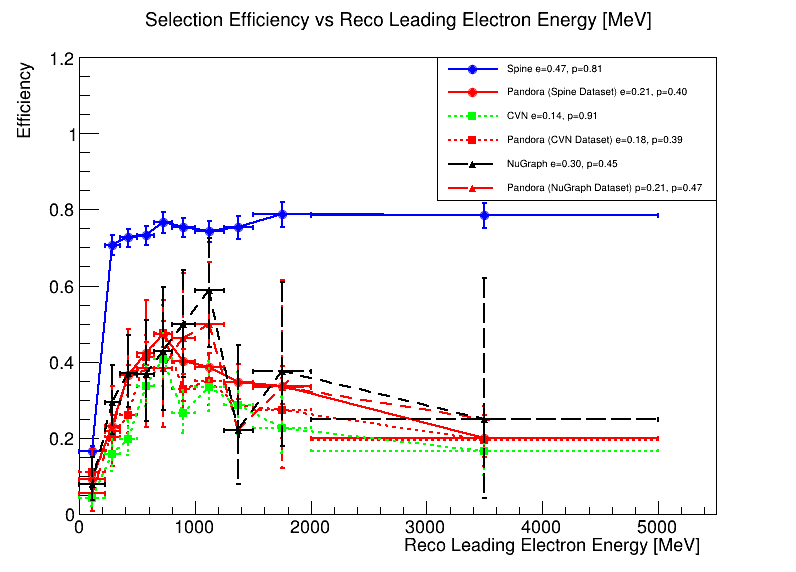

In [77]:
c1 = r.TCanvas("c1", "c1", 800, 600)

h_spine_eff.SetLineColor(r.kBlue)
h_spine_eff.SetLineWidth(2)
h_spine_eff.SetMarkerStyle(20)
h_spine_eff.SetMarkerColor(r.kBlue)

h_cvn_eff.SetLineColor(r.kGreen)
h_cvn_eff.SetLineWidth(2)
h_cvn_eff.SetLineStyle(2)
h_cvn_eff.SetMarkerStyle(21)
h_cvn_eff.SetMarkerColor(r.kGreen)

h_nuGraph_eff.SetLineColor(r.kBlack)
h_nuGraph_eff.SetLineWidth(2)
h_nuGraph_eff.SetLineStyle(9)
h_nuGraph_eff.SetMarkerStyle(22)

h_pandoraCVN_eff.SetLineColor(r.kRed)
h_pandoraCVN_eff.SetLineWidth(2)
h_pandoraCVN_eff.SetLineStyle(2)
h_pandoraCVN_eff.SetMarkerStyle(21)
h_pandoraCVN_eff.SetMarkerColor(r.kRed)

h_pandora_eff.SetLineColor(r.kRed)
h_pandora_eff.SetLineWidth(2)
h_pandora_eff.SetMarkerStyle(20)
h_pandora_eff.SetMarkerColor(r.kRed)

h_pandoraNu_eff.SetLineColor(r.kRed)
h_pandoraNu_eff.SetLineWidth(2)
h_pandoraNu_eff.SetLineStyle(9)
h_pandoraNu_eff.SetMarkerStyle(22)
h_pandoraNu_eff.SetMarkerColor(r.kRed)

h_spine_eff.SetTitle("Selection Efficiency vs Reco Leading Electron Energy [MeV]; Reco Leading Electron Energy [MeV]; Efficiency")
h_spine_eff.GetYaxis().SetRangeUser(0, 1.2)

h_spine_eff.Draw("")
h_pandora_eff.Draw("PL same")
h_pandoraNu_eff.Draw("PL same")
h_pandoraCVN_eff.Draw("PL same")
h_cvn_eff.Draw("PL same")
h_nuGraph_eff.Draw("PL same")
e_pandora = pandora_selections[-1].efficiency

l = r.TLegend(0.55, 0.65, 0.9, 0.9)
l.AddEntry(h_spine_eff, f'Spine e={e_spine:.2f}, p={p_spine:.2f}', 'lp')
l.AddEntry(h_pandora_eff, f'Pandora (Spine Dataset) e={e_pandora:.2f}, p={p_pandora:.2f}', 'lp')
l.AddEntry(h_cvn_eff, f'CVN e={e_cvn:.2f}, p={p_cvn:.2f}', 'lp')
l.AddEntry(h_pandoraCVN_eff, f'Pandora (CVN Dataset) e={e_pandoraCVN:.2f}, p={p_pandoraCVN:.2f}', 'lp')
l.AddEntry(h_nuGraph_eff, f'NuGraph e={e_nu:.2f}, p={p_nu:.2f}', 'lp')
l.AddEntry(h_pandoraNu_eff, f'Pandora (NuGraph Dataset) p={e_pandoraNu:.2f}, p={p_pandoraNu:.2f}', 'lp')

l.Draw()

c1.SetLogy(0)
c1.Draw()

%jsroot off

In [112]:
c1 = r.TCanvas("c1", "c1", 800, 600)
c1.cd()

fin = r.TFile.Open('root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine8/output_merged.root')
tree = fin.Get('events/NuMIFull/selected')

# draw 2D histogram: "y:x>>h(nx,xmin,xmax,ny,ymin,ymax)"
tree.Draw("true_category:true_interaction_mode>>h(10,0,10,10,0,10)", "", "COLZ")

c1.Update()
h = r.gPad.GetPrimitive("h")
h.Draw("colz text")
c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


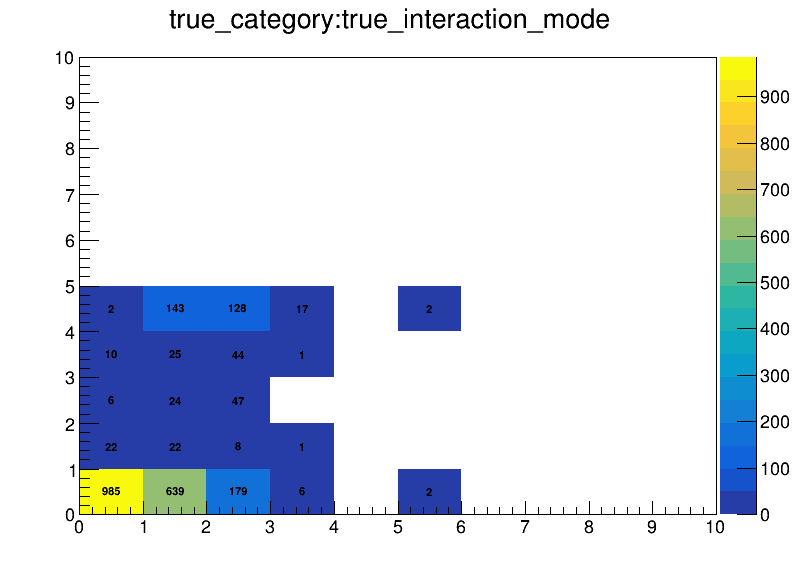

In [111]:
c1.Draw()

In [122]:
fin = uproot.open('root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine8/output_merged.root:events/NuMIFull/selected')

true = fin['true_category'].array()
inter = fin['true_interaction_mode'].array()

out = np.where(true==0, inter, -1)

In [123]:
out[ak.where(out>=0)]

<Array [0, 1, 2, 2, 0, 1, 0, ..., 0, 0, 0, 0, 0, 1, 0] type='2111 * float64'>